In [905]:
import numpy as np
import time
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import skimage
import scipy
from scipy.ndimage import gaussian_filter
from scipy.signal import medfilt
import warnings

# Hide only FutureWarnings
warnings.filterwarnings("ignore", category=FutureWarning)


In [1087]:
               # DISTANCES
feats_list1 =  ['proximity', 'resident2intruder head-head', 'resident2intruder head-tti', 'intruder2resident head-tti',
               # SOCIAL ORIENTATIONS
               'resident2intruder head2centroid angle', 'intruder2resident head2centroid angle',
               # SPEEDS
               'resident centroid roc 100 ms', 'intruder centroid roc 100 ms', 'resident head roc 100 ms', 'intruder head roc 100 ms',
               # POSTURAL INFORMATION
               'resident centroid2nose angle', 'intruder centroid2nose angle', 'resident tti2head', 'intruder tti2head']

               # DISTANCES
feats_list2 =  ['proximity', 'resident2intruder head-head', 'resident2intruder head-tti', 'intruder2resident head-tti',
               # SOCIAL ORIENTATIONS
               'resident2intruder head2centroid angle', 'intruder2resident head2centroid angle',
               # SPEEDS
               'resident centroid roc 100 ms', 'intruder centroid roc 100 ms', 'resident head roc 100 ms', 'intruder head roc 100 ms',
               'resident centroid roc 100 ms sum across lags', 'intruder centroid roc 100 ms sum across lags', 'resident head roc 100 ms sum across lags', 'intruder head roc 100 ms sum across lags',
               # IoU
               'ious',
               # POSTURAL INFORMATION
               'resident centroid2nose angle', 'intruder centroid2nose angle', 'resident tti2head', 'intruder tti2head']

               # DISTANCES
feats_list3 =  ['proximity', 'resident2intruder head-head', 'resident2intruder head-tti', 'intruder2resident head-tti',
               # SOCIAL ORIENTATIONS
               'resident2intruder head2centroid angle', 'intruder2resident head2centroid angle',
               # SPEEDS
               'resident centroid roc 100 ms', 'intruder centroid roc 100 ms', 'resident head roc 100 ms', 'intruder head roc 100 ms',
               'resident centroid roc 100 ms sum across lags', 'intruder centroid roc 100 ms sum across lags', 'resident head roc 100 ms sum across lags', 'intruder head roc 100 ms sum across lags',
               # IoU and pixel change
               'ious',
               # POSTURAL INFORMATION
               'resident centroid2nose angle', 'intruder centroid2nose angle', 'resident tti2head', 'intruder tti2head']

               # DISTANCES
feats_list4 =  ['proximity', 'resident2intruder head-head', 'resident2intruder head-tti', 'intruder2resident head-tti',
               # SOCIAL ORIENTATIONS
               'resident2intruder head2centroid angle', 'intruder2resident head2centroid angle',
               # SPEEDS
               'resident centroid roc 100 ms', 'intruder centroid roc 100 ms', 'resident head roc 100 ms', 'intruder head roc 100 ms', 'proximity roc 100 ms',
               'resident centroid roc 100 ms sum across lags', 'intruder centroid roc 100 ms sum across lags', 'resident head roc 100 ms sum across lags', 'intruder head roc 100 ms sum across lags',
               'proximity roc 100 ms sum across lags',
               # IoU and pixel change
               'ious',
               # POSTURAL INFORMATION
               'resident centroid2nose angle', 'intruder centroid2nose angle', 'resident tti2head', 'intruder tti2head']

               # DISTANCES
feats_list5 =  ['proximity', 'proximity median across lags', 'resident2intruder head-head', 'resident2intruder head-head median across lags', 'resident2intruder head-tti', 'intruder2resident head-tti',
               # SOCIAL ORIENTATIONS
               'resident2intruder head2centroid angle', 'intruder2resident head2centroid angle',
               # SPEEDS
               'resident centroid roc 100 ms', 'intruder centroid roc 100 ms', 'resident head roc 100 ms', 'intruder head roc 100 ms', 'proximity roc 100 ms',
               'resident centroid roc 100 ms sum across lags', 'intruder centroid roc 100 ms sum across lags', 'resident head roc 100 ms sum across lags', 'intruder head roc 100 ms sum across lags',
               'proximity roc 100 ms sum across lags',
               # IoU and pixel change
               'ious',
               # POSTURAL INFORMATION
               'resident centroid2nose angle', 'intruder centroid2nose angle', 'resident tti2head', 'intruder tti2head']


feats_list = list(set(feats_list1 + feats_list2 + feats_list3 + feats_list4 + feats_list5))
feats_list.sort()
feats_list = np.asarray(feats_list)

from tqdm import tqdm

features = {}
implanted_list = ['3095', '3096', '3097', '4013', '4014', '4015', '4016', '29L', '30R2', '30B', '91R2', '30L', '87R2', '87L', '87B', '87L2', '86L', '86L2', '933R', '927R','927L','583L2','583B', '1185', '1162B', '1162L2', '1162R', '4321L', '4321R2', '4321R', '7452R', '7452L', '7452B', '7452R']
feats_path = "S:\\jmig\\feature_processing\\processed_features_020924_parquets\\"
feat_pickles = np.sort([x for x in os.listdir(feats_path) if 'zscored' in x])
feats_path2 = "S:\\jmig\\feature_processing\\processed_features_not4training\\"
feat_pickles2 = np.sort([x for x in os.listdir(feats_path2) if 'zscored' in x])

for session in tqdm(np.sort(feat_pickles)):
    if any(imp in session for imp in implanted_list):
        n = 4
    else:
        n = 3
    z = pd.read_parquet(feats_path + session, columns=feats_list)
    features['_'.join(session.split('_')[:n])] = z
    
for session in tqdm(np.sort(feat_pickles2)):
    if any(imp in session for imp in implanted_list):
        n = 4
    else:
        n = 3
    z = pd.read_parquet(feats_path2 + session, columns=feats_list)
    features['_'.join(session.split('_')[:n])] = z

100%|██████████| 322/322 [03:55<00:00,  1.37it/s]


([], [])

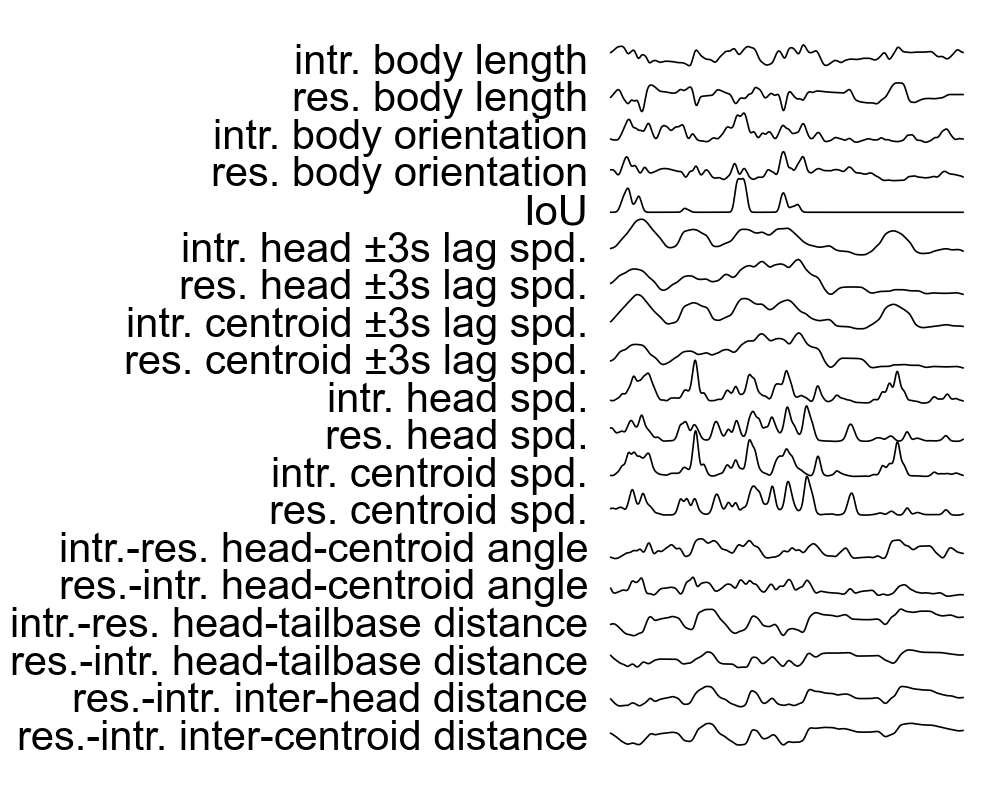

In [ ]:
feat_names = ['res.-intr. inter-centroid distance', 'res.-intr. inter-head distance', 'res.-intr. head-tailbase distance', 'intr.-res. head-tailbase distance', 'res.-intr. head-centroid angle', 
              'intr.-res. head-centroid angle', 'res. centroid spd.', 'intr. centroid spd.', 'res. head spd.', 'intr. head spd.', 'res. centroid ±3s lag spd.', 'intr. centroid ±3s lag spd.', 
              'res. head ±3s lag spd.', 'intr. head ±3s lag spd.', 'IoU', 'res. body orientation', 'intr. body orientation', 'res. body length', 'intr. body length']

plt.figure(figsize=(5, 10))
for i, feat in enumerate(feats_list3):
    feat2plot = features['87R2_d9_toyCD1_t2'][feat].values[7000:9000]
    plt.plot(feat2plot + i*5, color='black', linewidth=1.2)
sns.despine(bottom=True, left=True)
plt.gca().tick_params(axis='y', which='both', length=0)
plt.yticks(np.arange(0, len(feats_list3)*5, 5), feat_names, fontsize=30, fontname='Arial');
plt.xticks([])
# plt.savefig('.\\figures\\paper_figs\\features.svg', dpi=600, bbox_inches='tight')
    

In [ ]:
sourceData_1i = pd.DataFrame({
    feat_names[i]: features['87R2_d9_toyCD1_t2'][feat].values[7000:9000]
    for i, feat in enumerate(feats_list3)
})
sourceData_1i.insert(0, 'frame', np.arange(7000, 9000))

sourceData_1i.to_csv('./sourceData/1i.csv', index=False)

In [903]:
# Helper functions

def map_cluster_data(animals, unsupervised_data_full, clusters, beh='agg'):
	
	trials_across_animals = np.zeros((len(clusters), 27, len(animals)))
	trials_across_animals[:] = np.nan
	occupancies_across_animals = trials_across_animals.copy()
	persistence_across_animals = trials_across_animals.copy()
	
	for a, animal in enumerate(animals):
		
		sessions2map = list(unsupervised_data_full.keys())
		
		if beh == 'agg':
			sessions2map = [x for x in sessions2map if animal in x if '_balbc_' in x or '_mCD1_' in x]
		elif beh == 'obs':
			sessions2map = [x for x in sessions2map if animal in x if '_obs_' in x or '_OBSmCD1_' in x]
		elif beh == 'non':
			sessions2map = [x for x in sessions2map if animal in x if 'toy' in x or 'toyCD1' in x]
		elif beh == 'xpo':
			sessions2map = [x for x in sessions2map if animal in x if 'xpo' in x or 'xpoCD1' in x]
			
		for s, session in enumerate(sessions2map):
			
			sample = unsupervised_data_full[session]
			ntrials, occupancies, persistences = get_unsupervised_trials(sample, clusters)
			trials_across_animals[:, s, a] = ntrials
			occupancies_across_animals[:, s, a] = occupancies
			persistence_across_animals[:, s, a] = persistences

	return trials_across_animals, occupancies_across_animals, persistence_across_animals

def extract_events_of_interest(labels, max_gap):
    """
    filt:     minimum run length (in frames) to count as an event
    max_gap:  bridge gaps of up to this many frames between two runs of 1s,
              treating them as a single continuous event
    """
    labels = np.asarray(labels)

    # ── bridge small gaps first ────────────────────────────────────────────────
    if max_gap > 0:
        labels = labels.copy()
        zero_idx = np.where(labels == 0)[0]
        # find runs of zeros
        if len(zero_idx) > 0:
            gap_breaks = np.where(np.diff(zero_idx) > 1)[0]
            gap_starts = np.concatenate(([zero_idx[0]], zero_idx[gap_breaks + 1]))
            gap_ends   = np.concatenate((zero_idx[gap_breaks], [zero_idx[-1]]))
            for gs, ge in zip(gap_starts, gap_ends):
                gap_len = ge - gs + 1
                # only bridge if flanked by 1s on both sides (not start/end of array)
                if gap_len <= max_gap and gs > 0 and ge < len(labels) - 1:
                    if labels[gs - 1] == 1 and labels[ge + 1] == 1:
                        labels[gs:ge + 1] = 1

    # ── existing contiguous-run extraction ────────────────────────────────────
    events  = []
    indices = []
    start_idx = None

    for i in range(len(labels)):
        if labels[i] == 1:
            if start_idx is None and len(indices):
                start_idx = i
            indices.append(i)
        elif start_idx is not None:
            if len(indices):
                events.append(indices)
            start_idx = None
            indices = []

    if start_idx is not None and len(indices):
        events.append(np.asarray(indices))
    return events

def get_unsupervised_trials(session_binary_labels, clusters):
	
	ntrials = np.zeros((len(clusters)))
	occupancies = ntrials.copy()
	persistences = ntrials.copy()
	
	for i in np.arange(len(clusters)):    

		y = session_binary_labels[:, i]
		y = y[~np.isnan(y)]

		events = extract_events_of_interest(y, max_gap = 40)
		ntrials[i] = len(events)
		if len(events) == 0:
			persistences[i] = 0
		else:
	  	 	persistences[i] = np.nanmedian([len(x)/40 for x in events])
			
		try:
			stacked_events = np.hstack(events)
			occupancies[i] =len(stacked_events)/len(y)
		except ValueError:
			occupancies[i] = 0
			
	return ntrials, occupancies, persistences

def get_sig(p):
    if p is None or np.isnan(p): return ''
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'

    return 'ns'

In [904]:
# Load data

agg_animals = ['3095', '3096', '3097', '4013', '4014', '4015', '4016', '91R2', '30L', '30B']
obs_animals = ['30R2', '29L', '86L', '87L2', '927R', '927L', '933R', '1162B', '1185']
non_animals = ['87R2', '87L', '87B', '86L2', '583L2', '583B', '1162L2', '1162R']
xpo_animals = ['4321L', '4321R2', '4321L2', '7452R', '7452L2']
full_data = pd.read_pickle('multifiber.pickle')
clusters = np.unique(full_data['91R2_d1_balbc_t1']['unsupervised labels'])
n_clusters = len(clusters)

# Make binary labels out of cluster time series

unsupervised_data_full = {}

for key in full_data.keys():
    sample = full_data[key]['unsupervised labels']
    unsupervised_binary_labels = np.zeros((len(sample), len(clusters)))
    for i, label in enumerate(sample):
        unsupervised_binary_labels[i, int(label)-1] = 1
    unsupervised_data_full[key] = unsupervised_binary_labels

# extract trial info

agg_cluster_trials, agg_cluster_occupancies, agg_cluster_persistence = map_cluster_data(agg_animals, unsupervised_data_full, clusters, beh='agg')
obs_cluster_trials, obs_cluster_occupancies, obs_cluster_persistence = map_cluster_data(obs_animals, unsupervised_data_full, clusters, beh='obs')
non_cluster_trials, non_cluster_occupancies, non_cluster_persistence = map_cluster_data(non_animals, unsupervised_data_full, clusters, beh='non')
xpo_cluster_trials, xpo_cluster_occupancies, xpo_cluster_persistence = map_cluster_data(xpo_animals, unsupervised_data_full, clusters, beh='xpo')

Occupancy (i.e. fraction of time spent in behaviors relative to entire session length)

In [1392]:
# Omnibus test + posthoc test framework

from scipy.stats import brunnermunzel

sns.set_context(rc={'lines.linewidth': 2.5,
                    'axes.labelsize': 25,
                    'axes.titlesize': 19.200000000000003,
                    'font.size': 25,
                    'xtick.major.width': 8,
                    'ytick.major.width': 8,
                    'xtick.major.size':6,
                    'ytick.major.size':6,
                    'axes.linewidth':4})

def format_p(p):
    return f'{p:.3e}' if p < 1e-4 else f'{p:.4f}'

def run_comprehensive_stats(data2plot, alpha=0.05, variance_alpha=0.05, verbose=True):
    """
    Comprehensive statistical analysis with variance testing and method selection.
    FDR correction is applied externally at the family level
    """
    exp_roi_activity = data2plot[0][~np.isnan(data2plot[0])]
    obs_roi_activity = data2plot[1][~np.isnan(data2plot[1])]
    non_roi_activity = data2plot[2][~np.isnan(data2plot[2])]

    if len(exp_roi_activity) < 3 or len(obs_roi_activity) < 3 or len(non_roi_activity) < 3:
        if verbose: print("Insufficient data for statistical analysis")
        return None

    df = pd.DataFrame({
        'Activity': np.concatenate([exp_roi_activity, obs_roi_activity, non_roi_activity]),
        'Group': np.concatenate([['exp'] * len(exp_roi_activity),
                                ['obs'] * len(obs_roi_activity),
                                ['non'] * len(non_roi_activity)]),
    })

    _, p_exp_norm = stats.shapiro(exp_roi_activity)
    _, p_obs_norm = stats.shapiro(obs_roi_activity)
    _, p_non_norm = stats.shapiro(non_roi_activity)
    normality_passed = all(p > alpha for p in [p_exp_norm, p_obs_norm, p_non_norm])

    if verbose:
        print(f"Normality tests - EXP: p={format_p(p_exp_norm)}, OBS: p={format_p(p_obs_norm)}, NON: p={format_p(p_non_norm)}")

    levene_stat, levene_p = stats.levene(exp_roi_activity, obs_roi_activity, non_roi_activity)
    equal_variances = levene_p > variance_alpha
    if verbose:
        print(f"Levene's test for equal variances: F={levene_stat:.4f}, p={format_p(levene_p)}")

    if normality_passed:
        bartlett_stat, bartlett_p = stats.bartlett(exp_roi_activity, obs_roi_activity, non_roi_activity)
        if verbose:
            print(f"Bartlett's test for equal variances: χ²={bartlett_stat:.4f}, p={format_p(bartlett_p)}")
        equal_variances = equal_variances and (bartlett_p > variance_alpha)

    results = {
        'normality_passed': normality_passed,
        'equal_variances': equal_variances,
        'levene_p': levene_p
    }

    if normality_passed and equal_variances:
        if verbose: print("Using parametric tests (normality and equal variances assumed)")

        model = sm.OLS.from_formula('Activity ~ C(Group)', data=df).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        f_stat = anova_table['F'][0]
        anova_p = anova_table['PR(>F)'][0]
        if verbose: print(f"One-way ANOVA: F = {f_stat:.4f}, p = {format_p(anova_p)}")

        results.update({'omnibus_test': 'ANOVA', 'omnibus_statistic': f_stat, 'omnibus_p': anova_p})

        if anova_p <= 0.05:
            t1, p_exp_non = stats.ttest_ind(exp_roi_activity, non_roi_activity, equal_var=True)
            t2, p_obs_non = stats.ttest_ind(obs_roi_activity, non_roi_activity, equal_var=True)
            t3, p_exp_obs = stats.ttest_ind(exp_roi_activity, obs_roi_activity, equal_var=True)

            if verbose:
                print(f'EXP vs NON: t = {t1:.4f}, p_raw = {format_p(p_exp_non)}')
                print(f'EXP vs OBS: t = {t3:.4f}, p_raw = {format_p(p_exp_obs)}')
                print(f'OBS vs NON: t = {t2:.4f}, p_raw = {format_p(p_obs_non)}')

            results.update({
                'pairwise_test': 't-test',
                'agg_vs_non': {'statistic': t1, 'p_raw': p_exp_non},
                'agg_vs_obs': {'statistic': t3, 'p_raw': p_exp_obs},
                'obs_vs_non': {'statistic': t2, 'p_raw': p_obs_non}
            })

    elif normality_passed and not equal_variances:
        if verbose: print("Using Welch's tests (normality assumed, unequal variances)")
        try:
            welch_stat, welch_p = stats.f_oneway(exp_roi_activity, obs_roi_activity, non_roi_activity)
            if verbose: print(f"Welch's ANOVA: F = {welch_stat:.4f}, p = {format_p(welch_p)}")

            results.update({'omnibus_test': 'Welch ANOVA', 'omnibus_statistic': welch_stat, 'omnibus_p': welch_p})

            if welch_p <= 0.05:
                t1, p_exp_non = stats.ttest_ind(exp_roi_activity, non_roi_activity, equal_var=False)
                t2, p_obs_non = stats.ttest_ind(obs_roi_activity, non_roi_activity, equal_var=False)
                t3, p_exp_obs = stats.ttest_ind(exp_roi_activity, obs_roi_activity, equal_var=False)

                if verbose:
                    print(f'EXP vs NON: t = {t1:.4f}, p_raw = {format_p(p_exp_non)}')
                    print(f'EXP vs OBS: t = {t3:.4f}, p_raw = {format_p(p_exp_obs)}')
                    print(f'OBS vs NON: t = {t2:.4f}, p_raw = {format_p(p_obs_non)}')

                results.update({
                    'pairwise_test': 'Welch t-test',
                    'agg_vs_non': {'statistic': t1, 'p_raw': p_exp_non},
                    'agg_vs_obs': {'statistic': t3, 'p_raw': p_exp_obs},
                    'obs_vs_non': {'statistic': t2, 'p_raw': p_obs_non}
                })
        except Exception:
            if verbose: print("Welch's ANOVA failed, falling back to non-parametric tests")
            normality_passed = False

    if not normality_passed and equal_variances:
        if verbose: print("Using non-parametric tests (normality not assumed)")

        kruskal_stat, kruskal_p = stats.kruskal(exp_roi_activity, obs_roi_activity, non_roi_activity)
        if verbose: print(f"Kruskal-Wallis H-test: H = {kruskal_stat:.4f}, p = {format_p(kruskal_p)}")

        results.update({'omnibus_test': 'Kruskal-Wallis', 'omnibus_statistic': kruskal_stat, 'omnibus_p': kruskal_p})

        if kruskal_p <= 0.05:
            u1, p_exp_non = brunnermunzel(exp_roi_activity, non_roi_activity, alternative='two-sided')
            u2, p_obs_non = brunnermunzel(obs_roi_activity, non_roi_activity, alternative='two-sided')
            u3, p_exp_obs = brunnermunzel(exp_roi_activity, obs_roi_activity, alternative='two-sided')

            if verbose:
                print(f'EXP vs NON: BM = {u1:.4f}, p_raw = {format_p(p_exp_non)}')
                print(f'EXP vs OBS: BM = {u3:.4f}, p_raw = {format_p(p_exp_obs)}')
                print(f'OBS vs NON: BM = {u2:.4f}, p_raw = {format_p(p_obs_non)}')

            results.update({
                'pairwise_test': 'Brunner-Munzel',
                'agg_vs_non': {'statistic': u1, 'p_raw': p_exp_non},
                'agg_vs_obs': {'statistic': u3, 'p_raw': p_exp_obs},
                'obs_vs_non': {'statistic': u2, 'p_raw': p_obs_non}
            })

    if verbose: print('###')
    return results

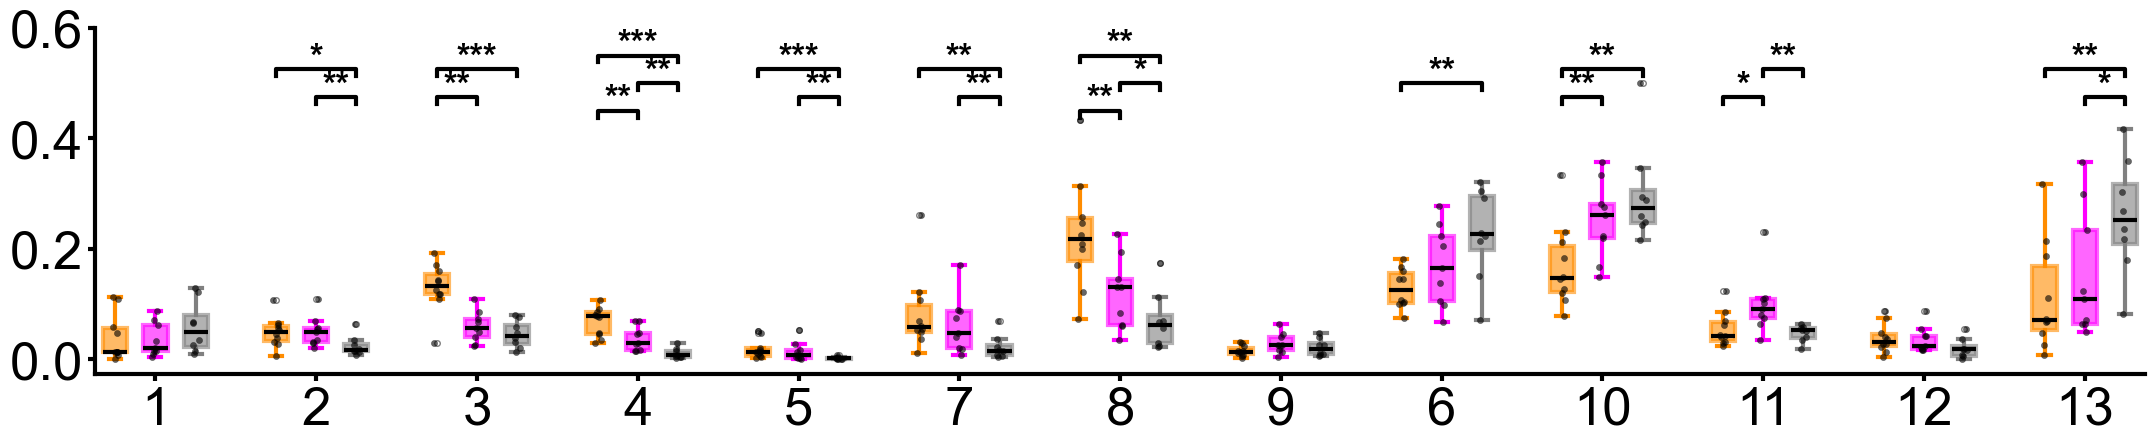

In [1393]:
# Occupancy stats + plotting — omnibus + posthoc + family-wise FDR correction

from scipy import stats
from statsmodels.stats.multitest import multipletests

def add_significance_brackets(ax, positions, data_to_plot, results, y_offset_factor=0.1, center_height=0.5):
    if results is None or 'agg_vs_non' not in results:
        return
    def get_significance_symbol(p_val):
        if p_val <= 0.001: return '***'
        elif p_val <= 0.01: return '**'
        elif p_val <= 0.05: return '*'
        else: return 'ns'

    comparisons = [(0, 2, 'agg_vs_non'), (0, 1, 'agg_vs_obs'), (1, 2, 'obs_vs_non')]
    significant_comparisons = []
    for group1_idx, group2_idx, result_key in comparisons:
        if result_key in results:
            p_val = results[result_key]['p_corrected']
            sig_symbol = get_significance_symbol(p_val)
            if sig_symbol != 'ns':
                significant_comparisons.append((group1_idx, group2_idx, result_key, sig_symbol))
    if not significant_comparisons:
        return

    n_sig = len(significant_comparisons)
    if n_sig == 1:
        bracket_heights = [center_height]
    elif n_sig == 2:
        bracket_heights = [center_height - center_height*0.05, center_height + center_height*0.05]
    else:
        bracket_heights = [center_height - center_height*0.1, center_height, center_height + center_height*0.1]
    bracket_heights = np.array(bracket_heights)

    significant_comparisons.sort(key=lambda x: abs(positions[x[1]] - positions[x[0]]))
    for i, (group1_idx, group2_idx, result_key, sig_symbol) in enumerate(significant_comparisons):
        x1, x2 = positions[group1_idx], positions[group2_idx]
        bracket_height = bracket_heights[i]
        axes_linewidth = ax.spines['bottom'].get_linewidth() - 1
        bracket_linewidth = max(axes_linewidth, 1.5)
        bracket_drop = center_height * 0.025
        ax.plot([x1, x1, x2, x2],
               [bracket_height - bracket_drop, bracket_height, bracket_height, bracket_height - bracket_drop],
               'k-', linewidth=bracket_linewidth)
        ax.text((x1 + x2) / 2, bracket_height - 0.01, sig_symbol,
               ha='center', va='bottom', fontsize=25, fontweight='bold', fontfamily='Arial')

# ── a priori behavioral families (1-indexed cluster labels) ──────────────────
family_labels_1idx = {
    'social':    [1, 2, 3, 4, 5, 7, 8, 9],
    'asocial':   [6, 10, 11, 12, 13],
}

family_idx = {fam: [lbl - 1 for lbl in labels]
              for fam, labels in family_labels_1idx.items()}
cluster_to_family = {idx: fam for fam, idxs in family_idx.items() for idx in idxs}

comparisons_list = ['agg_vs_obs', 'agg_vs_non', 'obs_vs_non']

plt.close()
mean_func = np.nanmean

# ── sessions collapsed per animal first (one value per animal) ────────────────
cd1_agg_occupancies = mean_func(agg_cluster_occupancies[:, -3:, :], axis=1)  # (13, n_agg)
cd1_obs_occupancies = mean_func(obs_cluster_occupancies[:, -3:, :], axis=1)  # (13, n_obs)
cd1_non_occupancies = mean_func(non_cluster_occupancies[:, -3:, :], axis=1)  # (13, n_non)

cluster_order = [0, 1, 2, 3, 4, 6, 7, 8, 5, 9, 10, 11, 12]

fig, axs = plt.subplots(figsize=(1.7 * n_clusters, 5))

# ── Step 1: omnibus + raw pairwise p-values per cluster (no family correction yet) ──
cluster_data_cache = {}
raw_p_all   = {}
omnibus_all = {}

for cluster_idx in cluster_order:
    agg_d = cd1_agg_occupancies[cluster_idx][~np.isnan(cd1_agg_occupancies[cluster_idx])]
    obs_d = cd1_obs_occupancies[cluster_idx][~np.isnan(cd1_obs_occupancies[cluster_idx])]
    non_d = cd1_non_occupancies[cluster_idx][~np.isnan(cd1_non_occupancies[cluster_idx])]
    cluster_data_cache[cluster_idx] = (agg_d, obs_d, non_d)

    stat_result = run_comprehensive_stats([agg_d, obs_d, non_d], verbose=False)

    omnibus_all[cluster_idx] = {
        'omnibus_test': stat_result['omnibus_test'] if stat_result else 'n/a',
        'omnibus_p':    stat_result['omnibus_p']    if stat_result else np.nan,
    }

    raw_p_all[cluster_idx] = {}
    for comp in comparisons_list:
        if stat_result is not None and comp in stat_result:
            raw_p_all[cluster_idx][comp] = stat_result[comp]['p_raw']
        else:
            raw_p_all[cluster_idx][comp] = np.nan

# ── Step 2: FDR within each behavioral family (all clusters × comparisons in family) ──
cluster_stats_fixed = {c: {} for c in cluster_order}

for fam, idxs in family_idx.items():
    keys, pvals = [], []
    for cluster_idx in idxs:
        for comp in comparisons_list:
            keys.append((cluster_idx, comp))
            pvals.append(raw_p_all[cluster_idx][comp])

    valid = [i for i, p in enumerate(pvals) if not np.isnan(p)]
    corr_full = np.full(len(pvals), np.nan)
    if valid:
        _, corr, _, _ = multipletests([pvals[i] for i in valid], method='fdr_tsbh')
        for rank, i in enumerate(valid):
            corr_full[i] = corr[rank]

    for (cluster_idx, comp), p_raw, p_corr in zip(keys, pvals, corr_full):
        cluster_stats_fixed[cluster_idx][comp] = {
            'p_raw': p_raw, 'p_corrected': p_corr, 'family': fam,
        }

for cluster_idx in cluster_order:
    fam    = cluster_to_family[cluster_idx]
    omni_t = omnibus_all[cluster_idx]['omnibus_test']
    omni_p = omnibus_all[cluster_idx]['omnibus_p']
    omni_p_str = format_p(omni_p) if not np.isnan(omni_p) else 'n/a'

    for comp in comparisons_list:
        p_raw  = cluster_stats_fixed[cluster_idx][comp]['p_raw']
        p_corr = cluster_stats_fixed[cluster_idx][comp]['p_corrected']
        p_raw_str  = format_p(p_raw)  if not np.isnan(p_raw)  else 'n/a'
        p_corr_str = format_p(p_corr) if not np.isnan(p_corr) else 'n/a'

# ── Plot ───────────────────────────────────────────────────────────────────────
for plot_idx, cluster_idx in enumerate(cluster_order):

    agg_d, obs_d, non_d = cluster_data_cache[cluster_idx]
    stats_fixed = cluster_stats_fixed[cluster_idx]

    data_to_plot = [agg_d, obs_d, non_d]
    positions = np.arange(1, 4) + (plot_idx * 4)
    colors = ['darkorange', 'magenta', 'gray']

    box = plt.boxplot(data_to_plot, positions=positions, patch_artist=True, widths=0.6,
                      medianprops=dict(color='black', linewidth=3),
                      whiskerprops=dict(linewidth=3), capprops=dict(linewidth=3),
                      flierprops=dict(marker='o', markersize=4, markeredgecolor='black', alpha=0.5))
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color); patch.set_edgecolor(color)
        patch.set_alpha(0.6); patch.set_linewidth(3)
    for whisker, color in zip(box['whiskers'], [c for c in colors for _ in (0, 1)]):
        whisker.set_color(color)
    for cap, color in zip(box['caps'], [c for c in colors for _ in (0, 1)]):
        cap.set_color(color)

    for j, (data, color) in enumerate(zip(data_to_plot, colors)):
        jitter = np.random.default_rng(42 + j).uniform(-0.08, 0.08, size=len(data))
        plt.scatter(np.full(len(data), positions[j]) + jitter, data,
                    color='black', s=20, alpha=0.6, zorder=5, linewidths=0.3)

    add_significance_brackets(plt.gca(), positions, data_to_plot, stats_fixed, y_offset_factor=0.15)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(3)
ax.tick_params(axis='both', length=5, width=3)
sns.despine()
plt.yticks(fontsize=38, fontfamily='Arial')
plt.ylim(top=0.6)
for tick in ax.get_yticklabels():
    tick.set_fontfamily('Arial'); tick.set_fontsize(38)
x_tick_labels = [cluster_order[i] + 1 for i in np.arange(len(cluster_order))]
plt.xticks(np.linspace(2, 50, 13), x_tick_labels, fontsize=38, fontfamily='Arial')
for tick in ax.get_xticklabels():
    tick.set_fontfamily('Arial')
plt.tight_layout()
# plt.savefig('.\\figures\\fig1\\cd1_occupancies_boxplots_with_stats.svg', dpi=600, bbox_inches='tight')
plt.show()

In [1394]:
# ── Full stats table with omnibus + posthoc details ───────────────────────────

def compute_df_for_test(pairwise_test, a, b):
    """Return degrees of freedom where meaningful; NaN otherwise."""
    if pairwise_test == 't-test':
        return len(a) + len(b) - 2
    elif pairwise_test == 'Welch t-test':
        v1, v2 = np.var(a, ddof=1), np.var(b, ddof=1)
        n1, n2 = len(a), len(b)
        return (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
    else:
        # Brunner-Munzel / Mann-Whitney U — no conventional df
        return np.nan

# ── Step 1: also cache full stat_result + per-pair statistic/test ──
cluster_data_cache  = {}
raw_p_all           = {}
omnibus_all         = {}
posthoc_detail_all  = {}  

for cluster_idx in cluster_order:

    agg_d = cd1_agg_occupancies[cluster_idx][~np.isnan(cd1_agg_occupancies[cluster_idx])]
    obs_d = cd1_obs_occupancies[cluster_idx][~np.isnan(cd1_obs_occupancies[cluster_idx])]
    non_d = cd1_non_occupancies[cluster_idx][~np.isnan(cd1_non_occupancies[cluster_idx])]
    cluster_data_cache[cluster_idx] = (agg_d, obs_d, non_d)

    stat_result = run_comprehensive_stats([agg_d, obs_d, non_d], verbose=False)

    omnibus_all[cluster_idx] = {
        'omnibus_test':      stat_result['omnibus_test']      if stat_result else 'n/a',
        'omnibus_statistic': stat_result['omnibus_statistic'] if stat_result else np.nan,
        'omnibus_p':         stat_result['omnibus_p']         if stat_result else np.nan,
    }

    raw_p_all[cluster_idx]          = {}
    posthoc_detail_all[cluster_idx] = {}

    pair_data_lookup = {
        'agg_vs_obs': (agg_d, obs_d),
        'agg_vs_non': (agg_d, non_d),
        'obs_vs_non': (obs_d, non_d),
    }

    for comp in comparisons_list:
        if stat_result is not None and comp in stat_result:
            raw_p_all[cluster_idx][comp] = stat_result[comp]['p_raw']
            pairwise_test = stat_result.get('pairwise_test', 'n/a')
            a, b = pair_data_lookup[comp]
            posthoc_detail_all[cluster_idx][comp] = {
                'test':      pairwise_test,
                'statistic': stat_result[comp]['statistic'],
                'df':        compute_df_for_test(pairwise_test, a, b),
            }
        else:
            raw_p_all[cluster_idx][comp] = np.nan
            posthoc_detail_all[cluster_idx][comp] = {
                'test': 'n/a (omnibus n.s.)', 'statistic': np.nan, 'df': np.nan,
            }

# ── Step 2: FDR within each behavioral family (unchanged) ────────────────────
cluster_stats_fixed = {c: {} for c in cluster_order}

for fam, idxs in family_idx.items():
    keys, pvals = [], []
    for cluster_idx in idxs:
        for comp in comparisons_list:
            keys.append((cluster_idx, comp))
            pvals.append(raw_p_all[cluster_idx][comp])

    valid = [i for i, p in enumerate(pvals) if not np.isnan(p)]
    corr_full = np.full(len(pvals), np.nan)
    if valid:
        _, corr, _, _ = multipletests([pvals[i] for i in valid], method='fdr_tsbh')
        for rank, i in enumerate(valid):
            corr_full[i] = corr[rank]

    for (cluster_idx, comp), p_raw, p_corr in zip(keys, pvals, corr_full):
        cluster_stats_fixed[cluster_idx][comp] = {
            'p_raw': p_raw, 'p_corrected': p_corr, 'family': fam,
        }

# ── Full stats table ───────────────────────────────────────────────────────────
comp_display = {
    'agg_vs_obs': 'EXP vs OBS',
    'agg_vs_non': 'EXP vs NON',
    'obs_vs_non': 'OBS vs NON',
}

print(f'\n{"="*160}')
print(f'Behavioral cluster statistics — omnibus (KW/ANOVA/Welch ANOVA) → posthoc '
      f'(t-test/Welch t-test/Brunner-Munzel)')
print(f'FDR-BH applied WITHIN each behavioral family (social n={len(family_idx["social"])*3}, '
      f'asocial n={len(family_idx["asocial"])*3})')
print(f'{"="*160}')
print(f'{"Behavior":<10} {"Family":<10} '
      f'{"Omnibus":<14} {"Omni_stat":>10} {"Omni_p":>10} '
      f'{"Comparison":<12} {"Posthoc":<16} {"PH_stat":>10} {"df":>8} '
      f'{"p_fdr":>10}')
print(f'{"─"*160}')

for cluster_idx in cluster_order:
    fam        = cluster_to_family[cluster_idx]
    omni_t     = omnibus_all[cluster_idx]['omnibus_test']
    omni_stat  = omnibus_all[cluster_idx]['omnibus_statistic']
    omni_p     = omnibus_all[cluster_idx]['omnibus_p']
    omni_stat_str = format_p(omni_stat) if False else (f'{omni_stat:.4f}' if not np.isnan(omni_stat) else 'n/a')
    omni_p_str    = format_p(omni_p)    if not np.isnan(omni_p)    else 'n/a'

    for comp in comparisons_list:
        detail  = posthoc_detail_all[cluster_idx][comp]
        p_raw   = cluster_stats_fixed[cluster_idx][comp]['p_raw']
        p_corr  = cluster_stats_fixed[cluster_idx][comp]['p_corrected']

        ph_test = detail['test']
        ph_stat = detail['statistic']
        ph_df   = detail['df']

        ph_stat_str = f'{ph_stat:.4f}' if not np.isnan(ph_stat) else 'n/a'
        ph_df_str   = f'{ph_df:.1f}'   if not np.isnan(ph_df)   else 'n/a'
        p_raw_str   = format_p(p_raw)  if not np.isnan(p_raw)  else 'n/a'
        p_corr_str  = format_p(p_corr) if not np.isnan(p_corr) else 'n/a'

        print(f'{cluster_idx+1:<10} {fam:<10} '
              f'{omni_t:<14} {omni_stat_str:>10} {omni_p_str:>10} '
              f'{comp_display[comp]:<12} {ph_test:<16} {ph_stat_str:>10} {ph_df_str:>8} '
              f'{p_corr_str:>10}')

    print(f'{"─"*160}')

print(f'{"="*160}')


Behavioral cluster statistics — omnibus (KW/ANOVA/Welch ANOVA) → posthoc (t-test/Welch t-test/Brunner-Munzel)
FDR-BH applied WITHIN each behavioral family (social n=24, asocial n=15)
Behavior   Family     Omnibus         Omni_stat     Omni_p Comparison   Posthoc             PH_stat       df      p_fdr
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
1          social     Kruskal-Wallis     2.2588     0.3232 EXP vs OBS   n/a (omnibus n.s.)        n/a      n/a        n/a
1          social     Kruskal-Wallis     2.2588     0.3232 EXP vs NON   n/a (omnibus n.s.)        n/a      n/a        n/a
1          social     Kruskal-Wallis     2.2588     0.3232 OBS vs NON   n/a (omnibus n.s.)        n/a      n/a        n/a
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
2       

In [1395]:
# ── Source data export: 1n ─────────────
os.makedirs('./sourceData', exist_ok=True)

comp_display = {
    'agg_vs_obs': 'EXP_vs_OBS',
    'agg_vs_non': 'EXP_vs_NON',
    'obs_vs_non': 'OBS_vs_NON',
}

group_arrays = {'EXP': 0, 'OBS': 1, 'NON': 2}  # index into cluster_data_cache tuple

rows = []

for cluster_idx in cluster_order:
    cluster_label = cluster_idx + 1  # matches x-tick numbering in the figure
    fam = cluster_to_family[cluster_idx]
    agg_d, obs_d, non_d = cluster_data_cache[cluster_idx]

    omni_test = omnibus_all[cluster_idx]['omnibus_test']
    omni_stat = omnibus_all[cluster_idx]['omnibus_statistic']
    omni_p    = omnibus_all[cluster_idx]['omnibus_p']

    group_data = {'EXP': agg_d, 'OBS': obs_d, 'NON': non_d}

    for group, vals in group_data.items():
        for v in vals:
            row = {
                'cluster': cluster_label,
                'family': fam,
                'group': group,
                'occupancy': v,
                'omnibus_test': omni_test,
                'omnibus_stat': omni_stat,
                'omnibus_p': omni_p,
            }
            for comp in comparisons_list:
                detail = posthoc_detail_all[cluster_idx][comp]
                p_fdr  = cluster_stats_fixed[cluster_idx][comp]['p_corrected']
                label  = comp_display[comp]
                row[f'{label}_test']  = detail['test']
                row[f'{label}_stat']  = detail['statistic']
                row[f'{label}_df']    = detail['df']
                row[f'{label}_p_fdr'] = p_fdr
            rows.append(row)

sourceData_1n = pd.DataFrame(rows)
sourceData_1n.to_csv('./sourceData/1n.csv', index=False)

Persistence (i.e. length of each behavior segment)

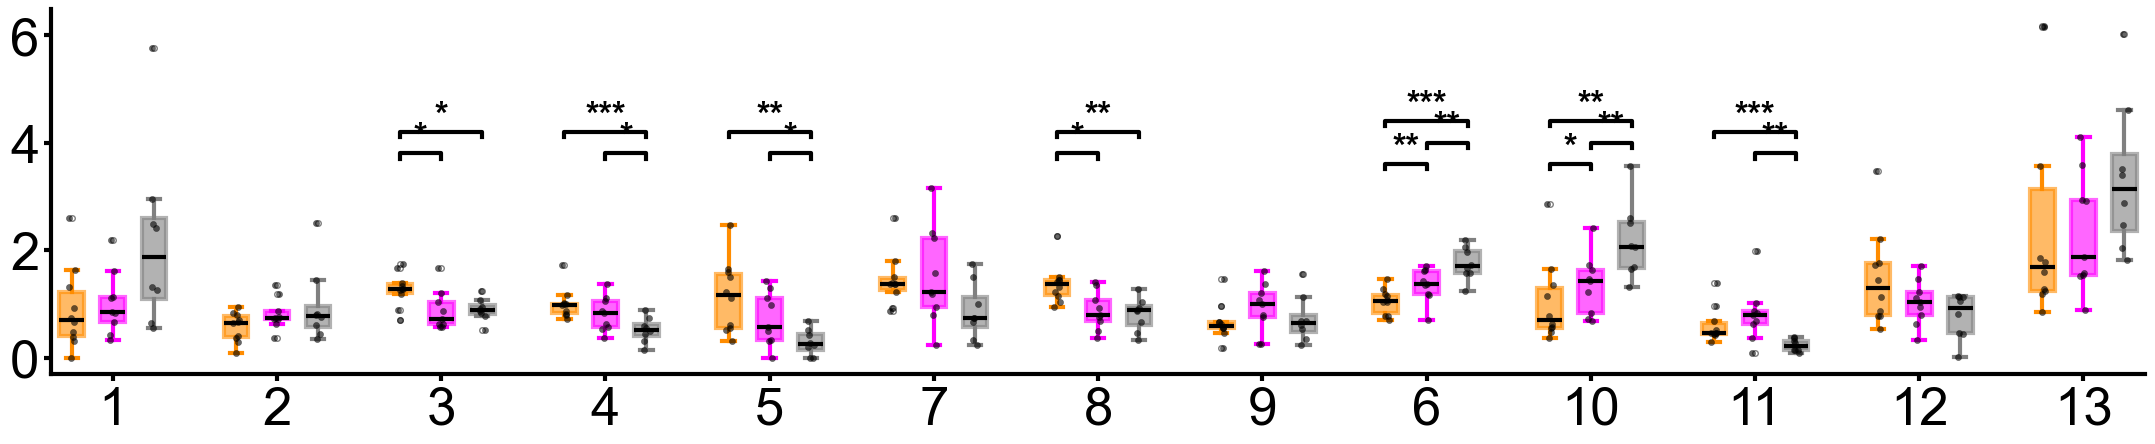

In [1147]:
# Persistence stats + plotting — omnibus + posthoc + family-wise FDR correction

from scipy import stats
from statsmodels.stats.multitest import multipletests
plt.close()
mean_func = np.nanmean

# ── sessions collapsed per animal first (one value per animal) ────────────────
cd1_agg_persistence = mean_func(agg_cluster_persistence[:, -3:, :], axis=1)  # (13, n_agg)
cd1_obs_persistence = mean_func(obs_cluster_persistence[:, -3:, :], axis=1)  # (13, n_obs)
cd1_non_persistence = mean_func(non_cluster_persistence[:, -3:, :], axis=1)  # (13, n_non)

cluster_order = [0, 1, 2, 3, 4, 6, 7, 8, 5, 9, 10, 11, 12]

fig, axs = plt.subplots(figsize=(1.7 * n_clusters, 5))

# ── Step 1: omnibus + raw pairwise p-values per cluster (no family correction yet) ──
cluster_data_cache = {}
raw_p_all   = {}
omnibus_all = {}

for cluster_idx in cluster_order:
    agg_d = cd1_agg_persistence[cluster_idx][~np.isnan(cd1_agg_persistence[cluster_idx])]
    obs_d = cd1_obs_persistence[cluster_idx][~np.isnan(cd1_obs_persistence[cluster_idx])]
    non_d = cd1_non_persistence[cluster_idx][~np.isnan(cd1_non_persistence[cluster_idx])]
    cluster_data_cache[cluster_idx] = (agg_d, obs_d, non_d)

    stat_result = run_comprehensive_stats([agg_d, obs_d, non_d], verbose=False)

    omnibus_all[cluster_idx] = {
        'omnibus_test': stat_result['omnibus_test'] if stat_result else 'n/a',
        'omnibus_p':    stat_result['omnibus_p']    if stat_result else np.nan,
    }

    raw_p_all[cluster_idx] = {}
    for comp in comparisons_list:
        if stat_result is not None and comp in stat_result:
            raw_p_all[cluster_idx][comp] = stat_result[comp]['p_raw']
        else:
            raw_p_all[cluster_idx][comp] = np.nan

# ── Step 2: FDR within each behavioral family (all clusters × comparisons in family) ──
cluster_stats_fixed = {c: {} for c in cluster_order}

for fam, idxs in family_idx.items():
    keys, pvals = [], []
    for cluster_idx in idxs:
        for comp in comparisons_list:
            keys.append((cluster_idx, comp))
            pvals.append(raw_p_all[cluster_idx][comp])

    valid = [i for i, p in enumerate(pvals) if not np.isnan(p)]
    corr_full = np.full(len(pvals), np.nan)
    if valid:
        _, corr, _, _ = multipletests([pvals[i] for i in valid], method='fdr_tsbh')
        for rank, i in enumerate(valid):
            corr_full[i] = corr[rank]

    for (cluster_idx, comp), p_raw, p_corr in zip(keys, pvals, corr_full):
        cluster_stats_fixed[cluster_idx][comp] = {
            'p_raw': p_raw, 'p_corrected': p_corr, 'family': fam,
        }

# ── Print stats table ─────────────────────────────────────────────────────────
for cluster_idx in cluster_order:
    fam    = cluster_to_family[cluster_idx]
    omni_t = omnibus_all[cluster_idx]['omnibus_test']
    omni_p = omnibus_all[cluster_idx]['omnibus_p']
    omni_p_str = format_p(omni_p) if not np.isnan(omni_p) else 'n/a'

    for comp in comparisons_list:
        p_raw  = cluster_stats_fixed[cluster_idx][comp]['p_raw']
        p_corr = cluster_stats_fixed[cluster_idx][comp]['p_corrected']
        p_raw_str  = format_p(p_raw)  if not np.isnan(p_raw)  else 'n/a'
        p_corr_str = format_p(p_corr) if not np.isnan(p_corr) else 'n/a'

# ── Plot ───────────────────────────────────────────────────────────────────────
for plot_idx, cluster_idx in enumerate(cluster_order):

    agg_d, obs_d, non_d = cluster_data_cache[cluster_idx]
    stats_fixed = cluster_stats_fixed[cluster_idx]

    data_to_plot = [agg_d, obs_d, non_d]
    positions = np.arange(1, 4) + (plot_idx * 4)
    colors = ['darkorange', 'magenta', 'gray']

    box = plt.boxplot(data_to_plot, positions=positions, patch_artist=True, widths=0.6,
                      medianprops=dict(color='black', linewidth=3),
                      whiskerprops=dict(linewidth=3), capprops=dict(linewidth=3),
                      flierprops=dict(marker='o', markersize=4, markeredgecolor='black', alpha=0.5))
    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color); patch.set_edgecolor(color)
        patch.set_alpha(0.6); patch.set_linewidth(3)
    for whisker, color in zip(box['whiskers'], [c for c in colors for _ in (0, 1)]):
        whisker.set_color(color)
    for cap, color in zip(box['caps'], [c for c in colors for _ in (0, 1)]):
        cap.set_color(color)

    for j, (data, color) in enumerate(zip(data_to_plot, colors)):
        jitter = np.random.default_rng(42 + j).uniform(-0.08, 0.08, size=len(data))
        plt.scatter(np.full(len(data), positions[j]) + jitter, data,
                    color='black', s=20, alpha=0.6, zorder=5, linewidths=0.3)

    add_significance_brackets(plt.gca(), positions, data_to_plot, stats_fixed, y_offset_factor=0.15, center_height = 4)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(3)
ax.tick_params(axis='both', length=5, width=3)
sns.despine()
plt.yticks(fontsize=38, fontfamily='Arial')
# plt.ylim(top=0.6)
for tick in ax.get_yticklabels():
    tick.set_fontfamily('Arial'); tick.set_fontsize(38)
x_tick_labels = [cluster_order[i] + 1 for i in np.arange(len(cluster_order))]
plt.xticks(np.linspace(2, 50, 13), x_tick_labels, fontsize=38, fontfamily='Arial')
for tick in ax.get_xticklabels():
    tick.set_fontfamily('Arial')
plt.tight_layout()
plt.savefig('.\\figures\\fig1_cd1_persistence_boxplots_with_stats.svg', dpi=600, bbox_inches='tight')
plt.show()

In [926]:
# ── Full stats table with omnibus + posthoc details ───────────────────────────

def compute_df_for_test(pairwise_test, a, b):
    """Return degrees of freedom where meaningful; NaN otherwise."""
    if pairwise_test == 't-test':
        return len(a) + len(b) - 2
    elif pairwise_test == 'Welch t-test':
        v1, v2 = np.var(a, ddof=1), np.var(b, ddof=1)
        n1, n2 = len(a), len(b)
        return (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
    else:
        # Brunner-Munzel / Mann-Whitney U — no conventional df
        return np.nan

# ── Step 1: also cache full stat_result + per-pair statistic/test ──
cluster_data_cache  = {}
raw_p_all           = {}
omnibus_all         = {}
posthoc_detail_all  = {}  

for cluster_idx in cluster_order:

    agg_d = cd1_agg_persistence[cluster_idx][~np.isnan(cd1_agg_persistence[cluster_idx])]
    obs_d = cd1_obs_persistence[cluster_idx][~np.isnan(cd1_obs_persistence[cluster_idx])]
    non_d = cd1_non_persistence[cluster_idx][~np.isnan(cd1_non_persistence[cluster_idx])]
    cluster_data_cache[cluster_idx] = (agg_d, obs_d, non_d)

    stat_result = run_comprehensive_stats([agg_d, obs_d, non_d], verbose=False)

    omnibus_all[cluster_idx] = {
        'omnibus_test':      stat_result['omnibus_test']      if stat_result else 'n/a',
        'omnibus_statistic': stat_result['omnibus_statistic'] if stat_result else np.nan,
        'omnibus_p':         stat_result['omnibus_p']         if stat_result else np.nan,
    }

    raw_p_all[cluster_idx]          = {}
    posthoc_detail_all[cluster_idx] = {}

    pair_data_lookup = {
        'agg_vs_obs': (agg_d, obs_d),
        'agg_vs_non': (agg_d, non_d),
        'obs_vs_non': (obs_d, non_d),
    }

    for comp in comparisons_list:
        if stat_result is not None and comp in stat_result:
            raw_p_all[cluster_idx][comp] = stat_result[comp]['p_raw']
            pairwise_test = stat_result.get('pairwise_test', 'n/a')
            a, b = pair_data_lookup[comp]
            posthoc_detail_all[cluster_idx][comp] = {
                'test':      pairwise_test,
                'statistic': stat_result[comp]['statistic'],
                'df':        compute_df_for_test(pairwise_test, a, b),
            }
        else:
            raw_p_all[cluster_idx][comp] = np.nan
            posthoc_detail_all[cluster_idx][comp] = {
                'test': 'n/a (omnibus n.s.)', 'statistic': np.nan, 'df': np.nan,
            }

# ── Step 2: FDR within each behavioral family (unchanged) ────────────────────
cluster_stats_fixed = {c: {} for c in cluster_order}

for fam, idxs in family_idx.items():
    keys, pvals = [], []
    for cluster_idx in idxs:
        for comp in comparisons_list:
            keys.append((cluster_idx, comp))
            pvals.append(raw_p_all[cluster_idx][comp])

    valid = [i for i, p in enumerate(pvals) if not np.isnan(p)]
    corr_full = np.full(len(pvals), np.nan)
    if valid:
        _, corr, _, _ = multipletests([pvals[i] for i in valid], method='fdr_tsbh')
        for rank, i in enumerate(valid):
            corr_full[i] = corr[rank]

    for (cluster_idx, comp), p_raw, p_corr in zip(keys, pvals, corr_full):
        cluster_stats_fixed[cluster_idx][comp] = {
            'p_raw': p_raw, 'p_corrected': p_corr, 'family': fam,
        }

# ── Full stats table ───────────────────────────────────────────────────────────
comp_display = {
    'agg_vs_obs': 'EXP vs OBS',
    'agg_vs_non': 'EXP vs NON',
    'obs_vs_non': 'OBS vs NON',
}

print(f'\n{"="*160}')
print(f'Behavioral cluster statistics — omnibus (KW/ANOVA/Welch ANOVA) → posthoc '
      f'(t-test/Welch t-test/Brunner-Munzel)')
print(f'FDR-BH applied WITHIN each behavioral family (social n={len(family_idx["social"])*3}, '
      f'asocial n={len(family_idx["asocial"])*3})')
print(f'{"="*160}')
print(f'{"Behavior":<10} {"Family":<10} '
      f'{"Omnibus":<14} {"Omni_stat":>10} {"Omni_p":>10} '
      f'{"Comparison":<12} {"Posthoc":<16} {"PH_stat":>10} {"df":>8} '
      f'{"p_fdr":>10}')
print(f'{"─"*160}')

for cluster_idx in cluster_order:
    fam        = cluster_to_family[cluster_idx]
    omni_t     = omnibus_all[cluster_idx]['omnibus_test']
    omni_stat  = omnibus_all[cluster_idx]['omnibus_statistic']
    omni_p     = omnibus_all[cluster_idx]['omnibus_p']
    omni_stat_str = format_p(omni_stat) if False else (f'{omni_stat:.4f}' if not np.isnan(omni_stat) else 'n/a')
    omni_p_str    = format_p(omni_p)    if not np.isnan(omni_p)    else 'n/a'

    for comp in comparisons_list:
        detail  = posthoc_detail_all[cluster_idx][comp]
        p_raw   = cluster_stats_fixed[cluster_idx][comp]['p_raw']
        p_corr  = cluster_stats_fixed[cluster_idx][comp]['p_corrected']

        ph_test = detail['test']
        ph_stat = detail['statistic']
        ph_df   = detail['df']

        ph_stat_str = f'{ph_stat:.4f}' if not np.isnan(ph_stat) else 'n/a'
        ph_df_str   = f'{ph_df:.1f}'   if not np.isnan(ph_df)   else 'n/a'
        p_raw_str   = format_p(p_raw)  if not np.isnan(p_raw)  else 'n/a'
        p_corr_str  = format_p(p_corr) if not np.isnan(p_corr) else 'n/a'

        print(f'{cluster_idx+1:<10} {fam:<10} '
              f'{omni_t:<14} {omni_stat_str:>10} {omni_p_str:>10} '
              f'{comp_display[comp]:<12} {ph_test:<16} {ph_stat_str:>10} {ph_df_str:>8} '
              f'{p_corr_str:>10}')

    print(f'{"─"*160}')

print(f'{"="*160}')


Behavioral cluster statistics — omnibus (KW/ANOVA/Welch ANOVA) → posthoc (t-test/Welch t-test/Brunner-Munzel)
FDR-BH applied WITHIN each behavioral family (social n=24, asocial n=15)
Behavior   Family     Omnibus         Omni_stat     Omni_p Comparison   Posthoc             PH_stat       df      p_fdr
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
1          social     Welch ANOVA        3.5596     0.0443 EXP vs OBS   Welch t-test        -0.3619     16.6     0.4332
1          social     Welch ANOVA        3.5596     0.0443 EXP vs NON   Welch t-test        -1.9589      9.3     0.0808
1          social     Welch ANOVA        3.5596     0.0443 OBS vs NON   Welch t-test        -1.8306      8.5     0.0922
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
2          soc

In [927]:
# ── Source data export: ED1i_bottom ─────────────
os.makedirs('./sourceData', exist_ok=True)

comp_display = {
    'agg_vs_obs': 'EXP_vs_OBS',
    'agg_vs_non': 'EXP_vs_NON',
    'obs_vs_non': 'OBS_vs_NON',
}

group_arrays = {'EXP': 0, 'OBS': 1, 'NON': 2}  # index into cluster_data_cache tuple

rows = []

for cluster_idx in cluster_order:
    cluster_label = cluster_idx + 1  # matches x-tick numbering in the figure
    fam = cluster_to_family[cluster_idx]
    agg_d, obs_d, non_d = cluster_data_cache[cluster_idx]

    omni_test = omnibus_all[cluster_idx]['omnibus_test']
    omni_stat = omnibus_all[cluster_idx]['omnibus_statistic']
    omni_p    = omnibus_all[cluster_idx]['omnibus_p']

    group_data = {'EXP': agg_d, 'OBS': obs_d, 'NON': non_d}

    for group, vals in group_data.items():
        for v in vals:
            row = {
                'cluster': cluster_label,
                'family': fam,
                'group': group,
                'occupancy': v,
                'omnibus_test': omni_test,
                'omnibus_stat': omni_stat,
                'omnibus_p': omni_p,
            }
            for comp in comparisons_list:
                detail = posthoc_detail_all[cluster_idx][comp]
                p_fdr  = cluster_stats_fixed[cluster_idx][comp]['p_corrected']
                label  = comp_display[comp]
                row[f'{label}_test']  = detail['test']
                row[f'{label}_stat']  = detail['statistic']
                row[f'{label}_df']    = detail['df']
                row[f'{label}_p_fdr'] = p_fdr
            rows.append(row)

sourceData_ED1i = pd.DataFrame(rows)
sourceData_ED1i.to_csv('./sourceData/ED1i_bottom.csv', index=False)

### Decoding using vector occupancy / persistence (EXP/OBS/NON) (session-by-session basis, sessions are assumed to be independent for this analysis)

Occupancy

In [928]:
# SVM classification using cluster occupancies
from sklearn.model_selection import LeaveOneOut
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score
from sklearn.utils import shuffle

np.random.seed(159)  # For reproducibility

# Define the data

agg_X = agg_cluster_occupancies[:, -3:, :].reshape(13, 30)
obs_X = obs_cluster_occupancies[:, -3:, :].reshape(13, 27)
non_X = non_cluster_occupancies[:, -3:, :].reshape(13, 24)

X = np.concatenate([agg_X, obs_X, non_X], axis=1).T
y = np.array([1]*agg_X.shape[1] + [2]*obs_X.shape[1] + [3]*non_X.shape[1]).reshape(1, -1).T

# Initialize leave-one-out cross-validator
loo = LeaveOneOut()

# Initialize model
model = SVC()

# Store predictions
predictions = []

# Perform leave-one-out cross-validation
for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Train the model
    model.fit(X_train, y_train.ravel())
    
    # Predict the test sample
    y_pred = model.predict(X_test)
    
    # Store the prediction
    predictions.append(y_pred[0])

# Evaluate the model
print('Evaluation on the test set:')
test_accuracy = balanced_accuracy_score(y, predictions)
test_f1 = f1_score(y, predictions, average='weighted')
print(f'Accuracy: {test_accuracy:.2f}')
print(f'F1 Score: {test_f1:.2f}')

# Create null distribution
num_shuffles = 1000
null_accuracies = []
null_f1s = []
np.random.seed(42)
from tqdm import tqdm
for _ in tqdm(range(num_shuffles)):
    y_shuffled = shuffle(y)
    null_predictions = []
    
    for train_index, test_index in loo.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y_shuffled[train_index], y_shuffled[test_index]
        
        # Train the model
        model.fit(X_train, y_train.ravel())
        
        # Predict the test sample
        y_pred = model.predict(X_test)
        
        # Store the prediction
        null_predictions.append(y_pred[0])
    
    # Evaluate the model on shuffled data
    null_accuracies.append(balanced_accuracy_score(y, null_predictions))
    null_f1s.append(f1_score(y, null_predictions, average='weighted'))

Evaluation on the test set:
Accuracy: 0.75
F1 Score: 0.74


100%|██████████| 1000/1000 [01:33<00:00, 10.70it/s]


In [929]:
n_permutations = 1000

p_value_accuracy = (np.sum(np.array(null_accuracies) >= test_accuracy) + 1) / (n_permutations + 1)
print(f'p-value for accuracy: {p_value_accuracy:.4f}')

p_value_f1 = (np.sum(np.array(null_f1s) >= test_f1) + 1) / (n_permutations + 1)
print(f'p-value for F1 score: {p_value_f1:.4f}')

p-value for accuracy: 0.0010
p-value for F1 score: 0.0010



Shuffled null distribution:
  Mean         : 0.339
  95% CI       : [0.180, 0.494]
  Observed acc : 0.746
  p-value      : 0.001


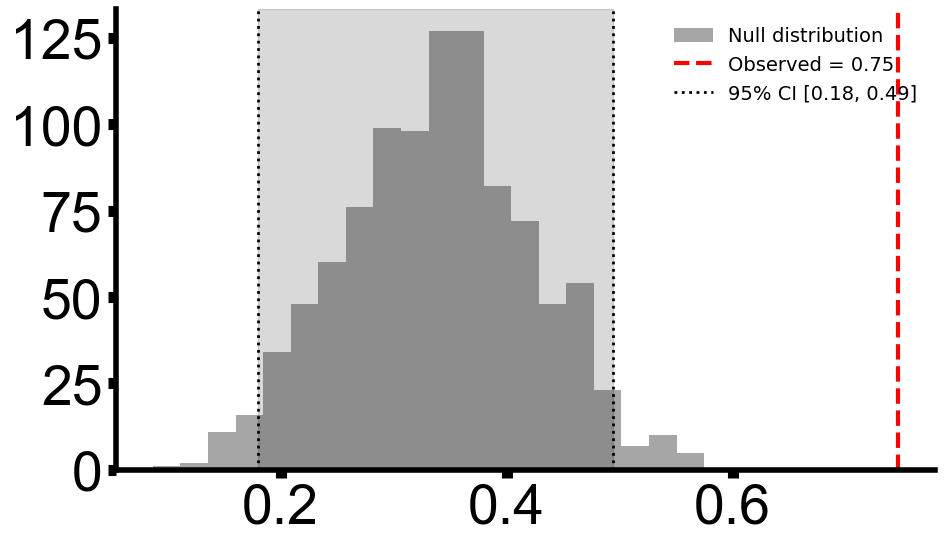

In [930]:
# Plot the null distribution and test accuracy

# ── 95% CI of shuffled null distribution ─────────────────────────────────────
null_arr    = np.array(null_accuracies)
ci_low      = np.percentile(null_arr, 2.5)
ci_high     = np.percentile(null_arr, 97.5)
null_mean   = null_arr.mean()

print(f'\nShuffled null distribution:')
print(f'  Mean         : {null_mean:.3f}')
print(f'  95% CI       : [{ci_low:.3f}, {ci_high:.3f}]')
print(f'  Observed acc : {test_accuracy:.3f}')
print(f'  p-value      : {p_value_accuracy:.3f}')

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.hist(null_arr, bins=20, alpha=0.7, label='Null distribution', color='gray')

# observed accuracy
plt.axvline(test_accuracy, color='red', linestyle='dashed', linewidth=3,
            label=f'Observed = {test_accuracy:.2f}')

# 95% CI bounds
plt.axvline(ci_low,  color='black', linestyle=':', linewidth=2,
            label=f'95% CI [{ci_low:.2f}, {ci_high:.2f}]')
plt.axvline(ci_high, color='black', linestyle=':', linewidth=2)

# shade the CI region
plt.axvspan(ci_low, ci_high, alpha=0.15, color='black', label='_nolegend_')
plt.xticks(fontsize=40, fontfamily='Arial')
plt.yticks(fontsize=40, fontfamily='Arial')
plt.legend(fontsize=14, frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig('.\\figures\\fig1_occupancy_LOO_accuracy.svg')
plt.show()

In [931]:
sourceData_ED1g = pd.DataFrame({'null_accuracy': null_arr})
sourceData_ED1g['observed_accuracy'] = test_accuracy
sourceData_ED1g['p_value'] = p_value_accuracy
sourceData_ED1g['null_ci_low_2p5'] = ci_low
sourceData_ED1g['null_ci_high_97p5'] = ci_high
sourceData_ED1g.to_csv('./sourceData/ED1g.csv', index=False)

Persistence

In [932]:
# SVM classification using cluster persistences

# Define the data

agg_X = agg_cluster_persistence[:, -3:, :].reshape(13, 30)
obs_X = obs_cluster_persistence[:, -3:, :].reshape(13, 27)
non_X = non_cluster_persistence[:, -3:, :].reshape(13, 24)

X = np.concatenate([agg_X, obs_X, non_X], axis=1).T
y = np.array([1]*agg_X.shape[1] + [2]*obs_X.shape[1] + [3]*non_X.shape[1]).reshape(1, -1).T

# Initialize leave-one-out cross-validator
loo = LeaveOneOut()

# Initialize model
model = SVC()

# Store predictions
predictions = []

# Perform leave-one-out cross-validation
for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Train the model
    model.fit(X_train, y_train.ravel())
    
    # Predict the test sample
    y_pred = model.predict(X_test)
    
    # Store the prediction
    predictions.append(y_pred[0])

# Evaluate the model
print('Evaluation on the test set:')
test_accuracy = balanced_accuracy_score(y, predictions)
test_f1 = f1_score(y, predictions, average='weighted')
print(f'Accuracy: {test_accuracy:.2f}')
print(f'F1 Score: {test_f1:.2f}')

# Create null distribution
num_shuffles = 1000
null_accuracies = []
null_f1s = []
np.random.seed(42)
from tqdm import tqdm
for _ in tqdm(range(num_shuffles)):
    y_shuffled = shuffle(y)
    null_predictions = []
    
    for train_index, test_index in loo.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y_shuffled[train_index], y_shuffled[test_index]
        
        # Train the model
        model.fit(X_train, y_train.ravel())
        
        # Predict the test sample
        y_pred = model.predict(X_test)
        
        # Store the prediction
        null_predictions.append(y_pred[0])
    
    # Evaluate the model on shuffled data
    null_accuracies.append(balanced_accuracy_score(y, null_predictions))
    null_f1s.append(f1_score(y, null_predictions, average='weighted'))

Evaluation on the test set:
Accuracy: 0.59
F1 Score: 0.58


100%|██████████| 1000/1000 [01:34<00:00, 10.64it/s]


In [934]:
p_value_accuracy = (np.sum(np.array(null_accuracies) >= test_accuracy) + 1) / (n_permutations + 1)
print(f'p-value for accuracy: {p_value_accuracy:.4f}')

p_value_f1 = (np.sum(np.array(null_f1s) >= test_f1) + 1) / (n_permutations + 1)
print(f'p-value for F1 score: {p_value_f1:.4f}')

p-value for accuracy: 0.0010
p-value for F1 score: 0.0010



Shuffled null distribution:
  Mean         : 0.334
  95% CI       : [0.209, 0.467]
  Observed acc : 0.585
  p-value      : 0.001


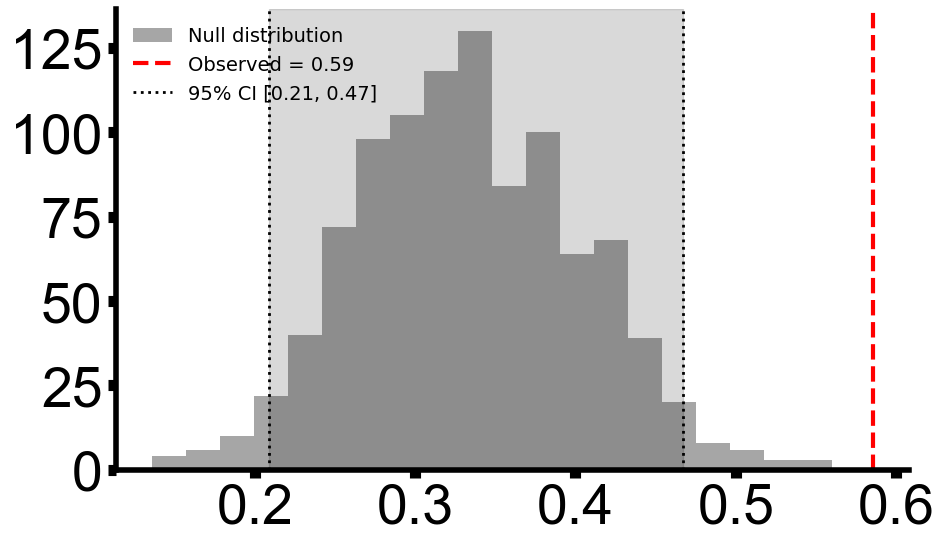

In [935]:
# Plot the null distribution and test accuracy

# ── 95% CI of shuffled null distribution ─────────────────────────────────────
null_arr    = np.array(null_accuracies)
ci_low      = np.percentile(null_arr, 2.5)
ci_high     = np.percentile(null_arr, 97.5)
null_mean   = null_arr.mean()

print(f'\nShuffled null distribution:')
print(f'  Mean         : {null_mean:.3f}')
print(f'  95% CI       : [{ci_low:.3f}, {ci_high:.3f}]')
print(f'  Observed acc : {test_accuracy:.3f}')
print(f'  p-value      : {p_value_accuracy:.3f}')

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.hist(null_arr, bins=20, alpha=0.7, label='Null distribution', color='gray')

# observed accuracy
plt.axvline(test_accuracy, color='red', linestyle='dashed', linewidth=3,
            label=f'Observed = {test_accuracy:.2f}')

# 95% CI bounds
plt.axvline(ci_low,  color='black', linestyle=':', linewidth=2,
            label=f'95% CI [{ci_low:.2f}, {ci_high:.2f}]')
plt.axvline(ci_high, color='black', linestyle=':', linewidth=2)

# shade the CI region
plt.axvspan(ci_low, ci_high, alpha=0.15, color='black', label='_nolegend_')
plt.xticks(fontsize=40, fontfamily='Arial')
plt.yticks(fontsize=40, fontfamily='Arial')
plt.legend(fontsize=14, frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig('.\\figures\\fig1_persistence_LOO_accuracy_score.svg')


In [937]:
sourceData_ED1i_top = pd.DataFrame({'null_accuracy': null_arr})
sourceData_ED1i_top['observed_accuracy'] = test_accuracy
sourceData_ED1i_top['p_value'] = p_value_accuracy
sourceData_ED1i_top['null_ci_low_2p5'] = ci_low
sourceData_ED1i_top['null_ci_high_97p5'] = ci_high
sourceData_ED1i_top.to_csv('./sourceData/ED1i_top.csv', index=False)

### Decoding using vector occupancy / persistence (OBS/XPO)

Occupancy

In [938]:
# SVM classification using cluster occupancies

# Define the data

obs_X = obs_cluster_occupancies[:, -3:, :].reshape(13, 27)
xpo_X = xpo_cluster_occupancies[:, :3, :].reshape(13, 15)

X = np.concatenate([obs_X, xpo_X], axis=1).T
y = np.array([1]*obs_X.shape[1] + [2]*xpo_X.shape[1]).reshape(1, -1).T

# Initialize leave-one-out cross-validator
loo = LeaveOneOut()

# Initialize model
model = SVC()

# Store predictions
predictions = []

# Perform leave-one-out cross-validation
for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Train the model
    model.fit(X_train, y_train.ravel())
    
    # Predict the test sample
    y_pred = model.predict(X_test)
    
    # Store the prediction
    predictions.append(y_pred[0])

# Evaluate the model
print('Evaluation on the test set:')
test_accuracy = balanced_accuracy_score(y, predictions)
test_f1 = f1_score(y, predictions, average='weighted')
print(f'Accuracy: {test_accuracy:.2f}')
print(f'F1 Score: {test_f1:.2f}')

# Create null distribution
num_shuffles = 1000
null_accuracies = []
null_f1s = []
np.random.seed(42)
from tqdm import tqdm
for _ in tqdm(range(num_shuffles)):
    y_shuffled = shuffle(y)
    null_predictions = []
    
    for train_index, test_index in loo.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y_shuffled[train_index], y_shuffled[test_index]
        
        # Train the model
        model.fit(X_train, y_train.ravel())
        
        # Predict the test sample
        y_pred = model.predict(X_test)
        
        # Store the prediction
        null_predictions.append(y_pred[0])
    
    # Evaluate the model on shuffled data
    null_accuracies.append(balanced_accuracy_score(y, null_predictions))
    null_f1s.append(f1_score(y, null_predictions, average='weighted'))

Evaluation on the test set:
Accuracy: 0.70
F1 Score: 0.74


100%|██████████| 1000/1000 [00:38<00:00, 26.04it/s]


In [939]:
p_value_accuracy = (np.sum(np.array(null_accuracies) >= test_accuracy) + 1) / (n_permutations + 1)
print(f'p-value for accuracy: {p_value_accuracy:.4f}')

p_value_f1 = (np.sum(np.array(null_f1s) >= test_f1) + 1) / (n_permutations + 1)
print(f'p-value for F1 score: {p_value_f1:.4f}')

p-value for accuracy: 0.0040
p-value for F1 score: 0.0040



Shuffled null distribution:
  Mean         : 0.493
  95% CI       : [0.407, 0.581]
  Observed acc : 0.696
  p-value      : 0.004


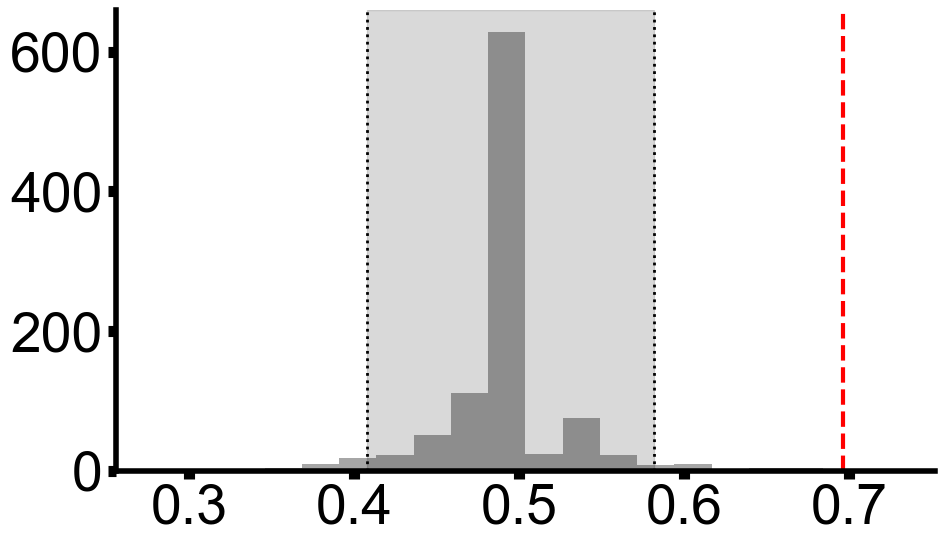

In [941]:
# Plot the null distribution and test accuracy

# ── 95% CI of shuffled null distribution ─────────────────────────────────────
null_arr    = np.array(null_accuracies)
ci_low      = np.percentile(null_arr, 2.5)
ci_high     = np.percentile(null_arr, 97.5)
null_mean   = null_arr.mean()

print(f'\nShuffled null distribution:')
print(f'  Mean         : {null_mean:.3f}')
print(f'  95% CI       : [{ci_low:.3f}, {ci_high:.3f}]')
print(f'  Observed acc : {test_accuracy:.3f}')
print(f'  p-value      : {p_value_accuracy:.3f}')

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.hist(null_arr, bins=20, alpha=0.7, label='Null distribution', color='gray')

# observed accuracy
plt.axvline(test_accuracy, color='red', linestyle='dashed', linewidth=3,
            label=f'Observed = {test_accuracy:.2f}')

# 95% CI bounds
plt.axvline(ci_low,  color='black', linestyle=':', linewidth=2,
            label=f'95% CI [{ci_low:.2f}, {ci_high:.2f}]')
plt.axvline(ci_high, color='black', linestyle=':', linewidth=2)

# shade the CI region
plt.axvspan(ci_low, ci_high, alpha=0.15, color='black', label='_nolegend_')
plt.xticks(fontsize=40, fontfamily='Arial')
plt.yticks(fontsize=40, fontfamily='Arial')
# plt.legend(fontsize=14, frameon=False)
sns.despine()
plt.tight_layout()

plt.savefig('.\\figures\\fig1_occupancy_LOO_accuracy_obs_xpo.svg')

In [942]:
sourceData_ED3b_left = pd.DataFrame({'null_accuracy': null_arr})
sourceData_ED3b_left['observed_accuracy'] = test_accuracy
sourceData_ED3b_left['p_value'] = p_value_accuracy
sourceData_ED3b_left['null_ci_low_2p5'] = ci_low
sourceData_ED3b_left['null_ci_high_97p5'] = ci_high
sourceData_ED3b_left.to_csv('./sourceData/ED3b_left.csv', index=False)

Persistence

In [943]:
# SVM classification using cluster persistences
from sklearn.model_selection import LeaveOneOut
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils import shuffle

# Define the data

obs_X = obs_cluster_persistence[:, -3:, :].reshape(13, 27)
xpo_X = xpo_cluster_persistence[:, :3, :].reshape(13, 15)

X = np.concatenate([obs_X, xpo_X], axis=1).T
y = np.array([1]*obs_X.shape[1] + [2]*xpo_X.shape[1]).reshape(1, -1).T

# Initialize leave-one-out cross-validator
loo = LeaveOneOut()

# Initialize model
model = SVC()

# Store predictions
predictions = []

# Perform leave-one-out cross-validation
for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Train the model
    model.fit(X_train, y_train.ravel())
    
    # Predict the test sample
    y_pred = model.predict(X_test)
    
    # Store the prediction
    predictions.append(y_pred[0])

# Evaluate the model
print('Evaluation on the test set:')
test_accuracy = balanced_accuracy_score(y, predictions)
test_f1 = f1_score(y, predictions, average='weighted')
print(f'Accuracy: {test_accuracy:.2f}')
print(f'F1 Score: {test_f1:.2f}')

# Create null distribution
num_shuffles = 1000
null_accuracies = []
null_f1s = []
np.random.seed(42)
from tqdm import tqdm
for _ in tqdm(range(num_shuffles)):
    y_shuffled = shuffle(y)
    null_predictions = []
    
    for train_index, test_index in loo.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y_shuffled[train_index], y_shuffled[test_index]
        
        # Train the model
        model.fit(X_train, y_train.ravel())
        
        # Predict the test sample
        y_pred = model.predict(X_test)
        
        # Store the prediction
        null_predictions.append(y_pred[0])
    
    # Evaluate the model on shuffled data
    null_accuracies.append(balanced_accuracy_score(y, null_predictions))
    null_f1s.append(f1_score(y, null_predictions, average='weighted'))

Evaluation on the test set:
Accuracy: 0.67
F1 Score: 0.71


100%|██████████| 1000/1000 [00:38<00:00, 25.99it/s]


In [945]:
p_value_accuracy = (np.sum(np.array(null_accuracies) >= test_accuracy) + 1) / (n_permutations + 1)
print(f'p-value for accuracy: {p_value_accuracy:.4f}')

p_value_f1 = (np.sum(np.array(null_f1s) >= test_f1) + 1) / (n_permutations + 1)
print(f'p-value for F1 score: {p_value_f1:.4f}')

p-value for accuracy: 0.0080
p-value for F1 score: 0.0140



Shuffled null distribution:
  Mean         : 0.519
  95% CI       : [0.407, 0.634]
  Observed acc : 0.674
  p-value      : 0.008


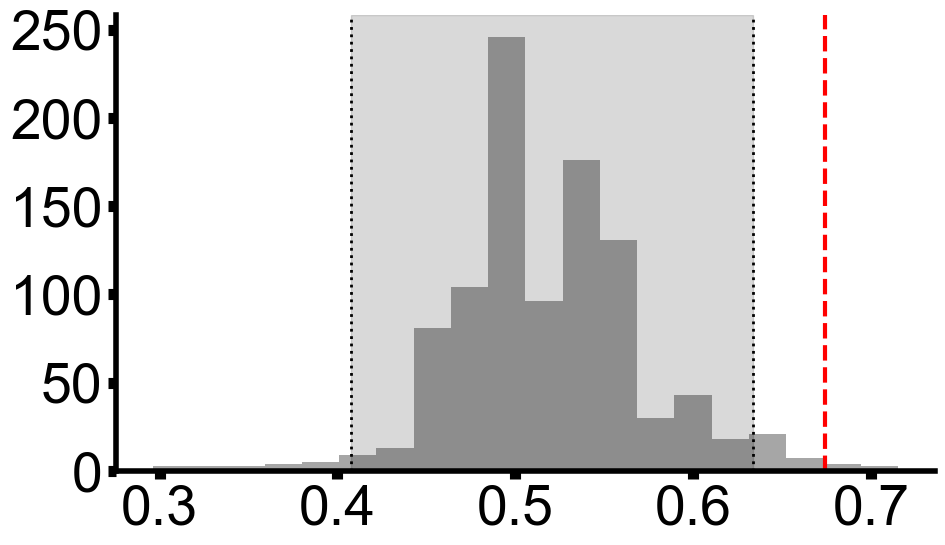

In [946]:
# Plot the null distribution and test accuracy

# ── 95% CI of shuffled null distribution ─────────────────────────────────────
null_arr    = np.array(null_accuracies)
ci_low      = np.percentile(null_arr, 2.5)
ci_high     = np.percentile(null_arr, 97.5)
null_mean   = null_arr.mean()

print(f'\nShuffled null distribution:')
print(f'  Mean         : {null_mean:.3f}')
print(f'  95% CI       : [{ci_low:.3f}, {ci_high:.3f}]')
print(f'  Observed acc : {test_accuracy:.3f}')
print(f'  p-value      : {p_value_accuracy:.3f}')

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.hist(null_arr, bins=20, alpha=0.7, label='Null distribution', color='gray')

# observed accuracy
plt.axvline(test_accuracy, color='red', linestyle='dashed', linewidth=3,
            label=f'Observed = {test_accuracy:.2f}')

# 95% CI bounds
plt.axvline(ci_low,  color='black', linestyle=':', linewidth=2,
            label=f'95% CI [{ci_low:.2f}, {ci_high:.2f}]')
plt.axvline(ci_high, color='black', linestyle=':', linewidth=2)

# shade the CI region
plt.axvspan(ci_low, ci_high, alpha=0.15, color='black', label='_nolegend_')
plt.xticks(fontsize=40, fontfamily='Arial')
plt.yticks(fontsize=40, fontfamily='Arial')
# plt.legend(fontsize=14, frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig('.\\figures\\fig1_persistence_LOO_accuracy_obs_xpo.svg')

In [947]:
sourceData_ED3b_middle = pd.DataFrame({'null_accuracy': null_arr})
sourceData_ED3b_middle['observed_accuracy'] = test_accuracy
sourceData_ED3b_middle['p_value'] = p_value_accuracy
sourceData_ED3b_middle['null_ci_low_2p5'] = ci_low
sourceData_ED3b_middle['null_ci_high_97p5'] = ci_high
sourceData_ED3b_middle.to_csv('./sourceData/ED3b_middle.csv', index=False)

### EXP/NON model predicting on OBS/XPO data

c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\scipy\stats\_axis_nan_policy.py:531: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\scipy\stats\_stats_py.py:9485: RuntimeWarning: divide by zero encountered in double_scalars
  wbfn /= (nx + ny) * np.sqrt(nx * Sx + ny * Sy)
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\scipy\stats\_stats_py.py:9491: RuntimeWarning: invalid value encountered in double_scalars
  df = df_numer / df_denom
c:\Users\FalknerLab\miniconda3\envs\multifiber\lib\site-packages\scipy\stats\_axis_nan_policy.py:531: RuntimeWarning: p-value cannot be estimated with `distribution='t' because degrees of freedom parameter is undefined (0/0). Try using `distribution='normal'
  res = hypotest_fun_out(*samples, **kwds)



OBS vs XPO — cluster occupancy (selected clusters; p_fdr computed against full social/asocial family, not just this subset)
Category       Cluster    Alt        Test                               Stat       df      p_raw      p_fdr   Sig
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Aggressive     Cluster 2  greater    t-test                           1.0244     12.0     0.1629     0.3258      
Aggressive     Cluster 4  greater    Brunner-Munzel                  -6.0178      n/a  5.676e-05     0.0002   ***
──────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Investigative  Cluster 5  greater    Mann-Whitney U (BM degenerate — fallback)    45.0000      n/a     0.0013     0.0036    **
Investigative  Cluster 7  greater    Brunner-Munzel                  -8.5491      n/a  1.921e-05     0.0002   ***
──────────────────────────────

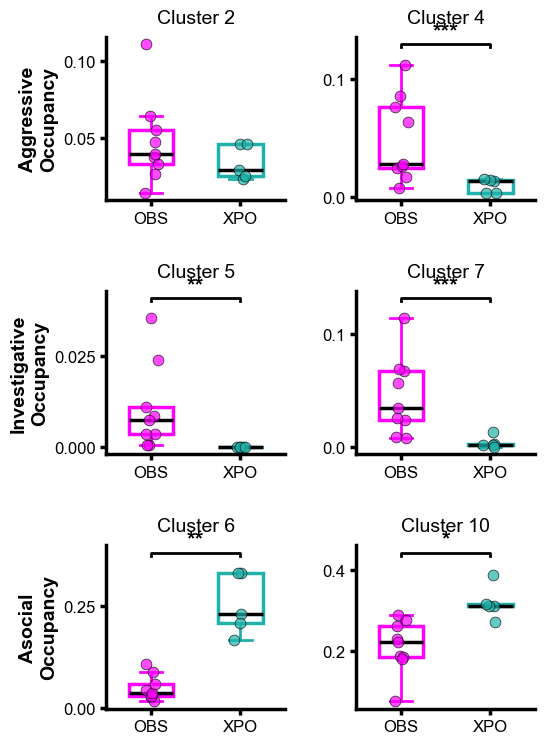

In [1085]:
from scipy.stats import shapiro, levene, bartlett, ttest_ind, brunnermunzel, mannwhitneyu
from statsmodels.stats.multitest import multipletests

def format_p(p):
    if p is None or np.isnan(p): return 'n/a'
    return f'{p:.3e}' if p < 1e-4 else f'{p:.4f}'

def get_sig(p):
    if p is None or np.isnan(p): return ''
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''

def compute_df_for_test(test_name, a, b):
    if test_name == 't-test':
        return len(a) + len(b) - 2
    elif test_name == 'Welch t-test':
        v1, v2 = np.var(a, ddof=1), np.var(b, ddof=1)
        n1, n2 = len(a), len(b)
        return (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
    else:
        return np.nan

def run_pairwise_stats(a, b, alternative='two-sided', alpha=0.05, variance_alpha=0.05):
    if len(a) < 3 or len(b) < 3:
        return {'test': 'n/a', 'statistic': np.nan, 'df': np.nan, 'p_value': np.nan}

    _, p_norm_a = shapiro(a)
    _, p_norm_b = shapiro(b)
    normality_passed = (p_norm_a > alpha) and (p_norm_b > alpha)

    _, levene_p = levene(a, b)
    equal_variances = levene_p > variance_alpha
    if normality_passed:
        _, bartlett_p = bartlett(a, b)
        equal_variances = equal_variances and (bartlett_p > variance_alpha)

    if normality_passed and equal_variances:
        stat, p = ttest_ind(a, b, equal_var=True, alternative=alternative)
        test_name = 't-test'
    elif normality_passed and not equal_variances:
        stat, p = ttest_ind(a, b, equal_var=False, alternative=alternative)
        test_name = 'Welch t-test'
    else:
        stat, p = brunnermunzel(a, b, alternative=alternative)
        test_name = 'Brunner-Munzel'
        if not np.isfinite(stat) or not np.isfinite(p):
            stat, p = mannwhitneyu(a, b, alternative=alternative)
            test_name = 'Mann-Whitney U (BM degenerate — fallback)'

    df_val = compute_df_for_test(test_name, a, b)
    return {'test': test_name, 'statistic': stat, 'df': df_val, 'p_value': p}


# ── Cluster categories (full set — needed to preserve correct FDR family) ────
aggressive_indices     = [0, 1, 2, 3]
investigative_indices  = [4, 6, 7, 8]
asocial_indices        = [5, 9, 10, 11, 12]

cluster_labels = {
    0: 'Cluster 1', 1: 'Cluster 2', 2: 'Cluster 3', 3: 'Cluster 4',
    4: 'Cluster 5', 6: 'Cluster 7', 7: 'Cluster 8', 8: 'Cluster 9',
    5: 'Cluster 6', 9: 'Cluster 10', 10: 'Cluster 11', 11: 'Cluster 12', 12: 'Cluster 13',
}

obs_occ_per_animal = np.nanmean(obs_cluster_occupancies[:, :3, :], axis=1)
xpo_occ_per_animal = np.nanmean(xpo_cluster_occupancies[:, :3, :], axis=1)

row_configs = [
    ('Aggressive',    aggressive_indices,    'greater'),
    ('Investigative', investigative_indices, 'greater'),
    ('Asocial',       asocial_indices,       'two-sided'),
]

results_by_row = {}
raw_p_social, keys_social   = [], []
raw_p_asocial, keys_asocial = [], []

for row_label, indices, alt in row_configs:
    results_by_row[row_label] = {}
    for c in indices:
        obs_d = obs_occ_per_animal[c, :]
        xpo_d = xpo_occ_per_animal[c, :]
        obs_d = obs_d[~np.isnan(obs_d)]
        xpo_d = xpo_d[~np.isnan(xpo_d)]

        result = run_pairwise_stats(obs_d, xpo_d, alternative=alt)
        results_by_row[row_label][c] = {'obs_data': obs_d, 'xpo_data': xpo_d, **result, 'alternative': alt}

        if row_label in ('Aggressive', 'Investigative'):
            raw_p_social.append(result['p_value']); keys_social.append((row_label, c))
        else:
            raw_p_asocial.append(result['p_value']); keys_asocial.append((row_label, c))

def fdr_correct(pvals):
    valid = [i for i, p in enumerate(pvals) if not np.isnan(p)]
    corr_full = np.full(len(pvals), np.nan)
    if valid:
        _, corr, _, _ = multipletests([pvals[i] for i in valid], method='fdr_bh')
        for rank, i in enumerate(valid):
            corr_full[i] = corr[rank]
    return corr_full

p_fdr_social  = fdr_correct(raw_p_social)
p_fdr_asocial = fdr_correct(raw_p_asocial)

for (row_label, c), p_corr in zip(keys_social, p_fdr_social):
    results_by_row[row_label][c]['p_corrected'] = p_corr
for (row_label, c), p_corr in zip(keys_asocial, p_fdr_asocial):
    results_by_row[row_label][c]['p_corrected'] = p_corr

# ── Subset to the six requested clusters, grouped by category ────────────────
plot_selection = [
    ('Aggressive',    [1, 3]),   # Cluster 2, Cluster 4
    ('Investigative', [4, 6]),   # Cluster 5, Cluster 7
    ('Asocial',       [5, 9]),   # Cluster 6, Cluster 10
]

# ── Print stats table — selected clusters only, p_fdr still reflects full family ──
print(f'\n{"="*130}')
print(f'OBS vs XPO — cluster occupancy (selected clusters; p_fdr computed against full '
      f'social/asocial family, not just this subset)')
print(f'{"="*130}')
print(f'{"Category":<14} {"Cluster":<10} {"Alt":<10} {"Test":<28} {"Stat":>10} {"df":>8} '
      f'{"p_raw":>10} {"p_fdr":>10} {"Sig":>5}')
print(f'{"─"*130}')
for row_label, indices in plot_selection:
    for c in indices:
        r = results_by_row[row_label][c]
        stat_str = f'{r["statistic"]:.4f}' if not np.isnan(r['statistic']) else 'n/a'
        df_str   = f'{r["df"]:.1f}'        if not np.isnan(r['df'])        else 'n/a'
        print(f'{row_label:<14} {cluster_labels[c]:<10} {r["alternative"]:<10} {r["test"]:<28} '
              f'{stat_str:>10} {df_str:>8} {format_p(r["p_value"]):>10} '
              f'{format_p(r["p_corrected"]):>10} {get_sig(r["p_corrected"]):>5}')
    print(f'{"─"*130}')
print(f'{"="*130}')

# ── Plot: 3 rows (category) x 2 columns (requested clusters), no shared axes ─
plt.close()
fig, axes = plt.subplots(3, 2, figsize=(6, 8), sharey=False)

colors = ['magenta', 'lightseagreen']
positions = [1, 2]
rng = np.random.default_rng(42)

for row_idx, (row_label, indices) in enumerate(plot_selection):
    for col_idx, c in enumerate(indices):
        ax = axes[row_idx, col_idx]
        r = results_by_row[row_label][c]
        data_to_plot = [r['obs_data'], r['xpo_data']]

        box = ax.boxplot(data_to_plot, positions=positions, patch_artist=True, widths=0.5,
                         medianprops=dict(color='black', linewidth=2.5),
                         whiskerprops=dict(linewidth=2), capprops=dict(linewidth=2),
                         flierprops=dict(marker='', markersize=0))
        for patch, color in zip(box['boxes'], colors):
            patch.set_edgecolor(color); patch.set_facecolor('white'); patch.set_linewidth(2.5)
        for whisker, color in zip(box['whiskers'], [c2 for c2 in colors for _ in (0, 1)]):
            whisker.set_color(color)
        for cap, color in zip(box['caps'], [c2 for c2 in colors for _ in (0, 1)]):
            cap.set_color(color)

        for j, (data, color) in enumerate(zip(data_to_plot, colors)):
            jitter = rng.uniform(-0.08, 0.08, size=len(data))
            ax.scatter(np.full(len(data), positions[j]) + jitter, data,
                       color=color, edgecolor='black', s=60, alpha=0.7, zorder=5, linewidths=0.6)

        ax.autoscale()
        y_max = ax.get_ylim()[1]
        bracket_y = y_max * 1.1
        sig = get_sig(r['p_corrected'])
        if sig:
            ax.plot([positions[0], positions[0], positions[1], positions[1]],
                    [bracket_y * 0.98, bracket_y, bracket_y, bracket_y * 0.98], 'k-', linewidth=2)
            ax.text(1.5, bracket_y * 1.02, sig, ha='center', va='bottom',
                    fontsize=16, fontfamily='Arial', fontweight='bold')

        ax.set_xticks(positions)
        ax.set_xticklabels(['OBS', 'XPO'], fontsize=14, fontfamily='Arial')
        for tick in ax.get_xticklabels() + ax.get_yticklabels():
            tick.set_fontfamily('Arial'); tick.set_fontsize(12)
        for spine in ax.spines.values():
            spine.set_linewidth(2.5)
        ax.tick_params(axis='both', length=4, width=2.5)

        ax.set_title(cluster_labels[c], fontsize=14, fontfamily='Arial', pad=10)
        if col_idx == 0:
            ax.set_ylabel(f'{row_label}\nOccupancy', fontsize=14, fontfamily='Arial', fontweight='bold')

        sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('.\\figures\\fig1_behavior_occupancy_obs_xpo_selected.svg', dpi=300, bbox_inches='tight')
plt.show()

# ── Source data export ────────────────────────────────────────────────────────
os.makedirs('./sourceData', exist_ok=True)

rows_out = []
for row_label, indices in plot_selection:
    for c in indices:
        r = results_by_row[row_label][c]
        for group_label, vals in [('OBS', r['obs_data']), ('XPO', r['xpo_data'])]:
            for v in vals:
                rows_out.append({
                    'category': row_label,
                    'cluster': cluster_labels[c],
                    'group': group_label,
                    'occupancy': v,
                    'alternative': r['alternative'],
                    'test': r['test'],
                    'stat': r['statistic'],
                    'df': r['df'],
                    'p_raw': r['p_value'],
                    'p_fdr': r['p_corrected'],
                })

sourceData_ED3c = pd.DataFrame(rows_out)
sourceData_ED3c.to_csv('./sourceData/ED3c.csv', index=False)  # rename once panel label confirmed

In [1086]:
# ── Source data export: ED3c  ────────────────────────────────────────────
os.makedirs('./sourceData', exist_ok=True)

rows_out = []
for row_label, indices in plot_selection:
    for c in indices:
        r = results_by_row[row_label][c]
        for group_label, vals in [('OBS', r['obs_data']), ('XPO', r['xpo_data'])]:
            for v in vals:
                rows_out.append({
                    'category': row_label,
                    'cluster': cluster_labels[c],
                    'group': group_label,
                    'occupancy': v,
                    'alternative': r['alternative'],
                    'test': r['test'],
                    'stat': r['statistic'],
                    'df': r['df'],
                    'p_raw': r['p_value'],
                    'p_fdr': r['p_corrected'],
                })

sourceData_ED3c = pd.DataFrame(rows_out)
sourceData_ED3c.to_csv('./sourceData/ED3c.csv', index=False)

Are OBS more EXP-like than XPO?

Percentage of OBS classified as AGG: 44.44%
Percentage of XPO classified as AGG: 0.00%
Brunner-Munzel Test (on P(AGG) scores): W = -2.956, p = 0.0193

Contingency table:
                AGG    NON
         OBS      4      5
         XPO      0      5

Fisher's Exact Test (secondary, thresholded): p = 0.2208, odds ratio = inf


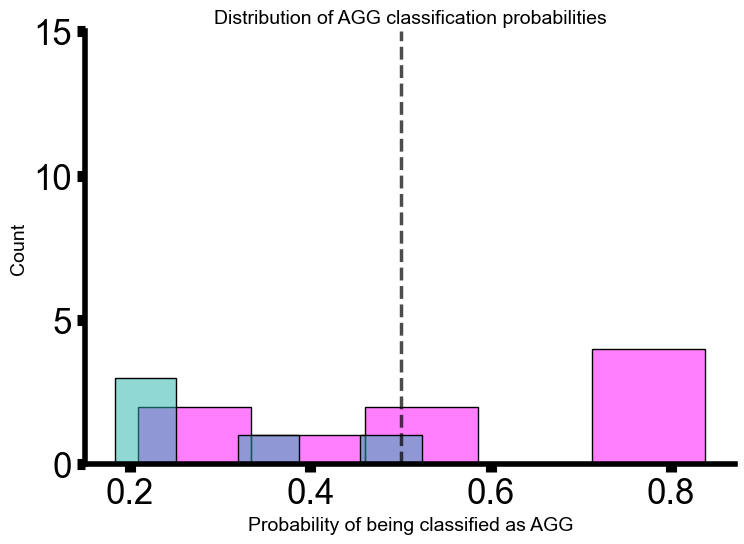

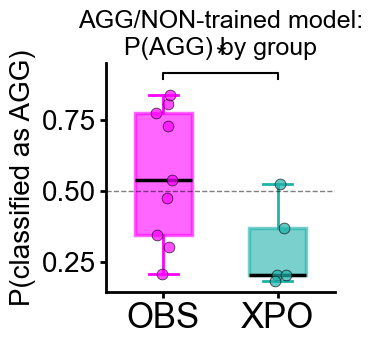

In [964]:
# Train classifier on animal occupancies -> measure probability of being classified as EXP

from scipy.stats import fisher_exact, brunnermunzel, shapiro, levene

# 1. Train model on AGG/NON data
agg_X = np.nanmean(agg_cluster_occupancies[:, -3:, :], axis=1)
non_X = np.nanmean(non_cluster_occupancies[:, -3:, :], axis=1)

X_train = np.concatenate([agg_X, non_X], axis=1).T
y_train = np.array([1]*agg_X.shape[1] + [0]*non_X.shape[1])
np.random.seed(1459)

model = SVC(probability=True)
model.fit(X_train, y_train)

# 2. Apply the model to OBS/XPO data
obs_X = np.nanmean(obs_cluster_occupancies[:, -3:, :], axis=1)
xpo_X = np.nanmean(xpo_cluster_occupancies[:, :3, :], axis=1)

obs_labels = np.ones(obs_X.shape[1])
xpo_labels = np.zeros(xpo_X.shape[1])

X_test = np.concatenate([obs_X, xpo_X], axis=1).T
y_test = np.concatenate([obs_labels, xpo_labels])

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

obs_preds = y_pred[:obs_X.shape[1]]
xpo_preds = y_pred[obs_X.shape[1]:]
obs_proba = y_pred_proba[:obs_X.shape[1]]
xpo_proba = y_pred_proba[obs_X.shape[1]:]

obs_classified_as_agg = np.mean(obs_preds == 1)
xpo_classified_as_agg = np.mean(xpo_preds == 1)

print(f"Percentage of OBS classified as AGG: {obs_classified_as_agg*100:.2f}%")
print(f"Percentage of XPO classified as AGG: {xpo_classified_as_agg*100:.2f}%")

# ── Primary test: Brunner-Munzel on continuous P(AGG) scores ─────────────────
stat_bm, p_bm = brunnermunzel(obs_proba, xpo_proba, alternative='two-sided')
print(f"Brunner-Munzel Test (on P(AGG) scores): W = {stat_bm:.3f}, p = {p_bm:.4f}")

# ── Secondary/robustness test: Fisher's exact on thresholded predictions ─────
contingency_table = np.array([
    [np.sum(obs_preds == 1), np.sum(obs_preds == 0)],
    [np.sum(xpo_preds == 1), np.sum(xpo_preds == 0)]
])

print(f"\nContingency table:")
print(f"{'':>12} {'AGG':>6} {'NON':>6}")
print(f"{'OBS':>12} {contingency_table[0,0]:>6} {contingency_table[0,1]:>6}")
print(f"{'XPO':>12} {contingency_table[1,0]:>6} {contingency_table[1,1]:>6}")

odds_ratio, p_fisher = fisher_exact(contingency_table)
print(f"\nFisher's Exact Test (secondary, thresholded): p = {p_fisher:.4f}, odds ratio = {odds_ratio:.2f}")

# ========== Visualization ==========

# Histogram of AGG probabilities (unchanged)
fig, ax = plt.subplots(figsize=(8, 6))
sns.histplot(obs_proba, color='magenta', alpha=0.5, label='OBS', kde=False, bins=5, ax=ax)
sns.histplot(xpo_proba, color='lightseagreen', alpha=0.5, label='XPO', kde=False, bins=5, ax=ax)
ax.axvline(0.5, color='black', linestyle='--', alpha=0.7)
ax.set_xlabel('Probability of being classified as AGG', fontsize=14, fontfamily='Arial')
ax.set_ylabel('Count', fontsize=14, fontfamily='Arial')
ax.set_title('Distribution of AGG classification probabilities', fontsize=14, fontfamily='Arial')
ax.set_yticks([0, 5, 10, 15])
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily('Arial')
    label.set_fontsize(25)
sns.despine()
plt.tight_layout()
plt.savefig('./figures/fig1_agg_classifier_obs_xpo_probabilities.svg')
plt.show()

# ── Boxplot + jittered individual animals of P(AGG), replacing the bar plot ──
def get_sig(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n.s.'

fig, ax = plt.subplots(figsize=(4, 4))
data_to_plot = [obs_proba, xpo_proba]
positions = [0, 1]
colors = ['magenta', 'lightseagreen']

box = ax.boxplot(data_to_plot, positions=positions, patch_artist=True, widths=0.5,
                 medianprops=dict(color='black', linewidth=2.5),
                 whiskerprops=dict(linewidth=2), capprops=dict(linewidth=2),
                 flierprops=dict(marker='', markersize=0))
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor(color)
    patch.set_alpha(0.6)
    patch.set_linewidth(2.5)
for whisker, color in zip(box['whiskers'], [c for c in colors for _ in (0, 1)]):
    whisker.set_color(color)
for cap, color in zip(box['caps'], [c for c in colors for _ in (0, 1)]):
    cap.set_color(color)

rng = np.random.default_rng(42)
for j, (data, color) in enumerate(zip(data_to_plot, colors)):
    jitter = rng.uniform(-0.08, 0.08, size=len(data))
    ax.scatter(np.full(len(data), positions[j]) + jitter, data,
               color=color, edgecolor='black', s=60, alpha=0.7, zorder=5, linewidths=0.6)

ax.axhline(0.5, color='black', linestyle='--', alpha=0.5, linewidth=1)
ax.set_xticks(positions)
ax.set_xticklabels(['OBS', 'XPO'], fontsize=25, fontfamily='Arial')
ax.set_ylabel('P(classified as AGG)', fontsize=20, fontfamily='Arial')
ax.set_title('AGG/NON-trained model:\nP(AGG) by group', fontsize=18, fontfamily='Arial')
for label in ax.get_yticklabels():
    label.set_fontfamily('Arial')
    label.set_fontsize(20)

ax.autoscale()
y_max = ax.get_ylim()[1]
bracket_y = y_max * 1.05
sig_label = get_sig(p_bm)
ax.plot([positions[0], positions[0], positions[1], positions[1]],
        [bracket_y * 0.98, bracket_y, bracket_y, bracket_y * 0.98], 'k-', linewidth=1.5)
ax.text(0.5, bracket_y * 1.01, sig_label, ha='center', va='bottom', fontsize=20, fontfamily='Arial')

for spine in ax.spines.values():
    spine.set_linewidth(2)
ax.tick_params(axis='both', length=4, width=2)
sns.despine()
plt.tight_layout()
plt.savefig('./figures/fig1_agg_classifier_obs_xpo_probabilities_boxplot.svg')
plt.show()

In [965]:
# ── Source data export: ED3f_left ─────────────────────────────────────────────
os.makedirs('./sourceData', exist_ok=True)

sourceData_ED3f_left = pd.concat([
    pd.DataFrame({'group': 'OBS', 'p_AGG': obs_proba}),
    pd.DataFrame({'group': 'XPO', 'p_AGG': xpo_proba}),
], ignore_index=True)

sourceData_ED3f_left['test'] = 'Brunner-Munzel'
sourceData_ED3f_left['alternative'] = 'two-sided'
sourceData_ED3f_left['statistic'] = stat_bm
sourceData_ED3f_left['p_value'] = p_bm

sourceData_ED3f_left.to_csv('./sourceData/ED3f_left.csv', index=False)

Percentage of OBS classified as AGG: 66.67%
Percentage of XPO classified as AGG: 0.00%
Brunner-Munzel Test (on P(AGG) scores): W = -3.164, p = 0.0083

Contingency table:
                AGG    NON
         OBS      6      3
         XPO      0      5

Fisher's Exact Test (secondary, thresholded): p = 0.0310, odds ratio = inf


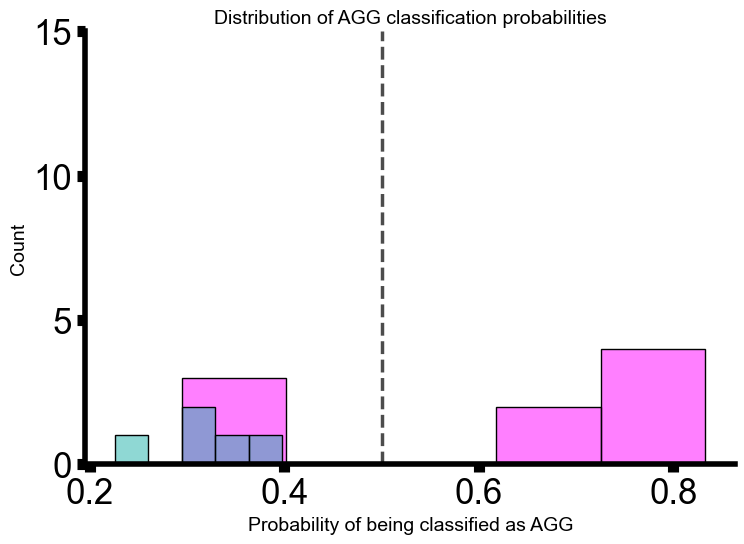

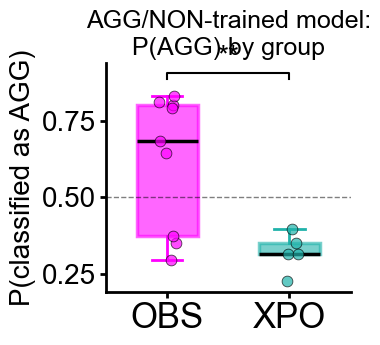

In [966]:
# Train classifier on animal occupancies -> measure probability of being classified as EXP

from scipy.stats import fisher_exact, brunnermunzel, shapiro, levene

# 1. Train model on AGG/NON data
agg_X = np.nanmean(agg_cluster_persistence[:, -3:, :], axis=1)
non_X = np.nanmean(non_cluster_persistence[:, -3:, :], axis=1)

X_train = np.concatenate([agg_X, non_X], axis=1).T
y_train = np.array([1]*agg_X.shape[1] + [0]*non_X.shape[1])
np.random.seed(1459)

model = SVC(probability=True)
model.fit(X_train, y_train)

# 2. Apply the model to OBS/XPO data
obs_X = np.nanmean(obs_cluster_persistence[:, -3:, :], axis=1)
xpo_X = np.nanmean(xpo_cluster_persistence[:, :3, :], axis=1)

obs_labels = np.ones(obs_X.shape[1])
xpo_labels = np.zeros(xpo_X.shape[1])

X_test = np.concatenate([obs_X, xpo_X], axis=1).T
y_test = np.concatenate([obs_labels, xpo_labels])

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

obs_preds = y_pred[:obs_X.shape[1]]
xpo_preds = y_pred[obs_X.shape[1]:]
obs_proba = y_pred_proba[:obs_X.shape[1]]
xpo_proba = y_pred_proba[obs_X.shape[1]:]

obs_classified_as_agg = np.mean(obs_preds == 1)
xpo_classified_as_agg = np.mean(xpo_preds == 1)

print(f"Percentage of OBS classified as AGG: {obs_classified_as_agg*100:.2f}%")
print(f"Percentage of XPO classified as AGG: {xpo_classified_as_agg*100:.2f}%")

# ── Primary test: Brunner-Munzel on continuous P(AGG) scores ─────────────────
stat_bm, p_bm = brunnermunzel(obs_proba, xpo_proba, alternative='two-sided')
print(f"Brunner-Munzel Test (on P(AGG) scores): W = {stat_bm:.3f}, p = {p_bm:.4f}")

# ── Secondary/robustness test: Fisher's exact on thresholded predictions ─────
contingency_table = np.array([
    [np.sum(obs_preds == 1), np.sum(obs_preds == 0)],
    [np.sum(xpo_preds == 1), np.sum(xpo_preds == 0)]
])

print(f"\nContingency table:")
print(f"{'':>12} {'AGG':>6} {'NON':>6}")
print(f"{'OBS':>12} {contingency_table[0,0]:>6} {contingency_table[0,1]:>6}")
print(f"{'XPO':>12} {contingency_table[1,0]:>6} {contingency_table[1,1]:>6}")

odds_ratio, p_fisher = fisher_exact(contingency_table)
print(f"\nFisher's Exact Test (secondary, thresholded): p = {p_fisher:.4f}, odds ratio = {odds_ratio:.2f}")

# ========== Visualization ==========

# Histogram of AGG probabilities (unchanged)
fig, ax = plt.subplots(figsize=(8, 6))
sns.histplot(obs_proba, color='magenta', alpha=0.5, label='OBS', kde=False, bins=5, ax=ax)
sns.histplot(xpo_proba, color='lightseagreen', alpha=0.5, label='XPO', kde=False, bins=5, ax=ax)
ax.axvline(0.5, color='black', linestyle='--', alpha=0.7)
ax.set_xlabel('Probability of being classified as AGG', fontsize=14, fontfamily='Arial')
ax.set_ylabel('Count', fontsize=14, fontfamily='Arial')
ax.set_title('Distribution of AGG classification probabilities', fontsize=14, fontfamily='Arial')
ax.set_yticks([0, 5, 10, 15])
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily('Arial')
    label.set_fontsize(25)
sns.despine()
plt.tight_layout()
# plt.savefig('./figures/fig1_agg_classifier_obs_xpo_probabilities.svg')
plt.show()

# ── Boxplot + jittered individual animals of P(AGG), replacing the bar plot ──
def get_sig(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n.s.'

fig, ax = plt.subplots(figsize=(4, 4))
data_to_plot = [obs_proba, xpo_proba]
positions = [0, 1]
colors = ['magenta', 'lightseagreen']

box = ax.boxplot(data_to_plot, positions=positions, patch_artist=True, widths=0.5,
                 medianprops=dict(color='black', linewidth=2.5),
                 whiskerprops=dict(linewidth=2), capprops=dict(linewidth=2),
                 flierprops=dict(marker='', markersize=0))
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor(color)
    patch.set_alpha(0.6)
    patch.set_linewidth(2.5)
for whisker, color in zip(box['whiskers'], [c for c in colors for _ in (0, 1)]):
    whisker.set_color(color)
for cap, color in zip(box['caps'], [c for c in colors for _ in (0, 1)]):
    cap.set_color(color)

rng = np.random.default_rng(42)
for j, (data, color) in enumerate(zip(data_to_plot, colors)):
    jitter = rng.uniform(-0.08, 0.08, size=len(data))
    ax.scatter(np.full(len(data), positions[j]) + jitter, data,
               color=color, edgecolor='black', s=60, alpha=0.7, zorder=5, linewidths=0.6)

ax.axhline(0.5, color='black', linestyle='--', alpha=0.5, linewidth=1)
ax.set_xticks(positions)
ax.set_xticklabels(['OBS', 'XPO'], fontsize=25, fontfamily='Arial')
ax.set_ylabel('P(classified as AGG)', fontsize=20, fontfamily='Arial')
ax.set_title('AGG/NON-trained model:\nP(AGG) by group', fontsize=18, fontfamily='Arial')
for label in ax.get_yticklabels():
    label.set_fontfamily('Arial')
    label.set_fontsize(20)

ax.autoscale()
y_max = ax.get_ylim()[1]
bracket_y = y_max * 1.05
sig_label = get_sig(p_bm)
ax.plot([positions[0], positions[0], positions[1], positions[1]],
        [bracket_y * 0.98, bracket_y, bracket_y, bracket_y * 0.98], 'k-', linewidth=1.5)
ax.text(0.5, bracket_y * 1.01, sig_label, ha='center', va='bottom', fontsize=20, fontfamily='Arial')

for spine in ax.spines.values():
    spine.set_linewidth(2)
ax.tick_params(axis='both', length=4, width=2)
sns.despine()
plt.tight_layout()
plt.savefig('./figures/fig1_agg_classifier_obs_xpo_probabilities_persistence_boxplot.svg')
plt.show()

In [ ]:
# ── Source data export: ED3f_middle ─────────────────────────────────────────────
os.makedirs('./sourceData', exist_ok=True)

sourceData_ED3f_middle = pd.concat([
    pd.DataFrame({'group': 'OBS', 'p_AGG': obs_proba}),
    pd.DataFrame({'group': 'XPO', 'p_AGG': xpo_proba}),
], ignore_index=True)

sourceData_ED3f_middle['test'] = 'Brunner-Munzel'
sourceData_ED3f_middle['alternative'] = 'two-sided'
sourceData_ED3f_middle['statistic'] = stat_bm
sourceData_ED3f_middle['p_value'] = p_bm

sourceData_ED3f_middle.to_csv('./sourceData/ED3f_middle.csv', index=False)

In [ ]:
sourceData_ED3g = pd.concat([
    pd.DataFrame({'group': 'OBS', 'p_AGG': obs_proba, 'predicted_label': obs_preds}),
    pd.DataFrame({'group': 'XPO', 'p_AGG': xpo_proba, 'predicted_label': xpo_preds}),
], ignore_index=True)

sourceData_ED3g['fisher_p']       = p_fisher
sourceData_ED3g['fisher_odds_ratio'] = odds_ratio
sourceData_ED3g['mannwhitney_U']  = u_stat
sourceData_ED3g['mannwhitney_p']  = p_mwu

sourceData_ED3g.to_csv('./sourceData/ED3g.csv', index=False)

PCA to visualize group separations

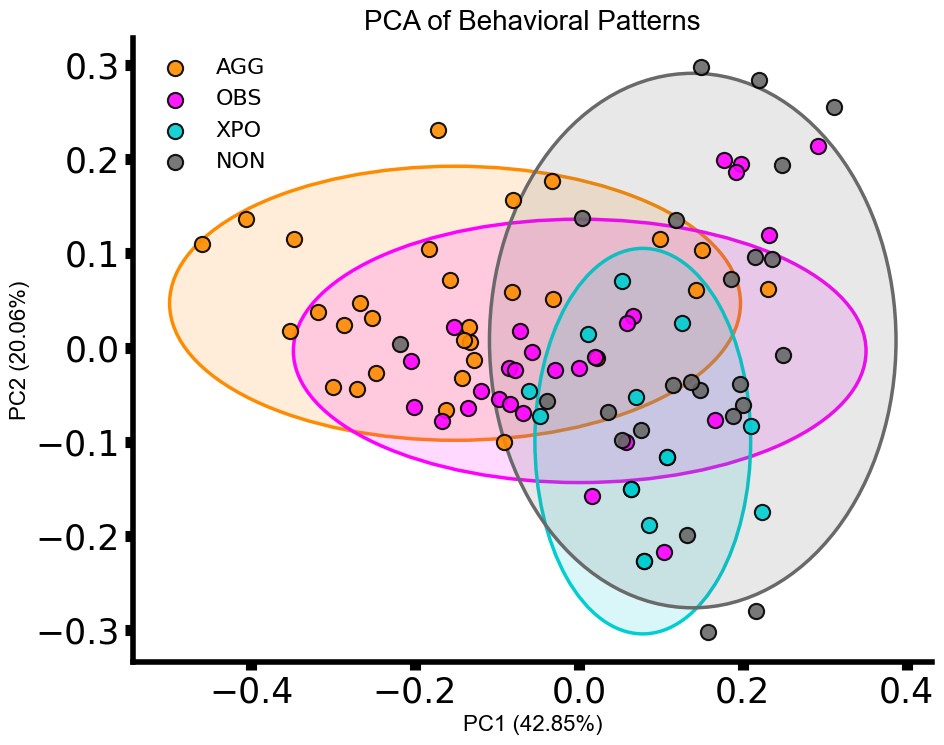

In [968]:
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms

# Prepare data matrices combining all animals for each condition
agg_data = agg_cluster_occupancies[:, -3:, :].reshape(13, -1).T
obs_data = obs_cluster_occupancies[:, -3:, :].reshape(13, -1).T
non_data = non_cluster_occupancies[:, -3:, :].reshape(13, -1).T
xpo_data = xpo_cluster_occupancies[:, :3, :].reshape(13, -1).T

# Stack all data for PCA
all_data = np.vstack([agg_data, obs_data, xpo_data, non_data])
labels = np.concatenate([
    ['AGG'] * agg_data.shape[0], 
    ['OBS'] * obs_data.shape[0],
    ['XPO'] * xpo_data.shape[0],
    ['NON'] * non_data.shape[0]
])

# Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(all_data)

# Create a DataFrame for easier plotting
pca_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'Condition': labels
})

# Define confidence ellipse function
def confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    mean_x, mean_y = np.mean(x), np.mean(y)
    cov = np.cov(x, y)
    pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson) * n_std * np.sqrt(cov[0, 0])
    ell_radius_y = np.sqrt(1 - pearson) * n_std * np.sqrt(cov[1, 1])
    ellipse = Ellipse((mean_x, mean_y), width=ell_radius_x * 2, height=ell_radius_y * 2, **kwargs)
    return ax.add_patch(ellipse)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

# Sharper, more saturated colors
colors = {
    'AGG': '#FF8C00',      # Darker orange
    'OBS': '#FF00FF',      # Pure magenta
    'XPO': '#00CED1',      # Darker cyan
    'NON': '#696969'       # Darker gray
}

# Plot ellipses first (behind the points)
for condition, color in colors.items():
    subset = pca_df[pca_df['Condition'] == condition]
    
    # Add filled ellipse with lighter alpha
    confidence_ellipse(subset['PC1'], subset['PC2'], ax, 
                      alpha=0.15, facecolor=color, edgecolor='none')
    
    # Add ellipse outline with darker edge
    confidence_ellipse(subset['PC1'], subset['PC2'], ax, 
                      alpha=1.0, facecolor='none', edgecolor=color, linewidth=2.5)

# Plot scatter points on top
for condition, color in colors.items():
    subset = pca_df[pca_df['Condition'] == condition]
    ax.scatter(subset['PC1'], subset['PC2'], c=color, label=condition, 
              s=120, alpha=0.9, edgecolors='black', linewidths=1.5, zorder=3)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=16, fontfamily='Arial')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=16, fontfamily='Arial')
ax.set_title('PCA of Behavioral Patterns', fontsize=20, fontfamily='Arial')
ax.legend(fontsize=16, frameon=False)
sns.despine()
plt.tight_layout()
# plt.savefig('./figures/fig1/pca_visualization.svg', dpi=300, bbox_inches='tight')
plt.show()

In [76]:
sourceData_Fig1r = pca_df.copy()
sourceData_Fig1r['PC1_explained_variance'] = pca.explained_variance_ratio_[0]
sourceData_Fig1r['PC2_explained_variance'] = pca.explained_variance_ratio_[1]

sourceData_Fig1r.to_csv('./sourceData/Fig1r.csv', index=False)

Assessing group similarities

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_45872\660521303.py:36: RuntimeWarning: Mean of empty slice
  return np.nanmean(stacked, axis=0), per_category_dists, n_animals



Stratified, per-animal occupancy JS distance — one-sided paired tests per pre-specified hypothesis
Comparison           Alt        Test                          Stat      df      p_fdr   Sig    n
─────────────────────────────────────────────────────────────────────────────────────────────────────────
NON: OBS vs XPO      greater    paired t-test               2.7566     7.0 1.8823e-02     *    8
EXP: OBS vs XPO      less       paired t-test              -2.8655     9.0 1.8611e-02     *   10
OBS: NON vs AGG      greater    paired t-test               2.1543     8.0 3.1675e-02     *    9
XPO: NON vs AGG      less       paired t-test              -4.3902     4.0 1.8611e-02     *    5


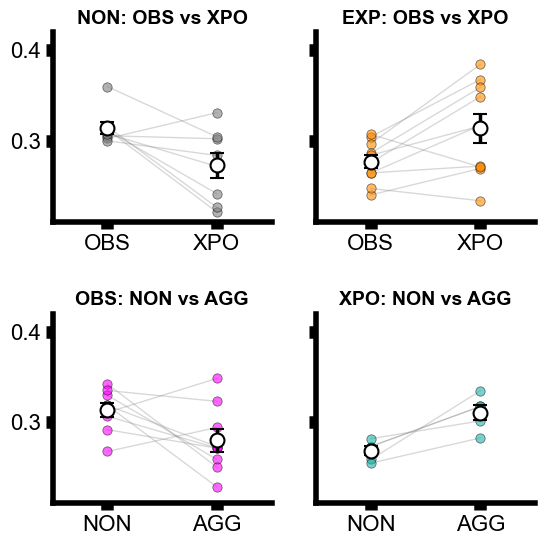

In [1390]:
from scipy.spatial.distance import jensenshannon
from scipy.stats import shapiro, ttest_rel, wilcoxon
from statsmodels.stats.multitest import multipletests

agg_HF_occupancies = agg_cluster_occupancies[:, -3:, :]
obs_HF_occupancies = obs_cluster_occupancies[:, -3:, :]
non_HF_occupancies = non_cluster_occupancies[:, -3:, :]
xpo_HF_occupancies = xpo_cluster_occupancies[:, :3, :]

CATEGORY_INDICES = {
    'conflict':      [0, 1, 2, 3],
    'investigative': [4, 6, 7, 8],
    'asocial':       [5, 9, 10, 11, 12],
}

def compute_js_dists_stratified(occupancies_list, category_indices, n_sessions=3):
    all_occ = np.concatenate(occupancies_list, axis=-1)
    n_animals = all_occ.shape[-1]
    per_category_dists = {}
    for cat_name, idx in category_indices.items():
        sub_occ = all_occ[idx, :, :]
        dists = np.full((n_sessions, n_sessions, n_animals, n_animals), np.nan)
        for a1 in range(n_animals):
            for s1 in range(n_sessions):
                for a2 in range(n_animals):
                    if a2 == a1:
                        continue
                    for s2 in range(n_sessions):
                        v1_raw, v2_raw = sub_occ[:, s1, a1], sub_occ[:, s2, a2]
                        denom1, denom2 = np.nansum(v1_raw), np.nansum(v2_raw)
                        if denom1 == 0 or denom2 == 0:
                            continue
                        dists[s1, s2, a1, a2] = jensenshannon(v1_raw/denom1, v2_raw/denom2)
        per_category_dists[cat_name] = dists
    stacked = np.stack(list(per_category_dists.values()), axis=0)
    return np.nanmean(stacked, axis=0), per_category_dists, n_animals

def per_animal_avg_dist(dists, query_idx, ref_idx):
    sub = dists[:, :, query_idx[:, None], ref_idx[None, :]]
    return np.nanmedian(sub, axis=(0, 1, 3))


# ── Distance matrices ──────────────────────────────────────────────────────────
n_agg = agg_HF_occupancies.shape[-1]
n_obs = obs_HF_occupancies.shape[-1]
n_non = non_HF_occupancies.shape[-1]
n_xpo = xpo_HF_occupancies.shape[-1]

dists_obs, _, _ = compute_js_dists_stratified(
    [agg_HF_occupancies, obs_HF_occupancies, non_HF_occupancies], CATEGORY_INDICES)
dists_xpo, _, _ = compute_js_dists_stratified(
    [agg_HF_occupancies, xpo_HF_occupancies, non_HF_occupancies], CATEGORY_INDICES)

agg_idx     = np.arange(n_agg)
obs_idx     = np.arange(n_agg, n_agg + n_obs)
non_idx     = np.arange(n_agg + n_obs, n_agg + n_obs + n_non)
xpo_idx     = np.arange(n_agg, n_agg + n_xpo)
non_idx_xpo = np.arange(n_agg + n_xpo, n_agg + n_xpo + n_non)

non_obs_animal = per_animal_avg_dist(dists_obs, non_idx, obs_idx)
non_xpo_animal = per_animal_avg_dist(dists_xpo, non_idx_xpo, xpo_idx)
agg_obs_animal = per_animal_avg_dist(dists_obs, agg_idx, obs_idx)
agg_xpo_animal = per_animal_avg_dist(dists_xpo, agg_idx, xpo_idx)
obs_non_animal = per_animal_avg_dist(dists_obs, obs_idx, non_idx)
obs_agg_animal = per_animal_avg_dist(dists_obs, obs_idx, agg_idx)
xpo_non_animal = per_animal_avg_dist(dists_xpo, xpo_idx, non_idx_xpo)
xpo_agg_animal = per_animal_avg_dist(dists_xpo, xpo_idx, agg_idx)


def compute_df_for_test(test_name, n):
    return n - 1 if test_name == 'paired t-test' else np.nan

def paired_test(a, b, alternative='two-sided', alpha=0.05):
    mask = ~np.isnan(a) & ~np.isnan(b)
    a_clean, b_clean = a[mask], b[mask]
    n = len(a_clean)
    if n < 3:
        return {'test': 'n/a', 'stat': np.nan, 'df': np.nan, 'p': np.nan,
                'n': n, 'a': a_clean, 'b': b_clean, 'alternative': alternative}
    diffs = a_clean - b_clean
    _, p_diff = shapiro(diffs)
    if p_diff > alpha:
        stat, p = ttest_rel(a_clean, b_clean, alternative=alternative)
        test = 'paired t-test'
    else:
        try:
            stat, p = wilcoxon(a_clean, b_clean, alternative=alternative)
        except ValueError:
            stat, p = np.nan, np.nan
        test = 'Wilcoxon signed-rank'
    return {'test': test, 'stat': stat, 'df': compute_df_for_test(test, n), 'p': p,
            'n': n, 'a': a_clean, 'b': b_clean, 'alternative': alternative}


comparisons = [
    ('NON: OBS vs XPO', non_obs_animal, non_xpo_animal, 'magenta', 'lightseagreen', ['OBS', 'XPO'], 'greater', 'gray'),
    ('EXP: OBS vs XPO', agg_obs_animal, agg_xpo_animal, 'magenta', 'lightseagreen', ['OBS', 'XPO'], 'less',    'darkorange'),
    ('OBS: NON vs AGG', obs_non_animal, obs_agg_animal, 'gray',    'darkorange',    ['NON', 'AGG'], 'greater', 'magenta'),
    ('XPO: NON vs AGG', xpo_non_animal, xpo_agg_animal, 'gray',    'darkorange',    ['NON', 'AGG'], 'less',    'lightseagreen'),
]

results = []
raw_p = []
for label, a, b, c1, c2, xlabels, alt, dot_color in comparisons:
    r = paired_test(a, b, alternative=alt)
    r.update({'label': label, 'c1': c1, 'c2': c2, 'xlabels': xlabels, 'dot_color': dot_color})
    results.append(r)
    raw_p.append(r['p'])

_, p_fdr, _, _ = multipletests(raw_p, method='fdr_bh')
for r, p_c in zip(results, p_fdr):
    r['p_fdr'] = p_c

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'\n{"="*105}')
print(f'Stratified, per-animal occupancy JS distance — one-sided paired tests per '
      f'pre-specified hypothesis')
print(f'{"="*105}')
print(f'{"Comparison":<20} {"Alt":<10} {"Test":<24} {"Stat":>9} {"df":>7} '
      f'{"p_fdr":>10} {"Sig":>5} {"n":>4}')
print(f'{"─"*105}')
for r in results:
    stat_s = f'{r["stat"]:.4f}' if not np.isnan(r['stat']) else 'n/a'
    df_s   = f'{r["df"]:.1f}'   if not np.isnan(r['df'])   else 'n/a'
    sig_s  = get_sig(r['p_fdr']) or 'ns'
    print(f'{r["label"]:<20} {r["alternative"]:<10} {r["test"]:<24} {stat_s:>9} {df_s:>7} '
          f'{r["p_fdr"]:>10.4e} {sig_s:>5} {r["n"]:>4}')
print(f'{"="*105}')

# ── 2×2 mean ± SEM plots ───────────────────────────────────────────────────────
from scipy.stats import sem

fig, axes = plt.subplots(2, 2, figsize=(6, 6), sharey=True)
axes = axes.flatten()

for idx, r in enumerate(results):
    ax = axes[idx]
    a, b, c1, c2, dot_color = r['a'], r['b'], r['c1'], r['c2'], r['dot_color']
    positions = [1, 2]

    for i in range(r['n']):
        ax.plot(positions, [a[i], b[i]], color='gray', alpha=0.3, linewidth=1, zorder=1)
    for j, data in enumerate([a, b]):
        ax.scatter(np.full(len(data), positions[j]), data,
                   color=dot_color, edgecolor='black', linewidths=0.5,
                   s=45, alpha=0.6, zorder=3)

    for j, (data, c) in enumerate(zip([a, b], [c1, c2])):
        mean_val = np.mean(data)
        sem_val  = sem(data)
        ax.errorbar(positions[j], mean_val, yerr=sem_val,
                   fmt='o', color='white', ecolor='black', markeredgecolor='black', markersize=10,
                   markeredgewidth=1.5, elinewidth=2.5, capsize=5, capthick=2.5,
                   zorder=5)

    ax.set_xlim(0.5, 2.5)
    ax.set_xticks(positions)
    ax.set_xticklabels(r['xlabels'], fontfamily='Arial')
    ax.set_title(r['label'], fontsize=14, fontfamily='Arial', fontweight='bold')
    ax.set_ylim(bottom=0.2, top=0.45)
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontfamily('Arial'); tick.set_fontsize(16)
    for spine in ax.spines.values():
        spine.set_linewidth(4)
    ax.tick_params(length=5, width=9)
    ax.set_ylim(bottom=0.21, top=0.42)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('.\\figures\\fig1_JS_divergence_stratified_animal_mean_sem.svg',
            dpi=300, bbox_inches='tight')
plt.show()

# ── Source data export: 1q ────────────────────────────────────────────────────
os.makedirs('./sourceData', exist_ok=True)

rows = []
for r in results:
    xlabel_a, xlabel_b = r['xlabels']
    for v in r['a']:
        rows.append({
            'comparison': r['label'], 'series': xlabel_a, 'js_distance': v,
            'alternative': r['alternative'], 'test': r['test'], 'stat': r['stat'],
            'df': r['df'], 'p_fdr': r['p_fdr'], 'n': r['n'],
        })
    for v in r['b']:
        rows.append({
            'comparison': r['label'], 'series': xlabel_b, 'js_distance': v,
            'alternative': r['alternative'], 'test': r['test'], 'stat': r['stat'],
            'df': r['df'], 'p_fdr': r['p_fdr'], 'n': r['n'],
        })

sourceData_1q = pd.DataFrame(rows)
sourceData_1q.to_csv('./sourceData/1q.csv', index=False)

In [1016]:
# ── Source data export: 1q ────────────────────────────────────────────────────
os.makedirs('./sourceData', exist_ok=True)

rows = []
for idx, (label, d1, d2, c1, c2, title) in enumerate(pair_comparisons):
    clean_label = label.replace('\n', ' ')
    for v in d1:
        rows.append({
            'comparison': clean_label, 'group': title.split()[0] if ':' not in title else title,
            'distribution': 'A', 'js_distance': v,
        })
    for v in d2:
        rows.append({
            'comparison': clean_label, 'group': title.split()[0] if ':' not in title else title,
            'distribution': 'B', 'js_distance': v,
        })

sourceData_1q = pd.DataFrame(rows)

stats_lookup = {
    pair_comparisons[i][0].replace('\n', ' '): (raw_ks[i], raw_p[i], p_fdr[i], ns[i][0], ns[i][1])
    for i in range(len(pair_comparisons))
}
sourceData_1q['ks_stat'] = sourceData_1q['comparison'].map(lambda c: stats_lookup[c][0])
sourceData_1q['p_raw']   = sourceData_1q['comparison'].map(lambda c: stats_lookup[c][1])
sourceData_1q['p_fdr']   = sourceData_1q['comparison'].map(lambda c: stats_lookup[c][2])
sourceData_1q['n1']      = sourceData_1q['comparison'].map(lambda c: stats_lookup[c][3])
sourceData_1q['n2']      = sourceData_1q['comparison'].map(lambda c: stats_lookup[c][4])

sourceData_1q.to_csv('./sourceData/1q.csv', index=False)

### Mapping transitions

In [1073]:
# Smoothed matrix tested against null distributions; generated from matrix_generation.npy; see that notebook for more information
smoothed_matrix = np.load('average_smoothed_transition_m_090225.npy')

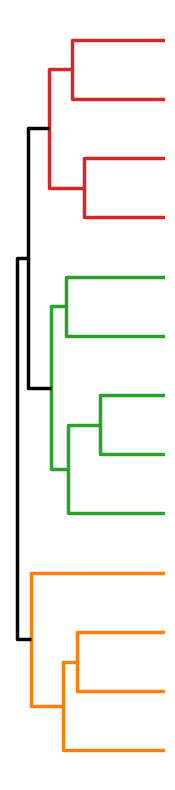

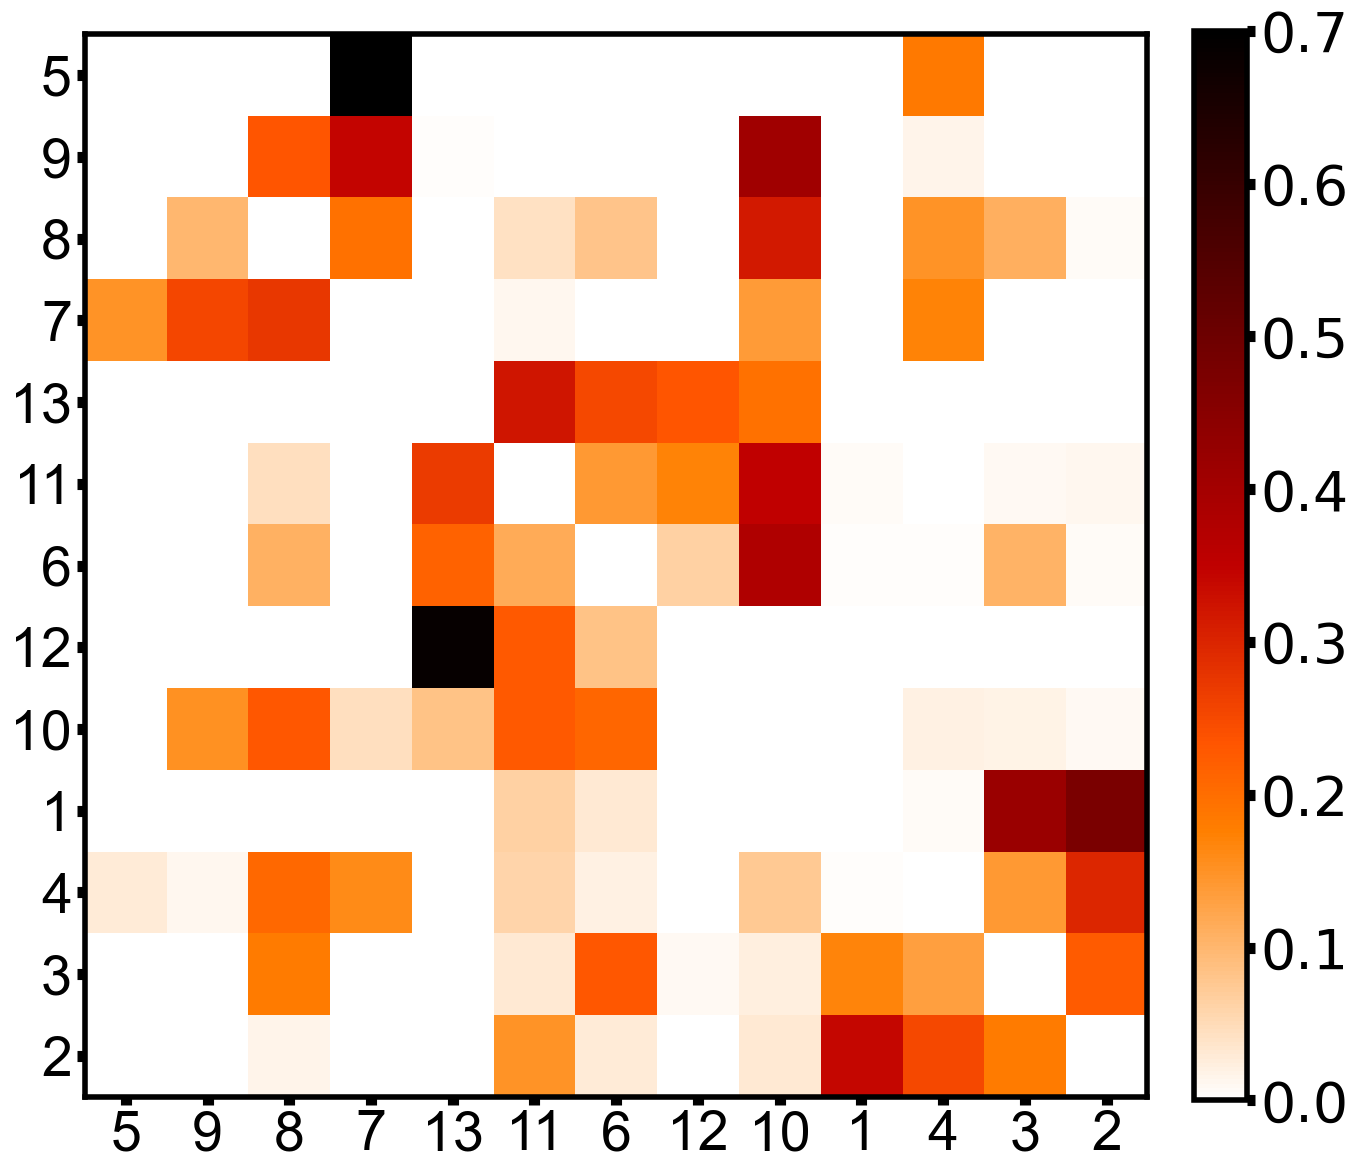

In [1074]:
# Quantify "real" transitions from Dexter's analysis

# build dendrogram
from scipy.cluster.hierarchy import dendrogram, linkage
Z = linkage(smoothed_matrix, metric='jensenshannon', method='complete', optimal_ordering=True)
plt.figure(figsize=(2, 10))
dendro_dict = dendrogram(Z, color_threshold=0.76, above_threshold_color='black', orientation='left')
leaf_indices = dendro_dict['leaves']
# plt.xticks(np.linspace(5, 125, 13), np.array(leaf_indices)+1)
sns.despine(left=True, bottom=True)
plt.yticks([])
plt.xticks([])
# plt.savefig('.\\figures\\fig1\\dendrogram.svg', dpi=600)

# build matrix with hierarchical clustering
plt.figure(figsize=(15, 15))
plt.imshow(smoothed_matrix[leaf_indices, :][:, leaf_indices], vmin=0, vmax=0.7, cmap='gist_heat_r')
plt.xticks(np.arange(n_clusters), np.arange(1,n_clusters+1)[leaf_indices])
plt.yticks(np.arange(n_clusters), np.arange(1,n_clusters+1)[leaf_indices])
plt.xticks(fontsize=40, fontname='Arial')
plt.yticks(fontsize=40, fontname='Arial')
# plt.ylabel('From')
# plt.xlabel('To')
cbar = plt.colorbar(fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=40)
# plt.savefig('.\\figures\\fig1\\transition_matrix_full.svg', dpi=600, bbox_inches='tight')

# save source data for figure
ordered_labels = (np.arange(1, n_clusters + 1))[leaf_indices]
sourceData_1m = pd.DataFrame(
    smoothed_matrix[leaf_indices, :][:, leaf_indices],
    index=ordered_labels, columns=ordered_labels
)
sourceData_1m.index.name = 'from_cluster'
sourceData_1m.columns.name = 'to_cluster'
sourceData_1m.to_csv('./sourceData/1m.csv')

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_45872\4068942926.py:153: RuntimeWarning: invalid value encountered in divide
  normalized_transition_matrices = transition_matrices / row_sums



Family transitions — omnibus (ANOVA/Welch ANOVA/Kruskal-Wallis) → posthoc (t-test/Welch t-test/Brunner-Munzel)
Metric: bounded [0,1] family transition weight
FDR-BH applied WITHIN each origin ("from") family (3 destinations × 3 comparisons = up to 9 tests/family)
From           To             Omnibus         Omni_stat     Omni_p Comparison   Posthoc                 PH_stat       df      p_fdr
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Aggressive     Aggressive     ANOVA              7.2239     0.0035 EXP vs OBS   t-test                   1.7357     17.0     0.0604
Aggressive     Aggressive     ANOVA              7.2239     0.0035 EXP vs NON   t-test                   3.6065     16.0     0.0059
Aggressive     Aggressive     ANOVA              7.2239     0.0035 OBS vs NON   t-test                   2.2106     15.0     0.0323
──────────────────────────────────────────────

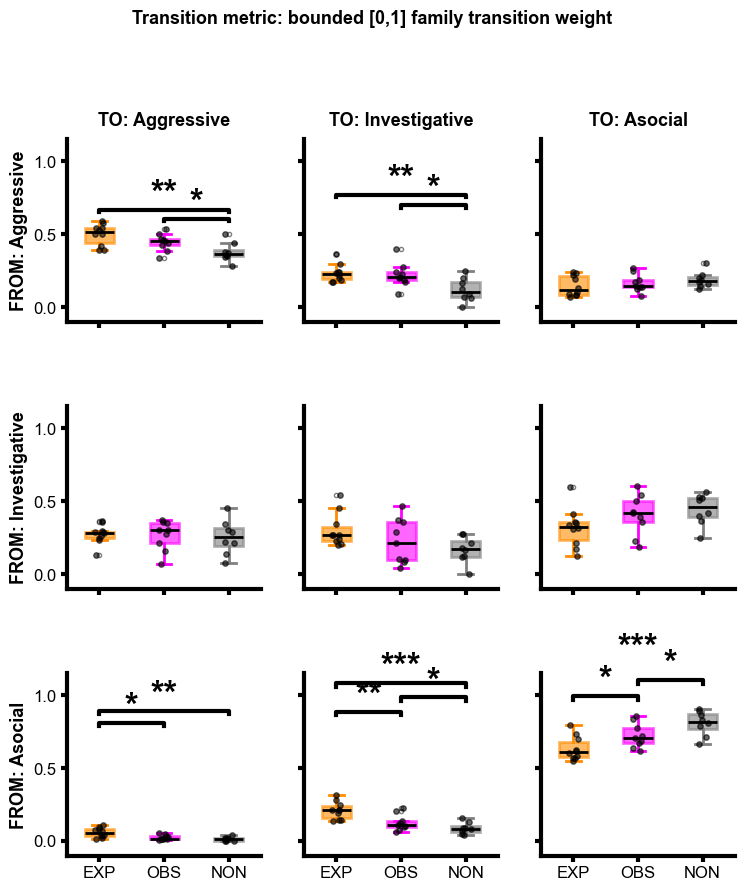

In [1082]:
# Framework for computing transitions

from scipy.stats import brunnermunzel
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm

def format_p(p):
    return f'{p:.3e}' if p < 1e-4 else f'{p:.4f}'

def run_comprehensive_stats(data2plot, alpha=0.05, variance_alpha=0.05, verbose=True):
    """
    1) Normality (Shapiro, per group)
    2) Variance (Levene always; Bartlett if normal)
    3) Omnibus: ANOVA (normal+equal var) / Welch ANOVA (normal+unequal var) /
       Kruskal-Wallis (non-normal)
    4) Posthoc (only if omnibus p <= 0.05): t-test / Welch t-test / Brunner-Munzel
    Returns RAW pairwise p-values — FDR applied externally at the family level.
    """
    exp_d = data2plot[0][~np.isnan(data2plot[0])]
    obs_d = data2plot[1][~np.isnan(data2plot[1])]
    non_d = data2plot[2][~np.isnan(data2plot[2])]

    if len(exp_d) < 3 or len(obs_d) < 3 or len(non_d) < 3:
        if verbose: print("Insufficient data for statistical analysis")
        return None

    df = pd.DataFrame({
        'Activity': np.concatenate([exp_d, obs_d, non_d]),
        'Group': np.concatenate([['exp']*len(exp_d), ['obs']*len(obs_d), ['non']*len(non_d)]),
    })

    # ── 1. Normality ────────────────────────────────────────────────────────────
    _, p_exp_norm = stats.shapiro(exp_d)
    _, p_obs_norm = stats.shapiro(obs_d)
    _, p_non_norm = stats.shapiro(non_d)
    normality_passed = all(p > alpha for p in [p_exp_norm, p_obs_norm, p_non_norm])
    if verbose:
        print(f"Normality - EXP: p={format_p(p_exp_norm)}, OBS: p={format_p(p_obs_norm)}, NON: p={format_p(p_non_norm)}")

    # ── 2. Variance ───────────────────────────────────────────────────────────────
    levene_stat, levene_p = stats.levene(exp_d, obs_d, non_d)
    equal_variances = levene_p > variance_alpha
    if verbose:
        print(f"Levene's test: F={levene_stat:.4f}, p={format_p(levene_p)}")
    if normality_passed:
        bartlett_stat, bartlett_p = stats.bartlett(exp_d, obs_d, non_d)
        if verbose:
            print(f"Bartlett's test: χ²={bartlett_stat:.4f}, p={format_p(bartlett_p)}")
        equal_variances = equal_variances and (bartlett_p > variance_alpha)

    results = {'normality_passed': normality_passed, 'equal_variances': equal_variances,
              'levene_p': levene_p}

    # ── 3. Omnibus ────────────────────────────────────────────────────────────────
    if normality_passed and equal_variances:
        if verbose: print("Using parametric tests (normal, equal variances)")
        model = sm.OLS.from_formula('Activity ~ C(Group)', data=df).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        f_stat, anova_p = anova_table['F'][0], anova_table['PR(>F)'][0]
        if verbose: print(f"One-way ANOVA: F={f_stat:.4f}, p={format_p(anova_p)}")
        results.update({'omnibus_test': 'ANOVA', 'omnibus_statistic': f_stat, 'omnibus_p': anova_p})

        if anova_p <= 0.05:
            t1, p_en = stats.ttest_ind(exp_d, non_d, equal_var=True)
            t2, p_on = stats.ttest_ind(obs_d, non_d, equal_var=True)
            t3, p_eo = stats.ttest_ind(exp_d, obs_d, equal_var=True)
            results.update({
                'pairwise_test': 't-test',
                'agg_vs_non': {'statistic': t1, 'p_raw': p_en},
                'agg_vs_obs': {'statistic': t3, 'p_raw': p_eo},
                'obs_vs_non': {'statistic': t2, 'p_raw': p_on},
            })

    elif normality_passed and not equal_variances:
        if verbose: print("Using Welch's tests (normal, unequal variances)")
        try:
            welch_stat, welch_p = stats.f_oneway(exp_d, obs_d, non_d)
            if verbose: print(f"Welch's ANOVA: F={welch_stat:.4f}, p={format_p(welch_p)}")
            results.update({'omnibus_test': 'Welch ANOVA', 'omnibus_statistic': welch_stat, 'omnibus_p': welch_p})

            if welch_p <= 0.05:
                t1, p_en = stats.ttest_ind(exp_d, non_d, equal_var=False)
                t2, p_on = stats.ttest_ind(obs_d, non_d, equal_var=False)
                t3, p_eo = stats.ttest_ind(exp_d, obs_d, equal_var=False)
                results.update({
                    'pairwise_test': 'Welch t-test',
                    'agg_vs_non': {'statistic': t1, 'p_raw': p_en},
                    'agg_vs_obs': {'statistic': t3, 'p_raw': p_eo},
                    'obs_vs_non': {'statistic': t2, 'p_raw': p_on},
                })
        except Exception:
            if verbose: print("Welch's ANOVA failed — falling back to non-parametric")
            normality_passed = False

    if not normality_passed:
        if verbose: print("Using non-parametric tests (normality not assumed)")
        kruskal_stat, kruskal_p = stats.kruskal(exp_d, obs_d, non_d)
        if verbose: print(f"Kruskal-Wallis: H={kruskal_stat:.4f}, p={format_p(kruskal_p)}")
        results.update({'omnibus_test': 'Kruskal-Wallis', 'omnibus_statistic': kruskal_stat, 'omnibus_p': kruskal_p})

        if kruskal_p <= 0.05:
            u1, p_en = brunnermunzel(exp_d, non_d, alternative='two-sided')
            u2, p_on = brunnermunzel(obs_d, non_d, alternative='two-sided')
            u3, p_eo = brunnermunzel(exp_d, obs_d, alternative='two-sided')
            results.update({
                'pairwise_test': 'Brunner-Munzel',
                'agg_vs_non': {'statistic': u1, 'p_raw': p_en},
                'agg_vs_obs': {'statistic': u3, 'p_raw': p_eo},
                'obs_vs_non': {'statistic': u2, 'p_raw': p_on},
            })

    if verbose: print('###')
    return results

def compute_df_for_test(pairwise_test, a, b):
    if pairwise_test == 't-test':
        return len(a) + len(b) - 2
    elif pairwise_test == 'Welch t-test':
        v1, v2 = np.var(a, ddof=1), np.var(b, ddof=1)
        n1, n2 = len(a), len(b)
        return (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
    else:
        return np.nan

# ══════════════════════════════════════════════════════════════════════════
# Transitions — raw-count extraction (unchanged)
# ══════════════════════════════════════════════════════════════════════════

def map_cluster_transitions(animals, full_data, clusters, beh='agg'):
    if beh == 'agg' or beh == 'obs':
        transition_matrices = np.zeros((len(clusters), len(clusters), 27, len(animals)))
    else:
        transition_matrices = np.zeros((len(clusters), len(clusters), 3, len(animals)))

    for a, animal in enumerate(animals):
        sessions2map = list(unsupervised_data_full.keys())
        if beh == 'agg':
            sessions2map = [x for x in sessions2map if animal in x if 'balbc' in x or '_mCD1_' in x]
        elif beh == 'obs':
            sessions2map = [x for x in sessions2map if animal in x if 'obs' in x or '_OBSmCD1_' in x]
        elif beh == 'non':
            sessions2map = [x for x in sessions2map if animal in x if 'toyCD1' in x]
        else:
            sessions2map = [x for x in sessions2map if animal in x if 'xpoCD1' in x]

        for s, session in enumerate(sessions2map):
            vec = full_data[session]['unsupervised labels'].values.astype(int)
            for i in np.arange(len(vec) - 1):
                if vec[i] != vec[i+1]:
                    transition_matrices[vec[i]-1][vec[i+1]-1, s, a] += 1

    row_sums = np.nansum(transition_matrices, axis=1, keepdims=True)
    normalized_transition_matrices = transition_matrices / row_sums

    return transition_matrices, normalized_transition_matrices

agg_transitions, agg_norm_transitions = map_cluster_transitions(agg_animals, full_data, clusters, beh='agg')
obs_transitions, obs_norm_transitions = map_cluster_transitions(obs_animals, full_data, clusters, beh='obs')
non_transitions, non_norm_transitions = map_cluster_transitions(non_animals, full_data, clusters, beh='non')
xpo_animals = ['4321L_', '4321R2', '4321L2', '7452R', '7452L2']
xpo_transitions, xpo_norm_transitions = map_cluster_transitions(xpo_animals, full_data, clusters, beh='xpo')

indices = np.arange(13)
agg_transitions_2_map = agg_transitions[np.ix_(indices, indices, np.arange(-3, 0), np.arange(agg_transitions.shape[3]))]
obs_transitions_2_map = obs_transitions[np.ix_(indices, indices, np.arange(-3, 0), np.arange(obs_transitions.shape[3]))]
non_transitions_2_map = non_transitions[np.ix_(indices, indices, np.arange(non_transitions.shape[2]), np.arange(non_transitions.shape[3]))]
xpo_transitions_2_map = xpo_transitions[np.ix_(indices, indices, np.arange(xpo_transitions.shape[2]), np.arange(xpo_transitions.shape[3]))]

agg_transitions_2_map = np.nan_to_num(agg_transitions_2_map, nan=0.0)
obs_transitions_2_map = np.nan_to_num(obs_transitions_2_map, nan=0.0)
non_transitions_2_map = np.nan_to_num(non_transitions_2_map, nan=0.0)
xpo_transitions_2_map = np.nan_to_num(xpo_transitions_2_map, nan=0.0)

def compute_family_transition_weight(raw_transitions, fi, ti, normalize=True):
    numer = np.nansum(raw_transitions[np.ix_(fi, ti)], axis=(0, 1))

    if normalize:
        denom = np.nansum(raw_transitions[fi, :, :, :], axis=(0, 1))
        with np.errstate(invalid='ignore', divide='ignore'):
            metric = numer / denom
        metric = np.where(denom == 0, np.nan, metric)
    else:
        metric = numer

    per_animal = np.nanmedian(metric, axis=0)
    return per_animal[~np.isnan(per_animal)]

# ══════════════════════════════════════════════════════════════════════════
# Stats + plotting — now via run_comprehensive_stats (omnibus → posthoc)
# ══════════════════════════════════════════════════════════════════════════

USE_NORMALIZED = True

categories = {
    'Aggressive':    [1, 2, 3],
    'Investigative': [4, 6, 7],
    'Asocial':       [5, 9, 10, 12],
}
cat_names    = list(categories.keys())
colors       = ['darkorange', 'magenta', 'gray']
group_labels = ['EXP', 'OBS', 'NON']
positions    = [1, 2, 3]

cell_data_cache     = {}
raw_p_all           = {}
omnibus_all         = {}
posthoc_detail_all  = {}

for from_cat in cat_names:
    fi = categories[from_cat]
    for to_cat in cat_names:
        ti = categories[to_cat]

        agg_data = compute_family_transition_weight(agg_transitions_2_map, fi, ti, normalize=USE_NORMALIZED)
        obs_data = compute_family_transition_weight(obs_transitions_2_map, fi, ti, normalize=USE_NORMALIZED)
        non_data = compute_family_transition_weight(non_transitions_2_map, fi, ti, normalize=USE_NORMALIZED)

        cell_data_cache[(from_cat, to_cat)] = (agg_data, obs_data, non_data)

        stat_result = run_comprehensive_stats([agg_data, obs_data, non_data], verbose=False)

        omnibus_all[(from_cat, to_cat)] = {
            'omnibus_test':      stat_result['omnibus_test']      if stat_result else 'n/a',
            'omnibus_statistic': stat_result['omnibus_statistic'] if stat_result else np.nan,
            'omnibus_p':         stat_result['omnibus_p']         if stat_result else np.nan,
        }

        pair_data_lookup = {
            'agg_vs_obs': (agg_data, obs_data),
            'agg_vs_non': (agg_data, non_data),
            'obs_vs_non': (obs_data, non_data),
        }

        raw_p_all[(from_cat, to_cat)]          = {}
        posthoc_detail_all[(from_cat, to_cat)] = {}

        for comp in ['agg_vs_obs', 'agg_vs_non', 'obs_vs_non']:
            if stat_result is not None and comp in stat_result:
                raw_p_all[(from_cat, to_cat)][comp] = stat_result[comp]['p_raw']
                pairwise_test = stat_result.get('pairwise_test', 'n/a')
                a, b = pair_data_lookup[comp]
                posthoc_detail_all[(from_cat, to_cat)][comp] = {
                    'test':      pairwise_test,
                    'statistic': stat_result[comp]['statistic'],
                    'df':        compute_df_for_test(pairwise_test, a, b),
                }
            else:
                raw_p_all[(from_cat, to_cat)][comp] = np.nan
                posthoc_detail_all[(from_cat, to_cat)][comp] = {
                    'test': 'n/a (omnibus n.s.)', 'statistic': np.nan, 'df': np.nan,
                }

# ── FDR correction: pooled across all posthoc comparisons within each origin family ──
cell_stats = {(f, t): {} for f in cat_names for t in cat_names}

for from_cat in cat_names:
    keys, pvals = [], []
    for to_cat in cat_names:
        for comp in ['agg_vs_obs', 'agg_vs_non', 'obs_vs_non']:
            keys.append((to_cat, comp))
            pvals.append(raw_p_all[(from_cat, to_cat)][comp])

    valid = [i for i, p in enumerate(pvals) if not np.isnan(p)]
    corr_full = np.full(len(pvals), np.nan)
    if valid:
        _, corr, _, _ = multipletests([pvals[i] for i in valid], method='fdr_tsbh')
        for rank, i in enumerate(valid):
            corr_full[i] = corr[rank]

    for (to_cat, comp), p_raw, p_corr in zip(keys, pvals, corr_full):
        cell_stats[(from_cat, to_cat)][comp] = {'p_raw': p_raw, 'p_corrected': p_corr}

# ── Full stats table ───────────────────────────────────────────────────────────
comp_display = {'agg_vs_obs': 'EXP vs OBS', 'agg_vs_non': 'EXP vs NON', 'obs_vs_non': 'OBS vs NON'}
metric_label = 'bounded [0,1] family transition weight' if USE_NORMALIZED else 'raw transition count'

print(f'\n{"="*160}')
print(f'Family transitions — omnibus (ANOVA/Welch ANOVA/Kruskal-Wallis) → posthoc '
      f'(t-test/Welch t-test/Brunner-Munzel)')
print(f'Metric: {metric_label}')
print(f'FDR-BH applied WITHIN each origin ("from") family '
      f'({len(cat_names)} destinations × 3 comparisons = up to {len(cat_names)*3} tests/family)')
print(f'{"="*160}')
print(f'{"From":<14} {"To":<14} '
      f'{"Omnibus":<14} {"Omni_stat":>10} {"Omni_p":>10} '
      f'{"Comparison":<12} {"Posthoc":<20} {"PH_stat":>10} {"df":>8} '
      f'{"p_fdr":>10}')
print(f'{"─"*160}')

for from_cat in cat_names:
    for to_cat in cat_names:
        omni_t    = omnibus_all[(from_cat, to_cat)]['omnibus_test']
        omni_stat = omnibus_all[(from_cat, to_cat)]['omnibus_statistic']
        omni_p    = omnibus_all[(from_cat, to_cat)]['omnibus_p']
        omni_stat_str = f'{omni_stat:.4f}' if not np.isnan(omni_stat) else 'n/a'
        omni_p_str    = format_p(omni_p)   if not np.isnan(omni_p)   else 'n/a'

        for comp in ['agg_vs_obs', 'agg_vs_non', 'obs_vs_non']:
            detail = posthoc_detail_all[(from_cat, to_cat)][comp]
            p_raw  = cell_stats[(from_cat, to_cat)][comp]['p_raw']
            p_corr = cell_stats[(from_cat, to_cat)][comp]['p_corrected']

            ph_test = detail['test']
            ph_stat = detail['statistic']
            ph_df   = detail['df']

            ph_stat_str = f'{ph_stat:.4f}' if not np.isnan(ph_stat) else 'n/a'
            ph_df_str   = f'{ph_df:.1f}'   if not np.isnan(ph_df)   else 'n/a'
            p_raw_str   = format_p(p_raw)  if not np.isnan(p_raw)  else 'n/a'
            p_corr_str  = format_p(p_corr) if not np.isnan(p_corr) else 'n/a'

            print(f'{from_cat:<14} {to_cat:<14} '
                  f'{omni_t:<14} {omni_stat_str:>10} {omni_p_str:>10} '
                  f'{comp_display[comp]:<12} {ph_test:<20} {ph_stat_str:>10} {ph_df_str:>8} '
                  f'{p_corr_str:>10}')

        print(f'{"─"*160}')

print(f'{"="*160}')

# Shared global max for bracket placement
all_vals = []
for from_cat in cat_names:
    for to_cat in cat_names:
        for arr in cell_data_cache[(from_cat, to_cat)]:
            all_vals.extend(arr.tolist())
global_max_y = np.max(all_vals) if all_vals else 1.0

# ── 3x3 figure ────────────────────────────────────────────────────────────────
plt.close()
fig, axes = plt.subplots(3, 3, figsize=(8, 9), sharey=True, sharex=True)

for row_idx, from_cat in enumerate(cat_names):
    for col_idx, to_cat in enumerate(cat_names):
        ax = axes[row_idx, col_idx]

        agg_data, obs_data, non_data = cell_data_cache[(from_cat, to_cat)]
        stats_results = cell_stats[(from_cat, to_cat)]

        data_to_plot = [agg_data, obs_data, non_data]

        box = ax.boxplot(data_to_plot, positions=positions, patch_artist=True, widths=0.45,
                         medianprops=dict(color='black', linewidth=2),
                         whiskerprops=dict(linewidth=2), capprops=dict(linewidth=2),
                         flierprops=dict(marker='o', markersize=3, markeredgecolor='black', alpha=0.5))
        for patch, color in zip(box['boxes'], colors):
            patch.set_facecolor(color); patch.set_edgecolor(color)
            patch.set_alpha(0.6); patch.set_linewidth(2)
        for whisker, color in zip(box['whiskers'], [c for c in colors for _ in (0, 1)]):
            whisker.set_color(color)
        for cap, color in zip(box['caps'], [c for c in colors for _ in (0, 1)]):
            cap.set_color(color)

        for j, (data, color) in enumerate(zip(data_to_plot, colors)):
            jitter = np.random.default_rng(42 + j).uniform(-0.08, 0.08, size=len(data))
            ax.scatter(np.full(len(data), positions[j]) + jitter,
                       data, color='black', s=15, alpha=0.6, zorder=5)

        ax.autoscale()

        if USE_NORMALIZED:
            y_max = min(ax.get_ylim()[1], 1.05)
            center_height = y_max * 1.05
            add_significance_brackets(ax, positions, data_to_plot, stats_results,
                                       y_offset_factor=0.15, center_height=center_height)
            ax.set_ylim(-0.1, 1.15)
            ax.set_yticks([0, 0.5, 1.0])
        else:
            y_max = ax.get_ylim()[1]
            if y_max < 1: y_max = 1
            center_height = y_max * 1.1
            add_significance_brackets(ax, positions, data_to_plot, stats_results,
                                       y_offset_factor=0.15, center_height=center_height)
            ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

        ax.set_xticks(positions)
        ax.set_xticklabels(group_labels, fontsize=13, fontfamily='Arial')
        for tick in ax.get_xticklabels() + ax.get_yticklabels():
            tick.set_fontfamily('Arial'); tick.set_fontsize(12)
        for spine in ax.spines.values():
            spine.set_linewidth(3)
        ax.tick_params(axis='both', length=4, width=3)

        if col_idx == 0:
            ax.set_ylabel(f'FROM: {from_cat}', fontsize=13, fontfamily='Arial', fontweight='bold')
        if row_idx == 0:
            ax.set_title(f'TO: {to_cat}', fontsize=13, fontfamily='Arial', fontweight='bold', pad=10)

        sns.despine(ax=ax)

fig.suptitle(f'Transition metric: {metric_label}', fontsize=13,
             fontweight='bold', fontfamily='Arial', y=1.01)
plt.tight_layout()
plt.savefig('.\\figures\\fig1_transition_3x3_matrix.svg', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ── Source data export: 1o ──
os.makedirs('./sourceData', exist_ok=True)

comp_display = {'agg_vs_obs': 'EXP_vs_OBS', 'agg_vs_non': 'EXP_vs_NON', 'obs_vs_non': 'OBS_vs_NON'}

rows = []

for from_cat in cat_names:
    for to_cat in cat_names:
        agg_data, obs_data, non_data = cell_data_cache[(from_cat, to_cat)]

        omni_test = omnibus_all[(from_cat, to_cat)]['omnibus_test']
        omni_stat = omnibus_all[(from_cat, to_cat)]['omnibus_statistic']
        omni_p    = omnibus_all[(from_cat, to_cat)]['omnibus_p']

        group_data = {'EXP': agg_data, 'OBS': obs_data, 'NON': non_data}

        for group, vals in group_data.items():
            for v in vals:
                row = {
                    'from_category': from_cat,
                    'to_category': to_cat,
                    'group': group,
                    'transition_weight': v,
                    'omnibus_test': omni_test,
                    'omnibus_stat': omni_stat,
                    'omnibus_p': omni_p,
                }
                for comp in ['agg_vs_obs', 'agg_vs_non', 'obs_vs_non']:
                    detail = posthoc_detail_all[(from_cat, to_cat)][comp]
                    p_fdr  = cell_stats[(from_cat, to_cat)][comp]['p_corrected']
                    label  = comp_display[comp]
                    row[f'{label}_test']  = detail['test']
                    row[f'{label}_stat']  = detail['statistic']
                    row[f'{label}_df']    = detail['df']
                    row[f'{label}_p_fdr'] = p_fdr
                rows.append(row)

sourceData_1o = pd.DataFrame(rows)
sourceData_1o.to_csv('./sourceData/1o.csv', index=False)


Family transitions — OBS vs XPO
Normality -> variance -> t-test / Welch t-test / Brunner-Munzel (MWU fallback if degenerate)
Sidedness set per a priori hypothesis (see alternative_map); metric: bounded [0,1] family transition weight
FDR-BH applied WITHIN each origin ("from") family (3 destinations/family)
From           To             Alt        Test                               Stat       df      p_raw      p_fdr   Sig
─────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Aggressive     Aggressive     greater    t-test                           0.8798     12.0     0.1981     0.2972      
Aggressive     Investigative  greater    Welch t-test                     2.1958     10.4     0.0259     0.0778      
Aggressive     Asocial        two-sided  t-test                          -0.6180     12.0     0.5481     0.5481      
──────────────────────────────────────────────────────────────────────────

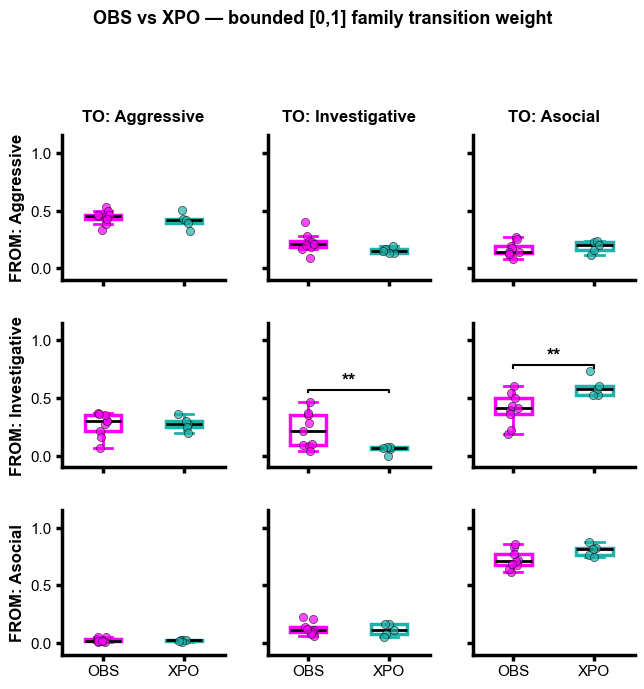

In [1084]:
# Framework for computing transitions — OBS vs XPO comparison

from scipy.stats import shapiro, levene, bartlett, ttest_ind, brunnermunzel, mannwhitneyu
from statsmodels.stats.multitest import multipletests

def format_p(p):
    if p is None or np.isnan(p): return 'n/a'
    return f'{p:.3e}' if p < 1e-4 else f'{p:.4f}'

def get_sig(p):
    if p is None or np.isnan(p): return ''
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''

def compute_df_for_test(test_name, a, b):
    if test_name == 't-test':
        return len(a) + len(b) - 2
    elif test_name == 'Welch t-test':
        v1, v2 = np.var(a, ddof=1), np.var(b, ddof=1)
        n1, n2 = len(a), len(b)
        return (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
    else:
        return np.nan

def run_pairwise_stats(a, b, alternative='two-sided', alpha=0.05, variance_alpha=0.05):
    """
    Two-group comparison, no omnibus:
    1) Normality (Shapiro, both groups)
    2) Variance (Levene always; Bartlett too if both normal)
    3) Test selection: t-test (normal+equal var) / Welch t-test
       (normal+unequal var) / Brunner-Munzel (non-normal), with fallback
       to Mann-Whitney U if Brunner-Munzel degenerates.
    alternative applies to whichever test is selected: 'greater' means a > b,
    'less' means a < b, matching a=obs_data, b=xpo_data throughout this cell.
    """
    if len(a) < 3 or len(b) < 3:
        return {'test': 'n/a', 'statistic': np.nan, 'df': np.nan, 'p_value': np.nan}

    _, p_norm_a = shapiro(a)
    _, p_norm_b = shapiro(b)
    normality_passed = (p_norm_a > alpha) and (p_norm_b > alpha)

    levene_stat, levene_p = levene(a, b)
    equal_variances = levene_p > variance_alpha
    if normality_passed:
        _, bartlett_p = bartlett(a, b)
        equal_variances = equal_variances and (bartlett_p > variance_alpha)

    if normality_passed and equal_variances:
        stat, p = ttest_ind(a, b, equal_var=True, alternative=alternative)
        test_name = 't-test'
    elif normality_passed and not equal_variances:
        stat, p = ttest_ind(a, b, equal_var=False, alternative=alternative)
        test_name = 'Welch t-test'
    else:
        stat, p = brunnermunzel(a, b, alternative=alternative)
        test_name = 'Brunner-Munzel'
        if not np.isfinite(stat) or not np.isfinite(p):
            stat, p = mannwhitneyu(a, b, alternative=alternative)
            test_name = 'Mann-Whitney U (BM degenerate — fallback)'

    df_val = compute_df_for_test(test_name, a, b)
    return {'test': test_name, 'statistic': stat, 'df': df_val, 'p_value': p}

def compute_family_transition_weight(raw_transitions, fi, ti, normalize=True):
    numer = np.nansum(raw_transitions[np.ix_(fi, ti)], axis=(0, 1))
    if normalize:
        denom = np.nansum(raw_transitions[fi, :, :, :], axis=(0, 1))
        with np.errstate(invalid='ignore', divide='ignore'):
            metric = numer / denom
        metric = np.where(denom == 0, np.nan, metric)
    else:
        metric = numer
    per_animal = np.nanmedian(metric, axis=0)
    return per_animal[~np.isnan(per_animal)]

# ══════════════════════════════════════════════════════════════════════════
USE_NORMALIZED = True

categories = {
    'Aggressive':    [1, 2, 3],
    'Investigative': [4, 6, 7],
    'Asocial':       [5, 9, 10, 12],
}
cat_names    = list(categories.keys())
colors_2grp  = ['magenta', 'lightseagreen']
group_labels_2grp = ['OBS', 'XPO']
positions_2grp     = [1, 2]

# ── A priori directional hypotheses, informed by the EXP/NON results ─────────
# alternative applies to (a=OBS, b=XPO): 'greater' = OBS > XPO,
# 'less' = OBS < XPO, 'two-sided' = no directional prediction.
alternative_map = {
    ('Aggressive',    'Aggressive'):    'greater',    # aggr -> aggr: OBS > XPO
    ('Aggressive',    'Investigative'): 'greater',    # aggr -> investg: OBS > XPO
    ('Aggressive',    'Asocial'):       'two-sided',  # aggr -> asocial
    ('Investigative', 'Aggressive'):    'two-sided',  # all investigative-origin: two-sided
    ('Investigative', 'Investigative'): 'two-sided',
    ('Investigative', 'Asocial'):       'two-sided',
    ('Asocial',        'Aggressive'):    'two-sided',  # asocial -> aggr
    ('Asocial',        'Investigative'): 'greater',    # asocial -> investg: OBS > XPO
    ('Asocial',        'Asocial'):       'less',       # asocial -> asocial: OBS < XPO
}

cell_data_cache_2grp = {}
raw_p_all_2grp       = {}
posthoc_detail_2grp  = {}

for from_cat in cat_names:
    fi = categories[from_cat]
    for to_cat in cat_names:
        ti = categories[to_cat]

        obs_data = compute_family_transition_weight(obs_transitions_2_map, fi, ti, normalize=USE_NORMALIZED)
        xpo_data = compute_family_transition_weight(xpo_transitions_2_map, fi, ti, normalize=USE_NORMALIZED)

        cell_data_cache_2grp[(from_cat, to_cat)] = (obs_data, xpo_data)

        alt = alternative_map[(from_cat, to_cat)]
        result = run_pairwise_stats(obs_data, xpo_data, alternative=alt)
        result['alternative'] = alt

        raw_p_all_2grp[(from_cat, to_cat)] = result['p_value']
        posthoc_detail_2grp[(from_cat, to_cat)] = result

# ── FDR correction: pooled across all comparisons within each origin family ──
cell_stats_2grp = {}

for from_cat in cat_names:
    keys, pvals = [], []
    for to_cat in cat_names:
        keys.append(to_cat)
        pvals.append(raw_p_all_2grp[(from_cat, to_cat)])

    valid = [i for i, p in enumerate(pvals) if not np.isnan(p)]
    corr_full = np.full(len(pvals), np.nan)
    if valid:
        _, corr, _, _ = multipletests([pvals[i] for i in valid], method='fdr_tsbh')
        for rank, i in enumerate(valid):
            corr_full[i] = corr[rank]

    for to_cat, p_raw, p_corr in zip(keys, pvals, corr_full):
        cell_stats_2grp[(from_cat, to_cat)] = {'p_raw': p_raw, 'p_corrected': p_corr}

# ── Full stats table ───────────────────────────────────────────────────────────
metric_label = 'bounded [0,1] family transition weight' if USE_NORMALIZED else 'raw transition count'

print(f'\n{"="*145}')
print(f'Family transitions — OBS vs XPO')
print(f'Normality -> variance -> t-test / Welch t-test / Brunner-Munzel (MWU fallback if degenerate)')
print(f'Sidedness set per a priori hypothesis (see alternative_map); metric: {metric_label}')
print(f'FDR-BH applied WITHIN each origin ("from") family ({len(cat_names)} destinations/family)')
print(f'{"="*145}')
print(f'{"From":<14} {"To":<14} {"Alt":<10} {"Test":<28} {"Stat":>10} {"df":>8} {"p_raw":>10} {"p_fdr":>10} {"Sig":>5}')
print(f'{"─"*145}')

for from_cat in cat_names:
    for to_cat in cat_names:
        detail  = posthoc_detail_2grp[(from_cat, to_cat)]
        p_raw   = cell_stats_2grp[(from_cat, to_cat)]['p_raw']
        p_corr  = cell_stats_2grp[(from_cat, to_cat)]['p_corrected']

        stat_str = f'{detail["statistic"]:.4f}' if not np.isnan(detail['statistic']) else 'n/a'
        df_str   = f'{detail["df"]:.1f}'        if not np.isnan(detail['df'])        else 'n/a'

        print(f'{from_cat:<14} {to_cat:<14} {detail["alternative"]:<10} {detail["test"]:<28} {stat_str:>10} {df_str:>8} '
              f'{format_p(p_raw):>10} {format_p(p_corr):>10} {get_sig(p_corr):>5}')
    print(f'{"─"*145}')

print(f'{"="*145}')

# ── 3x3 figure — OBS vs XPO, jittered individuals (unchanged from prior turn) ──
plt.close()
fig, axes = plt.subplots(3, 3, figsize=(7, 7), sharey=True, sharex=True)
rng = np.random.default_rng(42)

for row_idx, from_cat in enumerate(cat_names):
    for col_idx, to_cat in enumerate(cat_names):
        ax = axes[row_idx, col_idx]

        obs_data, xpo_data = cell_data_cache_2grp[(from_cat, to_cat)]
        p_corr = cell_stats_2grp[(from_cat, to_cat)]['p_corrected']

        data_to_plot = [obs_data, xpo_data]

        box = ax.boxplot(data_to_plot, positions=positions_2grp, patch_artist=True, widths=0.45,
                         medianprops=dict(color='black', linewidth=2),
                         whiskerprops=dict(linewidth=2), capprops=dict(linewidth=2),
                         flierprops=dict(marker='', markersize=0))
        for patch, color in zip(box['boxes'], colors_2grp):
            patch.set_facecolor('white'); patch.set_edgecolor(color)
            patch.set_linewidth(2.5)
        for whisker, color in zip(box['whiskers'], [c for c in colors_2grp for _ in (0, 1)]):
            whisker.set_color(color); whisker.set_linewidth(2)
        for cap, color in zip(box['caps'], [c for c in colors_2grp for _ in (0, 1)]):
            cap.set_color(color); cap.set_linewidth(2)

        for j, (data, color) in enumerate(zip(data_to_plot, colors_2grp)):
            jitter = rng.uniform(-0.08, 0.08, size=len(data))
            ax.scatter(np.full(len(data), positions_2grp[j]) + jitter,
                       data, color=color, edgecolor='black', s=35, alpha=0.7,
                       zorder=5, linewidths=0.5)

        ax.autoscale()
        if USE_NORMALIZED:
            y_max = min(ax.get_ylim()[1], 1.05)
            ax.set_ylim(-0.1, 1.15)
            ax.set_yticks([0, 0.5, 1.0])
        else:
            y_max = ax.get_ylim()[1]
            if y_max < 1: y_max = 1
            ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))

        sig = get_sig(p_corr)
        if sig:
            bracket_y = y_max * 1.02
            ax.plot([positions_2grp[0], positions_2grp[0], positions_2grp[1], positions_2grp[1]],
                    [bracket_y - y_max*0.03, bracket_y, bracket_y, bracket_y - y_max*0.03],
                    'k-', linewidth=1.5)
            ax.text(np.mean(positions_2grp), bracket_y, sig, ha='center', va='bottom',
                    fontsize=13, fontweight='bold', fontfamily='Arial')

        ax.set_xticks(positions_2grp)
        ax.set_xticklabels(group_labels_2grp, fontsize=12, fontfamily='Arial')
        for tick in ax.get_xticklabels() + ax.get_yticklabels():
            tick.set_fontfamily('Arial'); tick.set_fontsize(11)
        for spine in ax.spines.values():
            spine.set_linewidth(2.5)
        ax.tick_params(axis='both', length=4, width=2.5)

        if col_idx == 0:
            ax.set_ylabel(f'FROM: {from_cat}', fontsize=12, fontfamily='Arial', fontweight='bold')
        if row_idx == 0:
            ax.set_title(f'TO: {to_cat}', fontsize=12, fontfamily='Arial', fontweight='bold', pad=10)

        sns.despine(ax=ax)

fig.suptitle(f'OBS vs XPO — {metric_label}', fontsize=13,
             fontweight='bold', fontfamily='Arial', y=1.01)
plt.tight_layout()
plt.savefig('.\\figures\\fig1_transition_3x3_matrix_obs_xpo.svg', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# ── Source data export ────────────────
os.makedirs('./sourceData', exist_ok=True)

selected_pairs = [
    ('Aggressive',    'Aggressive'),     # conflict -> conflict
    ('Aggressive',    'Investigative'),  # conflict -> investg
    ('Investigative', 'Investigative'),  # investig -> investig
    ('Investigative', 'Asocial'),        # investig -> asocial
    ('Asocial',       'Investigative'),  # asocial -> investig
    ('Asocial',       'Asocial'),        # asocial -> asocial
]

rows = []
for from_cat, to_cat in selected_pairs:
    obs_data, xpo_data = cell_data_cache_2grp[(from_cat, to_cat)]
    detail = posthoc_detail_2grp[(from_cat, to_cat)]
    p_corr = cell_stats_2grp[(from_cat, to_cat)]['p_corrected']
    p_raw  = cell_stats_2grp[(from_cat, to_cat)]['p_raw']

    for group_label, vals in [('OBS', obs_data), ('XPO', xpo_data)]:
        for v in vals:
            rows.append({
                'from_category': from_cat,
                'to_category': to_cat,
                'group': group_label,
                'transition_weight': v,
                'alternative': detail['alternative'],
                'test': detail['test'],
                'stat': detail['statistic'],
                'df': detail['df'],
                'p_raw': p_raw,
                'p_fdr': p_corr,
            })

sourceData_ED3d_v2 = pd.DataFrame(rows)
sourceData_ED3d_v2.to_csv('./sourceData/ED3d.csv', index=False)

In [ ]:
# Normalize transitions into probabilities for comparisons

agg_transitions_2_map = agg_norm_transitions[np.ix_(indices, indices, np.arange(-3, 0), np.arange(agg_norm_transitions.shape[3]))]
obs_transitions_2_map = obs_norm_transitions[np.ix_(indices, indices, np.arange(-3, 0), np.arange(obs_norm_transitions.shape[3]))]
non_transitions_2_map = non_norm_transitions[np.ix_(indices, indices, np.arange(non_transitions.shape[2]), np.arange(non_norm_transitions.shape[3]))]
xpo_transitions_2_map = xpo_norm_transitions[np.ix_(indices, indices, np.arange(xpo_transitions.shape[2]), np.arange(xpo_norm_transitions.shape[3]))]

agg_transitions_2_map = np.where(np.isnan(agg_transitions_2_map), 0, agg_transitions_2_map)
obs_transitions_2_map = np.where(np.isnan(obs_transitions_2_map), 0, obs_transitions_2_map)
non_transitions_2_map = np.where(np.isnan(non_transitions_2_map), 0, non_transitions_2_map)
xpo_transitions_2_map = np.where(np.isnan(xpo_transitions_2_map), 0, xpo_transitions_2_map)

all_transitions = [agg_transitions_2_map, obs_transitions_2_map, non_transitions_2_map, xpo_transitions_2_map]
all_transitions = np.concatenate(all_transitions, axis=3)
n_animals=33
all_dists = np.zeros((3, n_animals, n_animals))
all_dists[:] = np.nan


C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_45872\2171783661.py:50: RuntimeWarning: Mean of empty slice
  return np.nanmean(stacked, axis=0), per_category_dists, n_animals



Stratified, per-animal transition JS distance — one-sided paired tests per pre-specified hypothesis
Comparison           Alt        Test                          Stat      df      p_fdr   Sig    n
─────────────────────────────────────────────────────────────────────────────────────────────────────────
NON: OBS vs XPO      greater    paired t-test               2.1836     7.0 3.2644e-02     *    8
EXP: OBS vs XPO      less       paired t-test              -2.8518     9.0 3.2644e-02     *   10
OBS: NON vs AGG      greater    paired t-test               2.3625     8.0 3.2644e-02     *    9
XPO: NON vs AGG      less       Wilcoxon signed-rank        0.0000     n/a 3.2644e-02     *    5


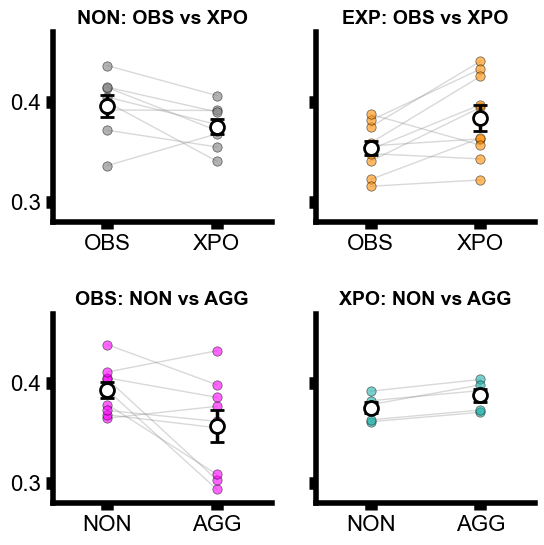

In [1384]:
# Compute session-level, category-stratified, per-animal JS divergence on transition probabilities

from scipy.spatial.distance import jensenshannon
from scipy.stats import shapiro, ttest_rel, wilcoxon
from statsmodels.stats.multitest import multipletests

CATEGORY_INDICES = {
    'conflict':      [0, 1, 2, 3],
    'investigative': [4, 6, 7, 8],
    'asocial':       [5, 9, 10, 11, 12],
}

def compute_js_dists_transitions_stratified(all_transitions, category_indices, n_sessions=3):
    """
    Stratified JS distance on transition matrices: for each behavioral
    category, restrict to the rows (FROM-states) belonging to that category
    across all TO-states, flatten, renormalize as its own probability
    vector, compute JS distance, then average across the three categories.
    Categories weighted equally regardless of cluster count, same rationale
    as the occupancy version.
    """
    n_animals = all_transitions.shape[-1]
    per_category_dists = {}

    for cat_name, idx in category_indices.items():
        sub_transitions = all_transitions[idx, :, :, :]  # (n_cat_rows, 13, n_sessions, n_animals)
        dists = np.full((n_sessions, n_sessions, n_animals, n_animals), np.nan)

        for animal in range(n_animals):
            for s1 in range(n_sessions):
                v1_raw = sub_transitions[:, :, s1, animal].flatten()
                denom1 = np.nansum(v1_raw)
                if denom1 == 0:
                    continue
                v1 = v1_raw / denom1
                for second_animal in range(n_animals):
                    if second_animal == animal:
                        continue
                    for s2 in range(n_sessions):
                        v2_raw = sub_transitions[:, :, s2, second_animal].flatten()
                        denom2 = np.nansum(v2_raw)
                        if denom2 == 0:
                            continue
                        v2 = v2_raw / denom2
                        dists[s1, s2, animal, second_animal] = jensenshannon(v1, v2)

        per_category_dists[cat_name] = dists

    stacked = np.stack(list(per_category_dists.values()), axis=0)
    return np.nanmean(stacked, axis=0), per_category_dists, n_animals


def per_animal_avg_dist(dists, query_idx, ref_idx):
    """One value per query animal: JS distance to ref group, averaged over
    session pairs and reference animals."""
    sub = dists[:, :, query_idx[:, None], ref_idx[None, :]]
    return np.nanmedian(sub, axis=(0, 1, 3))


# ── Distance matrix (all groups already share one array, unlike the
# occupancy version which needed separate OBS-set / XPO-set calls) ───────────
dists, per_cat_dists, n_animals = compute_js_dists_transitions_stratified(
    all_transitions, CATEGORY_INDICES)

agg_idx = np.arange(0, 10)
obs_idx = np.arange(10, 19)
non_idx = np.arange(19, 27)
xpo_idx = np.arange(27, n_animals)

# ── Per-animal distances, query axis = fixed reference cohort, so every
# comparison below is paired by that cohort's animal identity ────────────────
non_obs_animal = per_animal_avg_dist(dists, non_idx, obs_idx)  # NON -> OBS, n=n_non
non_xpo_animal = per_animal_avg_dist(dists, non_idx, xpo_idx)  # NON -> XPO, n=n_non, SAME animals
agg_obs_animal = per_animal_avg_dist(dists, agg_idx, obs_idx)  # AGG -> OBS, n=n_agg
agg_xpo_animal = per_animal_avg_dist(dists, agg_idx, xpo_idx)  # AGG -> XPO, n=n_agg, SAME animals
obs_non_animal = per_animal_avg_dist(dists, obs_idx, non_idx)  # OBS -> NON, n=n_obs
obs_agg_animal = per_animal_avg_dist(dists, obs_idx, agg_idx)  # OBS -> AGG, n=n_obs, SAME animals
xpo_non_animal = per_animal_avg_dist(dists, xpo_idx, non_idx)  # XPO -> NON, n=n_xpo
xpo_agg_animal = per_animal_avg_dist(dists, xpo_idx, agg_idx)  # XPO -> AGG, n=n_xpo, SAME animals


def compute_df_for_test(test_name, n):
    return n - 1 if test_name == 'paired t-test' else np.nan

def paired_test(a, b, alternative='two-sided', alpha=0.05):
    """
    Paired test with an explicit shared-NaN mask and an explicit alternative,
    since these comparisons test pre-specified directional hypotheses.
    alternative applies to (a, b): 'greater' means a > b, 'less' means a < b.
    """
    mask = ~np.isnan(a) & ~np.isnan(b)
    a_clean, b_clean = a[mask], b[mask]
    n = len(a_clean)
    if n < 3:
        return {'test': 'n/a', 'stat': np.nan, 'df': np.nan, 'p': np.nan,
                'n': n, 'a': a_clean, 'b': b_clean, 'alternative': alternative}
    diffs = a_clean - b_clean
    _, p_diff = shapiro(diffs)
    if p_diff > alpha:
        stat, p = ttest_rel(a_clean, b_clean, alternative=alternative)
        test = 'paired t-test'
    else:
        try:
            stat, p = wilcoxon(a_clean, b_clean, alternative=alternative)
        except ValueError:
            stat, p = np.nan, np.nan
        test = 'Wilcoxon signed-rank'
    return {'test': test, 'stat': stat, 'df': compute_df_for_test(test, n), 'p': p,
            'n': n, 'a': a_clean, 'b': b_clean, 'alternative': alternative}


# ── Directional hypotheses, same mapping as the occupancy version:
# NON: NON-OBS > NON-XPO           → a=non_obs, b=non_xpo → 'greater'
# EXP: EXP-OBS < EXP-XPO           → a=agg_obs, b=agg_xpo → 'less'
# OBS: OBS-EXP < OBS-NON  (i.e. OBS-NON > OBS-EXP) → a=obs_non, b=obs_agg → 'greater'
# XPO: XPO-EXP > XPO-NON  (i.e. XPO-NON < XPO-EXP) → a=xpo_non, b=xpo_agg → 'less'
# ── Per-panel individual-dot color = query cohort identity;
#    mean dot colors = referenced group (already encoded as c1/c2) ───────────
comparisons = [
    ('NON: OBS vs XPO', non_obs_animal, non_xpo_animal, 'magenta', 'lightseagreen', ['OBS', 'XPO'], 'greater', 'gray'),
    ('EXP: OBS vs XPO', agg_obs_animal, agg_xpo_animal, 'magenta', 'lightseagreen', ['OBS', 'XPO'], 'less',    'darkorange'),
    ('OBS: NON vs AGG', obs_non_animal, obs_agg_animal, 'gray',    'darkorange',    ['NON', 'AGG'], 'greater', 'magenta'),
    ('XPO: NON vs AGG', xpo_non_animal, xpo_agg_animal, 'gray',    'darkorange',    ['NON', 'AGG'], 'less',    'lightseagreen'),
]

results = []
raw_p = []
for label, a, b, c1, c2, xlabels, alt, dot_color in comparisons:
    r = paired_test(a, b, alternative=alt)
    r.update({'label': label, 'c1': c1, 'c2': c2, 'xlabels': xlabels, 'dot_color': dot_color})
    results.append(r)
    raw_p.append(r['p'])

_, p_fdr, _, _ = multipletests(raw_p, method='fdr_bh')
for r, p_c in zip(results, p_fdr):
    r['p_fdr'] = p_c

# ── Summary table ─────────────────────────────────────────────────────────────
print(f'\n{"="*105}')
print(f'Stratified, per-animal transition JS distance — one-sided paired tests per '
      f'pre-specified hypothesis')
print(f'{"="*105}')
print(f'{"Comparison":<20} {"Alt":<10} {"Test":<24} {"Stat":>9} {"df":>7} '
      f'{"p_fdr":>10} {"Sig":>5} {"n":>4}')
print(f'{"─"*105}')
for r in results:
    stat_s = f'{r["stat"]:.4f}' if not np.isnan(r['stat']) else 'n/a'
    df_s   = f'{r["df"]:.1f}'   if not np.isnan(r['df'])   else 'n/a'
    sig_s  = get_sig(r['p_fdr']) or 'ns'
    print(f'{r["label"]:<20} {r["alternative"]:<10} {r["test"]:<24} {stat_s:>9} {df_s:>7} '
          f'{r["p_fdr"]:>10.4e} {sig_s:>5} {r["n"]:>4}')
print(f'{"="*105}')

# ── 2×2 mean ± SEM plots ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(6, 6), sharey=True)
axes = axes.flatten()

for idx, r in enumerate(results):
    ax = axes[idx]
    a, b, c1, c2, dot_color = r['a'], r['b'], r['c1'], r['c2'], r['dot_color']
    positions = [1, 2]

    # ── Individual animals (uniform query-cohort color) + paired lines ───────
    for i in range(r['n']):
        ax.plot(positions, [a[i], b[i]], color='gray', alpha=0.3, linewidth=1, zorder=1)
    for j, data in enumerate([a, b]):
        ax.scatter(np.full(len(data), positions[j]), data,
                   color=dot_color, edgecolor='black', linewidths=0.5,
                   s=45, alpha=0.6, zorder=3)

    # ── Mean ± SEM, colored by the referenced group (c1/c2) ───────────────────
    for j, (data, c) in enumerate(zip([a, b], [c1, c2])):
        mean_val = np.mean(data)
        sem_val  = sem(data)
        ax.errorbar(positions[j], mean_val, yerr=sem_val,
                   fmt='o', color='white', markeredgecolor='black', markersize=10,
                   markeredgewidth=2, ecolor='black', elinewidth=2.5, capsize=5, capthick=2.5,
                   zorder=5)

    ax.set_xlim(0.5, 2.5)
    ax.set_xticks(positions)
    ax.set_xticklabels(r['xlabels'], fontfamily='Arial')
    ax.set_title(r['label'], fontsize=14, fontfamily='Arial', fontweight='bold')
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontfamily('Arial'); tick.set_fontsize(16)
    for spine in ax.spines.values():
        spine.set_linewidth(4)
    ax.tick_params(length=5, width=9)
    ax.set_ylim(bottom=0.28, top=0.47)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('.\\figures\\fig1_JS_divergence_transitions_stratified_mean_sem.svg',
            dpi=300, bbox_inches='tight')
plt.show()

In [1385]:
# ── Source data export: 1s ──────────────────────────
os.makedirs('./sourceData', exist_ok=True)

rows = []
for r in results:
    xlabel_a, xlabel_b = r['xlabels']
    for v in r['a']:
        rows.append({
            'comparison': r['label'],
            'series': xlabel_a,
            'js_distance': v,
            'alternative': r['alternative'],
            'test': r['test'],
            'stat': r['stat'],
            'df': r['df'],
            'p_fdr': r['p_fdr'],
            'n': r['n'],
        })
    for v in r['b']:
        rows.append({
            'comparison': r['label'],
            'series': xlabel_b,
            'js_distance': v,
            'alternative': r['alternative'],
            'test': r['test'],
            'stat': r['stat'],
            'df': r['df'],
            'p_fdr': r['p_fdr'],
            'n': r['n'],
        })

sourceData_1s = pd.DataFrame(rows)
sourceData_1s.to_csv('./sourceData/1s.csv', index=False)

In [1051]:
# decoder using transitions

# SVM classification using cluster transitions
from sklearn.model_selection import LeaveOneOut
from sklearn.svm import SVC
from sklearn.metrics import balanced_accuracy_score, f1_score
from sklearn.utils import shuffle

# Define the data

agg_X = agg_transitions_2_map.reshape(169, 30)
obs_X = obs_transitions_2_map.reshape(169, 27)
non_X = non_transitions_2_map.reshape(169, 24)
xpo_X = xpo_transitions_2_map.reshape(169, 15)

X = np.concatenate([agg_X, obs_X, non_X], axis=1).T
y = np.array([1]*agg_X.shape[1] + [2]*obs_X.shape[1] + [3]*non_X.shape[1]).reshape(1, -1).T
np.random.seed(1499)

# Initialize leave-one-out cross-validator
loo = LeaveOneOut()

# Initialize model
model = SVC()

# Store predictions
predictions = []

# Perform leave-one-out cross-validation
for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Train the model
    model.fit(X_train, y_train.ravel())
    
    # Predict the test sample
    y_pred = model.predict(X_test)
    
    # Store the prediction
    predictions.append(y_pred[0])

# Evaluate the model
print('Evaluation on the test set:')
test_accuracy = balanced_accuracy_score(y, predictions)
test_f1 = f1_score(y, predictions, average='weighted')
print(f'Accuracy: {test_accuracy:.2f}')
print(f'F1 Score: {test_f1:.2f}')

# Create null distribution
num_shuffles = 1000
null_accuracies = []
null_f1s = []
from tqdm import tqdm
for _ in tqdm(range(num_shuffles)):
    y_shuffled = shuffle(y)
    null_predictions = []
    
    for train_index, test_index in loo.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y_shuffled[train_index], y_shuffled[test_index]
        
        # Train the model
        model.fit(X_train, y_train.ravel())
        
        # Predict the test sample
        y_pred = model.predict(X_test)
        
        # Store the prediction
        null_predictions.append(y_pred[0])
    
    # Evaluate the model on shuffled data
    null_accuracies.append(balanced_accuracy_score(y, null_predictions))
    null_f1s.append(f1_score(y, null_predictions, average='weighted'))

Evaluation on the test set:
Accuracy: 0.52
F1 Score: 0.50


100%|██████████| 1000/1000 [01:55<00:00,  8.66it/s]


In [1054]:
p_value_accuracy = np.mean(np.array(null_accuracies) >= test_accuracy)
print(f'p-value for accuracy: {p_value_accuracy:.3f}')
p_value_f1 = np.mean(np.array(null_f1s) >= test_f1)
print(f'p-value for F1 score: {p_value_f1:.5f}')

p-value for accuracy: 0.002
p-value for F1 score: 0.00200



Shuffled null distribution:
  Mean         : 0.333
  95% CI       : [0.211, 0.448]
  Observed acc : 0.516
  p-value      : 0.002


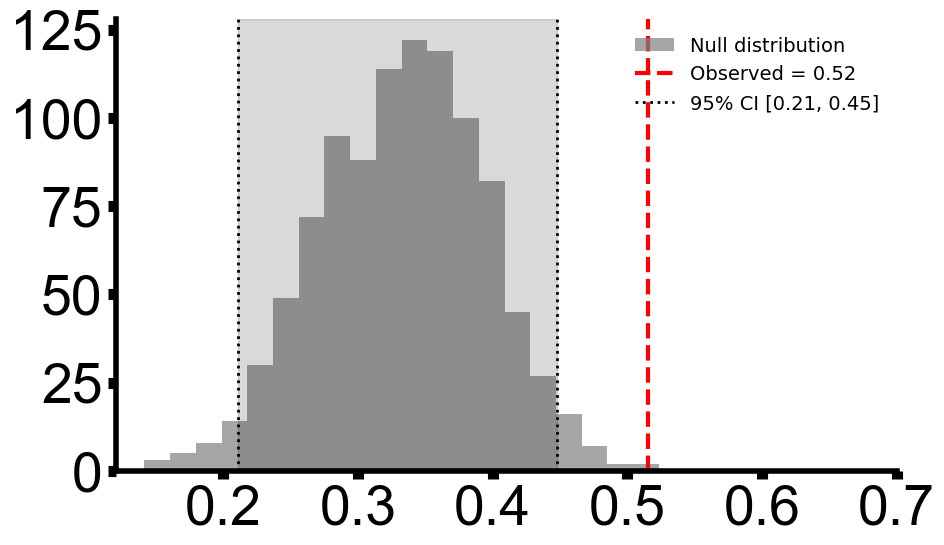

In [1053]:
# ── 95% CI of shuffled null distribution ─────────────────────────────────────
null_arr    = np.array(null_accuracies)
ci_low      = np.percentile(null_arr, 2.5)
ci_high     = np.percentile(null_arr, 97.5)
null_mean   = null_arr.mean()

print(f'\nShuffled null distribution:')
print(f'  Mean         : {null_mean:.3f}')
print(f'  95% CI       : [{ci_low:.3f}, {ci_high:.3f}]')
print(f'  Observed acc : {test_accuracy:.3f}')
print(f'  p-value      : {p_value_accuracy:.3f}')

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.hist(null_arr, bins=20, alpha=0.7, label='Null distribution', color='gray')

# observed accuracy
plt.axvline(test_accuracy, color='red', linestyle='dashed', linewidth=3,
            label=f'Observed = {test_accuracy:.2f}')

# 95% CI bounds
plt.axvline(ci_low,  color='black', linestyle=':', linewidth=2,
            label=f'95% CI [{ci_low:.2f}, {ci_high:.2f}]')
plt.axvline(ci_high, color='black', linestyle=':', linewidth=2)

# shade the CI region
plt.axvspan(ci_low, ci_high, alpha=0.15, color='black', label='_nolegend_')

plt.xlim(0.12, 0.7)
plt.xticks([0.2, 0.3, 0.4, 0.5, 0.6, 0.7], fontsize=40, fontfamily='Arial')
plt.yticks(fontsize=40, fontfamily='Arial')
plt.legend(fontsize=14, frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig('./figures/fig1_transition_LOO_Accuracy_score.svg')
plt.show()

In [1055]:
sourceData_ED1h = pd.DataFrame({'null_accuracy': null_arr})
sourceData_ED1h['observed_accuracy'] = test_accuracy
sourceData_ED1h['p_value'] = p_value_accuracy
sourceData_ED1h['null_ci_low_2p5'] = ci_low
sourceData_ED1h['null_ci_high_97p5'] = ci_high
sourceData_ED1h.to_csv('./sourceData/ED1h.csv', index=False)

Doing the same with XPO/OBS

In [1057]:
# decoder using transitions

# SVM classification using cluster persistences
from sklearn.model_selection import LeaveOneOut
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.utils import shuffle
np.random.seed(42)

# Define the data

X = np.concatenate([obs_X, xpo_X], axis=1).T
y = np.array([0]*obs_X.shape[1] + [1]*xpo_X.shape[1]).reshape(1, -1).T

# Initialize leave-one-out cross-validator
loo = LeaveOneOut()

# Initialize model
model = SVC()

# Store predictions
predictions = []

# Perform leave-one-out cross-validation
for train_index, test_index in loo.split(X):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]
    
    # Train the model
    model.fit(X_train, y_train.ravel())
    
    # Predict the test sample
    y_pred = model.predict(X_test)
    
    # Store the prediction
    predictions.append(y_pred[0])

# Evaluate the model
print('Evaluation on the test set:')
test_accuracy = balanced_accuracy_score(y, predictions)
test_f1 = f1_score(y, predictions, average='weighted')
print(f'Accuracy: {test_accuracy:.2f}')
print(f'F1 Score: {test_f1:.2f}')

# Create null distribution
num_shuffles = 1000
null_accuracies = []
null_f1s = []
from tqdm import tqdm
for _ in tqdm(range(num_shuffles)):
    y_shuffled = shuffle(y)
    null_predictions = []
    
    for train_index, test_index in loo.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y_shuffled[train_index], y_shuffled[test_index]
        
        # Train the model
        model.fit(X_train, y_train.ravel())
        
        # Predict the test sample
        y_pred = model.predict(X_test)
        
        # Store the prediction
        null_predictions.append(y_pred[0])
    
    # Evaluate the model on shuffled data
    null_accuracies.append(balanced_accuracy_score(y, null_predictions))
    null_f1s.append(f1_score(y, null_predictions, average='weighted'))

Evaluation on the test set:
Accuracy: 0.68
F1 Score: 0.72


100%|██████████| 1000/1000 [00:41<00:00, 24.13it/s]


In [1059]:
p_value_accuracy = np.mean(np.array(null_accuracies) >= test_accuracy)
print(f'p-value for accuracy: {p_value_accuracy:.3f}')
p_value_f1 = np.mean(np.array(null_f1s) >= test_f1)
print(f'p-value for F1 score: {p_value_f1:.5f}')

p-value for accuracy: 0.000
p-value for F1 score: 0.00000



Shuffled null distribution:
  Mean         : 0.497
  95% CI       : [0.444, 0.533]
  Observed acc : 0.678
  p-value      : 0.002


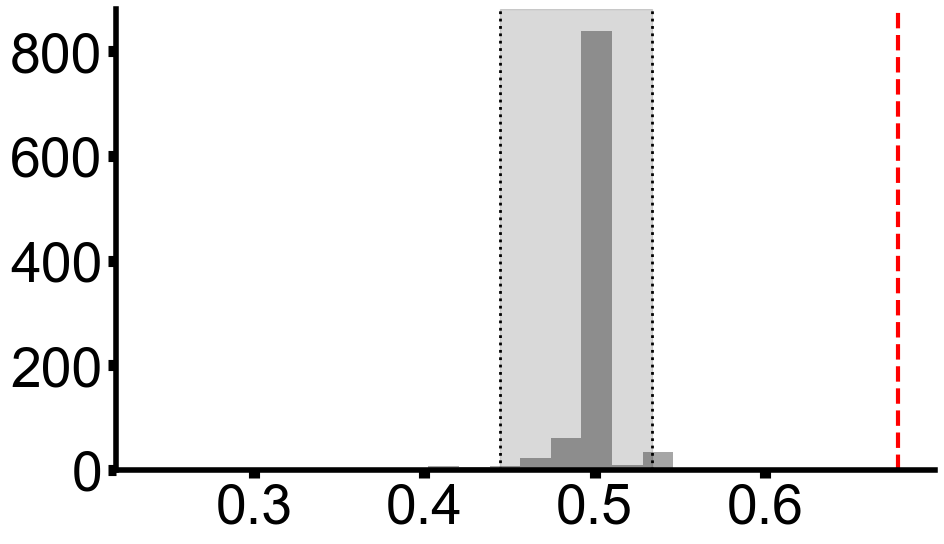

In [1058]:
# ── 95% CI of shuffled null distribution ─────────────────────────────────────
null_arr    = np.array(null_accuracies)
ci_low      = np.percentile(null_arr, 2.5)
ci_high     = np.percentile(null_arr, 97.5)
null_mean   = null_arr.mean()

print(f'\nShuffled null distribution:')
print(f'  Mean         : {null_mean:.3f}')
print(f'  95% CI       : [{ci_low:.3f}, {ci_high:.3f}]')
print(f'  Observed acc : {test_accuracy:.3f}')
print(f'  p-value      : {p_value_accuracy:.3f}')

# ── Plot ──────────────────────────────────────────────────────────────────────
plt.figure(figsize=(10, 6))
plt.hist(null_arr, bins=20, alpha=0.7, label='Null distribution', color='gray')

# observed accuracy
plt.axvline(test_accuracy, color='red', linestyle='dashed', linewidth=3,
            label=f'Observed = {test_accuracy:.2f}')

# 95% CI bounds
plt.axvline(ci_low,  color='black', linestyle=':', linewidth=2,
            label=f'95% CI [{ci_low:.2f}, {ci_high:.2f}]')
plt.axvline(ci_high, color='black', linestyle=':', linewidth=2)

# shade the CI region
plt.axvspan(ci_low, ci_high, alpha=0.15, color='black', label='_nolegend_')
plt.xticks(fontsize=40, fontfamily='Arial')
plt.yticks(fontsize=40, fontfamily='Arial')
# plt.legend(fontsize=14, frameon=False)
sns.despine()
plt.tight_layout()
# plt.savefig('./figures/fig1/transition_LOO_F1_score_XPO.svg')


In [1060]:
sourceData_ED3b_right = pd.DataFrame({'null_accuracy': null_arr})
sourceData_ED3b_right['observed_accuracy'] = test_accuracy
sourceData_ED3b_right['p_value'] = p_value_accuracy
sourceData_ED3b_right['null_ci_low_2p5'] = ci_low
sourceData_ED3b_right['null_ci_high_97p5'] = ci_high

sourceData_ED3b_right.to_csv('./sourceData/ED3b_right.csv', index=False)

Classifying OBS/XPO with EXP/NON

Percentage of OBS classified as AGG: 44.44%
Percentage of XPO classified as AGG: 0.00%
Brunner-Munzel Test (on P(AGG) scores): W = -2.563, p = 0.0281

Contingency table:
                AGG    NON
         OBS      4      5
         XPO      0      5

Fisher's Exact Test (secondary, thresholded): p = 0.2208, odds ratio = inf


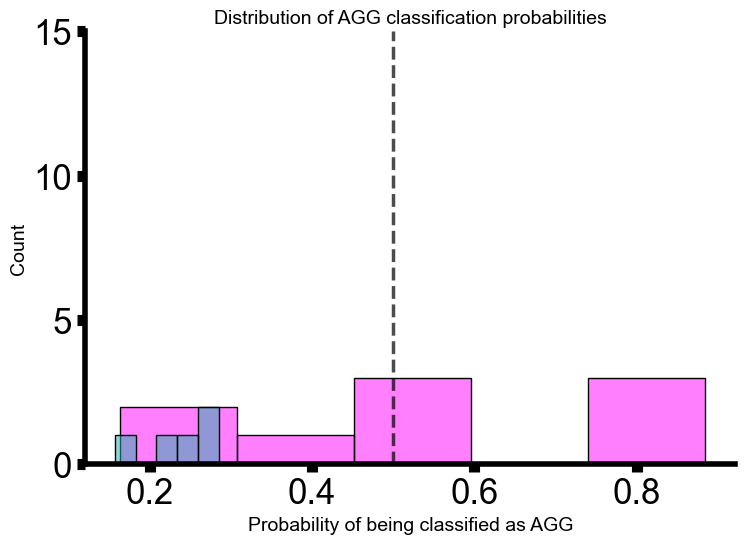

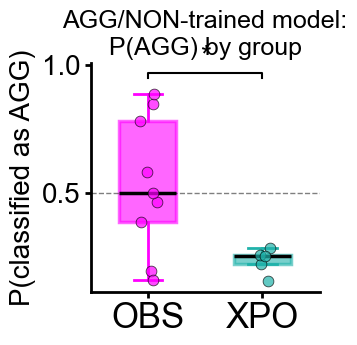

In [1064]:
# Train classifier on animal transitions -> measure probability of being classified as EXP

from scipy.stats import fisher_exact, brunnermunzel, shapiro, levene

# 1. Train model on AGG/NON data
agg_X = np.nanmean(agg_transitions_2_map[:, :, -3:, :], axis=2).reshape(169, 10)
non_X = np.nanmean(non_transitions_2_map[:, :, -3:, :], axis=2).reshape(169, 8)

X_train = np.concatenate([agg_X, non_X], axis=1).T
y_train = np.array([1]*agg_X.shape[1] + [0]*non_X.shape[1])
np.random.seed(1459)

model = SVC(probability=True)
model.fit(X_train, y_train)

# 2. Apply the model to OBS/XPO data
obs_X = np.nanmean(obs_transitions_2_map[:, :, -3:, :], axis=2).reshape(169, 9)
xpo_X = np.nanmean(xpo_transitions_2_map[:, :, -3:, :], axis=2).reshape(169, 5)

obs_labels = np.ones(obs_X.shape[1])
xpo_labels = np.zeros(xpo_X.shape[1])

X_test = np.concatenate([obs_X, xpo_X], axis=1).T
y_test = np.concatenate([obs_labels, xpo_labels])

y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

obs_preds = y_pred[:obs_X.shape[1]]
xpo_preds = y_pred[obs_X.shape[1]:]
obs_proba = y_pred_proba[:obs_X.shape[1]]
xpo_proba = y_pred_proba[obs_X.shape[1]:]

obs_classified_as_agg = np.mean(obs_preds == 1)
xpo_classified_as_agg = np.mean(xpo_preds == 1)

print(f"Percentage of OBS classified as AGG: {obs_classified_as_agg*100:.2f}%")
print(f"Percentage of XPO classified as AGG: {xpo_classified_as_agg*100:.2f}%")

# ── Primary test: Brunner-Munzel on continuous P(AGG) scores ─────────────────
stat_bm, p_bm = brunnermunzel(obs_proba, xpo_proba, alternative='two-sided')
print(f"Brunner-Munzel Test (on P(AGG) scores): W = {stat_bm:.3f}, p = {p_bm:.4f}")

# ── Secondary/robustness test: Fisher's exact on thresholded predictions ─────
contingency_table = np.array([
    [np.sum(obs_preds == 1), np.sum(obs_preds == 0)],
    [np.sum(xpo_preds == 1), np.sum(xpo_preds == 0)]
])

print(f"\nContingency table:")
print(f"{'':>12} {'AGG':>6} {'NON':>6}")
print(f"{'OBS':>12} {contingency_table[0,0]:>6} {contingency_table[0,1]:>6}")
print(f"{'XPO':>12} {contingency_table[1,0]:>6} {contingency_table[1,1]:>6}")

odds_ratio, p_fisher = fisher_exact(contingency_table)
print(f"\nFisher's Exact Test (secondary, thresholded): p = {p_fisher:.4f}, odds ratio = {odds_ratio:.2f}")

# ========== Visualization ==========

# Histogram of AGG probabilities (unchanged)
fig, ax = plt.subplots(figsize=(8, 6))
sns.histplot(obs_proba, color='magenta', alpha=0.5, label='OBS', kde=False, bins=5, ax=ax)
sns.histplot(xpo_proba, color='lightseagreen', alpha=0.5, label='XPO', kde=False, bins=5, ax=ax)
ax.axvline(0.5, color='black', linestyle='--', alpha=0.7)
ax.set_xlabel('Probability of being classified as AGG', fontsize=14, fontfamily='Arial')
ax.set_ylabel('Count', fontsize=14, fontfamily='Arial')
ax.set_title('Distribution of AGG classification probabilities', fontsize=14, fontfamily='Arial')
ax.set_yticks([0, 5, 10, 15])
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontfamily('Arial')
    label.set_fontsize(25)
sns.despine()
plt.tight_layout()
plt.savefig('./figures/fig1_agg_classifier_obs_xpo_probabilities.svg')
plt.show()

# ── Boxplot + jittered individual animals of P(AGG), replacing the bar plot ──
def get_sig(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'n.s.'

fig, ax = plt.subplots(figsize=(4, 4))
data_to_plot = [obs_proba, xpo_proba]
positions = [0, 1]
colors = ['magenta', 'lightseagreen']

box = ax.boxplot(data_to_plot, positions=positions, patch_artist=True, widths=0.5,
                 medianprops=dict(color='black', linewidth=2.5),
                 whiskerprops=dict(linewidth=2), capprops=dict(linewidth=2),
                 flierprops=dict(marker='', markersize=0))
for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor(color)
    patch.set_alpha(0.6)
    patch.set_linewidth(2.5)
for whisker, color in zip(box['whiskers'], [c for c in colors for _ in (0, 1)]):
    whisker.set_color(color)
for cap, color in zip(box['caps'], [c for c in colors for _ in (0, 1)]):
    cap.set_color(color)

rng = np.random.default_rng(42)
for j, (data, color) in enumerate(zip(data_to_plot, colors)):
    jitter = rng.uniform(-0.08, 0.08, size=len(data))
    ax.scatter(np.full(len(data), positions[j]) + jitter, data,
               color=color, edgecolor='black', s=60, alpha=0.7, zorder=5, linewidths=0.6)

ax.axhline(0.5, color='black', linestyle='--', alpha=0.5, linewidth=1)
ax.set_xticks(positions)
ax.set_xticklabels(['OBS', 'XPO'], fontsize=25, fontfamily='Arial')
ax.set_ylabel('P(classified as AGG)', fontsize=20, fontfamily='Arial')
ax.set_title('AGG/NON-trained model:\nP(AGG) by group', fontsize=18, fontfamily='Arial')
for label in ax.get_yticklabels():
    label.set_fontfamily('Arial')
    label.set_fontsize(20)

ax.autoscale()
y_max = ax.get_ylim()[1]
bracket_y = y_max * 1.05
sig_label = get_sig(p_bm)
ax.plot([positions[0], positions[0], positions[1], positions[1]],
        [bracket_y * 0.98, bracket_y, bracket_y, bracket_y * 0.98], 'k-', linewidth=1.5)
ax.text(0.5, bracket_y * 1.01, sig_label, ha='center', va='bottom', fontsize=20, fontfamily='Arial')

for spine in ax.spines.values():
    spine.set_linewidth(2)
ax.tick_params(axis='both', length=4, width=2)
sns.despine()
plt.tight_layout()
plt.savefig('./figures/fig1_agg_classifier_obs_xpo_probabilities_transitions.svg')
plt.show()

In [1065]:
# ── Source data export: ED3f_right ─────────────────────────────────────────────
os.makedirs('./sourceData', exist_ok=True)

sourceData_ED3f_right = pd.concat([
    pd.DataFrame({'group': 'OBS', 'p_AGG': obs_proba}),
    pd.DataFrame({'group': 'XPO', 'p_AGG': xpo_proba}),
], ignore_index=True)

sourceData_ED3f_right['test'] = 'Brunner-Munzel'
sourceData_ED3f_right['alternative'] = 'two-sided'
sourceData_ED3f_right['statistic'] = stat_bm
sourceData_ED3f_right['p_value'] = p_bm

sourceData_ED3f_right.to_csv('./sourceData/ED3f_right.csv', index=False)

PCA visualization

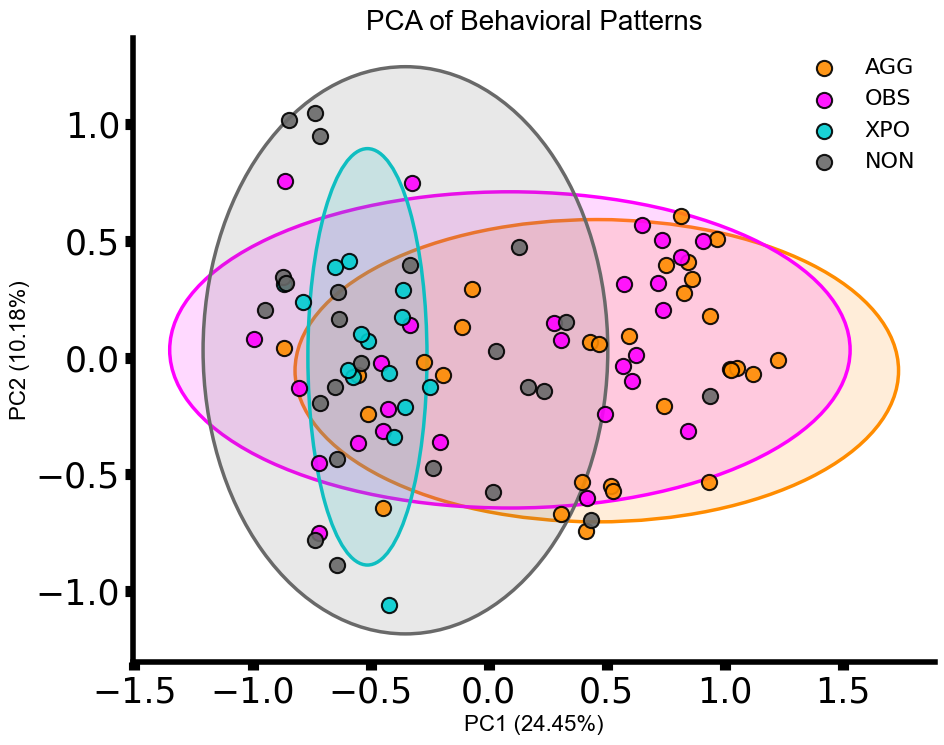

In [1066]:
from sklearn.decomposition import PCA
from matplotlib.patches import Ellipse
import matplotlib.transforms as transforms
np.random.seed(11)

# Prepare data matrices combining all animals for each condition
agg_data = agg_transitions_2_map.reshape(169, 30).T
obs_data = obs_transitions_2_map.reshape(169, 27).T
xpo_data = xpo_transitions_2_map.reshape(169, 15).T
non_data = non_transitions_2_map.reshape(169, 24).T

# Stack all data for PCA
all_data = np.vstack([agg_data, obs_data, xpo_data, non_data])
labels = np.concatenate([
    ['AGG'] * agg_data.shape[0], 
    ['OBS'] * obs_data.shape[0],
    ['XPO'] * xpo_data.shape[0],
    ['NON'] * non_data.shape[0]
])

# Apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(all_data)

# Create a DataFrame for easier plotting
import pandas as pd
pca_df = pd.DataFrame({
    'PC1': pca_result[:, 0],
    'PC2': pca_result[:, 1],
    'Condition': labels
})

# Define confidence ellipse function
def confidence_ellipse(x, y, ax, n_std=2.0, **kwargs):
    mean_x, mean_y = np.mean(x), np.mean(y)
    cov = np.cov(x, y)
    pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
    ell_radius_x = np.sqrt(1 + pearson) * n_std * np.sqrt(cov[0, 0])
    ell_radius_y = np.sqrt(1 - pearson) * n_std * np.sqrt(cov[1, 1])
    ellipse = Ellipse((mean_x, mean_y), width=ell_radius_x * 2, height=ell_radius_y * 2, **kwargs)
    return ax.add_patch(ellipse)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))

# Sharper, more saturated colors
colors = {
    'AGG': '#FF8C00',      # Darker orange
    'OBS': '#FF00FF',      # Pure magenta
    'XPO': '#00CED1',      # Darker cyan
    'NON': '#696969'       # Darker gray
}

# Plot ellipses first (behind the points)
for condition, color in colors.items():
    subset = pca_df[pca_df['Condition'] == condition]
    
    # Add filled ellipse with lighter alpha
    confidence_ellipse(subset['PC1'], subset['PC2'], ax, 
                      alpha=0.15, facecolor=color, edgecolor='none')
    
    # Add ellipse outline with darker edge
    confidence_ellipse(subset['PC1'], subset['PC2'], ax, 
                      alpha=1.0, facecolor='none', edgecolor=color, linewidth=2.5)

# Plot scatter points on top
for condition, color in colors.items():
    subset = pca_df[pca_df['Condition'] == condition]
    ax.scatter(subset['PC1'], subset['PC2'], c=color, label=condition, 
              s=120, alpha=0.9, edgecolors='black', linewidths=1.5, zorder=3)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})', fontsize=16, fontfamily='Arial')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})', fontsize=16, fontfamily='Arial')
ax.set_title('PCA of Behavioral Patterns', fontsize=20, fontfamily='Arial')
ax.legend(fontsize=16, frameon=False)
sns.despine()
plt.tight_layout()
# plt.savefig('./figures/fig1/pca_visualization_transitions.svg', dpi=300, bbox_inches='tight')
plt.show()

In [116]:
sourceData_1t = pca_df.copy()
sourceData_1t['Condition'] = sourceData_1t['Condition'].replace('AGG', 'EXP')
sourceData_1t['PC1_explained_variance'] = pca.explained_variance_ratio_[0]
sourceData_1t['PC2_explained_variance'] = pca.explained_variance_ratio_[1]

sourceData_1t.to_csv('./sourceData/1t.csv', index=False)

### Features

In [1104]:
new_feat_descs = ['intruder centroid speed', 'intruder centroid lagged speed', 'intruder pose', 'intruder head speed', 'intruder head lagged spead', 'intruder body length',
'intruder head-to-resident tailbase', 'intruder orientation to resident', 'IoU', 'inter-animal distance', 'inter-animal lagged distance', 'inter-animal speed', 'inter-animal lagged speed', 
'resident centroid speed', 'resident centroid lagged speed', 'resident pose', 'resident head speed', 'resident head lagged spead', 'resident body length', 'resident head-to-intruder head', 'resident head-to-intruder head lagged',
'resident head-to-intruder tailbase', 'resident orientation to intruder']

def map_feature_data(animals, features, feats_list, beh='agg'):
    
    feats_across_animals = np.zeros((len(feats_list), 27, len(animals)))
    feats_across_animals[:] = np.nan
    
    for a, animal in enumerate(animals):
        
        sessions2map = list(features.keys())
        
        if beh == 'agg':
            sessions2map = [x for x in sessions2map if animal in x if '_balbc_' in x or '_mCD1_' in x]
        elif beh == 'obs':
            sessions2map = [x for x in sessions2map if animal in x if '_obs_' in x or '_OBSmCD1_' in x]
        else:
            sessions2map = [x for x in sessions2map if animal in x if 'toy' in x or 'toyCD1' in x]
            
        for s, session in enumerate(sessions2map):
            sample = features[session]
            for f, feat in enumerate(feats_list):
                feats_across_animals[f, s, a] = np.nanmean(sample[feat].values)

    return feats_across_animals

agg_feats_across_animals = map_feature_data(agg_animals, features, feats_list, beh='agg')
obs_feats_across_animals = map_feature_data(obs_animals, features, feats_list, beh='obs')
non_feats_across_animals = map_feature_data(non_animals, features, feats_list, beh='non')


Inter-animal distance
Normality - EXP: p=0.2615, OBS: p=0.2485, NON: p=0.3690
Levene's test: F=0.3273, p=0.7240
Bartlett's test: χ²=1.1193, p=0.5714
Using parametric tests (normal, equal variances)
One-way ANOVA: F=6.1781, p=0.0068
###
Resident centroid speed
Normality - EXP: p=0.7758, OBS: p=0.4399, NON: p=0.3230
Levene's test: F=0.0049, p=0.9951
Bartlett's test: χ²=0.2173, p=0.8970
Using parametric tests (normal, equal variances)
One-way ANOVA: F=2.6646, p=0.0901
###
IoU
Normality - EXP: p=0.6508, OBS: p=0.0233, NON: p=0.7239
Levene's test: F=1.7448, p=0.1961
Using non-parametric tests (normality not assumed)
Kruskal-Wallis: H=14.7223, p=0.0006
###
Intruder centroid speed
Normality - EXP: p=0.7905, OBS: p=0.7623, NON: p=0.4868
Levene's test: F=1.5568, p=0.2314
Bartlett's test: χ²=5.1502, p=0.0761
Using parametric tests (normal, equal variances)
One-way ANOVA: F=1.6665, p=0.2100
###

ED1j — omnibus -> posthoc, FDR-BH pooled across all 12 posthoc comparisons (4 features x 3 pairwise)
F

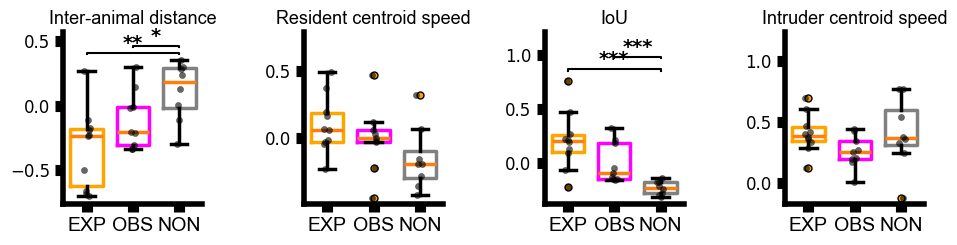

In [1117]:
from scipy import stats
from scipy.stats import shapiro, levene, bartlett, ttest_ind, brunnermunzel, mannwhitneyu
from statsmodels.stats.multitest import multipletests
import statsmodels.api as sm

def format_p(p):
    if p is None or np.isnan(p): return 'n/a'
    return f'{p:.3e}' if p < 1e-4 else f'{p:.4f}'

def get_sig(p):
    if p is None or np.isnan(p): return ''
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return ''

def compute_df_for_test(test_name, a, b):
    if test_name == 't-test':
        return len(a) + len(b) - 2
    elif test_name == 'Welch t-test':
        v1, v2 = np.var(a, ddof=1), np.var(b, ddof=1)
        n1, n2 = len(a), len(b)
        return (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
    else:
        return np.nan

def run_comprehensive_stats(data2plot, alpha=0.05, variance_alpha=0.05, verbose=True):
    """
    Omnibus (ANOVA/Welch ANOVA/Kruskal-Wallis) -> posthoc (t-test/Welch
    t-test/Brunner-Munzel, MWU fallback if BM degenerates). Returns RAW
    posthoc p-values only — FDR applied externally, pooled across all
    features' posthocs.
    """
    exp_d = data2plot[0][~np.isnan(data2plot[0])]
    obs_d = data2plot[1][~np.isnan(data2plot[1])]
    non_d = data2plot[2][~np.isnan(data2plot[2])]

    if len(exp_d) < 3 or len(obs_d) < 3 or len(non_d) < 3:
        if verbose: print("Insufficient data for statistical analysis")
        return None

    df = pd.DataFrame({
        'Activity': np.concatenate([exp_d, obs_d, non_d]),
        'Group': np.concatenate([['exp']*len(exp_d), ['obs']*len(obs_d), ['non']*len(non_d)]),
    })

    _, p_exp_norm = shapiro(exp_d)
    _, p_obs_norm = shapiro(obs_d)
    _, p_non_norm = shapiro(non_d)
    normality_passed = all(p > alpha for p in [p_exp_norm, p_obs_norm, p_non_norm])
    if verbose:
        print(f"Normality - EXP: p={format_p(p_exp_norm)}, OBS: p={format_p(p_obs_norm)}, NON: p={format_p(p_non_norm)}")

    levene_stat, levene_p = levene(exp_d, obs_d, non_d)
    equal_variances = levene_p > variance_alpha
    if verbose:
        print(f"Levene's test: F={levene_stat:.4f}, p={format_p(levene_p)}")
    if normality_passed:
        bartlett_stat, bartlett_p = bartlett(exp_d, obs_d, non_d)
        if verbose:
            print(f"Bartlett's test: χ²={bartlett_stat:.4f}, p={format_p(bartlett_p)}")
        equal_variances = equal_variances and (bartlett_p > variance_alpha)

    results = {'normality_passed': normality_passed, 'equal_variances': equal_variances,
              'levene_p': levene_p}

    if normality_passed and equal_variances:
        if verbose: print("Using parametric tests (normal, equal variances)")
        model = sm.OLS.from_formula('Activity ~ C(Group)', data=df).fit()
        anova_table = sm.stats.anova_lm(model, typ=2)
        f_stat, anova_p = anova_table['F'][0], anova_table['PR(>F)'][0]
        if verbose: print(f"One-way ANOVA: F={f_stat:.4f}, p={format_p(anova_p)}")
        results.update({'omnibus_test': 'ANOVA', 'omnibus_statistic': f_stat, 'omnibus_p': anova_p})

        if anova_p <= 0.05:
            t1, p_en = ttest_ind(exp_d, non_d, equal_var=True)
            t2, p_on = ttest_ind(obs_d, non_d, equal_var=True)
            t3, p_eo = ttest_ind(exp_d, obs_d, equal_var=True)
            results.update({
                'pairwise_test': 't-test',
                'agg_vs_non': {'statistic': t1, 'p_raw': p_en},
                'agg_vs_obs': {'statistic': t3, 'p_raw': p_eo},
                'obs_vs_non': {'statistic': t2, 'p_raw': p_on},
            })

    elif normality_passed and not equal_variances:
        if verbose: print("Using Welch's tests (normal, unequal variances)")
        try:
            welch_stat, welch_p = stats.f_oneway(exp_d, obs_d, non_d)
            if verbose: print(f"Welch's ANOVA: F={welch_stat:.4f}, p={format_p(welch_p)}")
            results.update({'omnibus_test': 'Welch ANOVA', 'omnibus_statistic': welch_stat, 'omnibus_p': welch_p})

            if welch_p <= 0.05:
                t1, p_en = ttest_ind(exp_d, non_d, equal_var=False)
                t2, p_on = ttest_ind(obs_d, non_d, equal_var=False)
                t3, p_eo = ttest_ind(exp_d, obs_d, equal_var=False)
                results.update({
                    'pairwise_test': 'Welch t-test',
                    'agg_vs_non': {'statistic': t1, 'p_raw': p_en},
                    'agg_vs_obs': {'statistic': t3, 'p_raw': p_eo},
                    'obs_vs_non': {'statistic': t2, 'p_raw': p_on},
                })
        except Exception:
            if verbose: print("Welch's ANOVA failed — falling back to non-parametric")
            normality_passed = False

    if not normality_passed:
        if verbose: print("Using non-parametric tests (normality not assumed)")
        kruskal_stat, kruskal_p = stats.kruskal(exp_d, obs_d, non_d)
        if verbose: print(f"Kruskal-Wallis: H={kruskal_stat:.4f}, p={format_p(kruskal_p)}")
        results.update({'omnibus_test': 'Kruskal-Wallis', 'omnibus_statistic': kruskal_stat, 'omnibus_p': kruskal_p})

        if kruskal_p <= 0.05:
            def bm_or_mwu(a, b):
                stat, p = brunnermunzel(a, b, alternative='two-sided')
                if not np.isfinite(stat) or not np.isfinite(p):
                    stat, p = mannwhitneyu(a, b, alternative='two-sided')
                return stat, p
            u1, p_en = bm_or_mwu(exp_d, non_d)
            u2, p_on = bm_or_mwu(obs_d, non_d)
            u3, p_eo = bm_or_mwu(exp_d, obs_d)
            results.update({
                'pairwise_test': 'Brunner-Munzel',
                'agg_vs_non': {'statistic': u1, 'p_raw': p_en},
                'agg_vs_obs': {'statistic': u3, 'p_raw': p_eo},
                'obs_vs_non': {'statistic': u2, 'p_raw': p_on},
            })

    if verbose: print('###')
    return results


# ── Isolate the 4 requested features ──────────────────────────────────────────
target_feats = {
    'Inter-animal distance':   9,
    'Resident centroid speed': 13,
    'IoU':                     8,
    'Intruder centroid speed': 0,
}

boxprops = {'whiskerprops': dict(linewidth=2.5),
            'capprops' : dict(linewidth=2.5),
            'medianprops' : dict(linewidth=2.5),
            'flierprops' : dict(markerfacecolor='orange', marker='o', markersize=5, linestyle='none', linewidth=2.5),
            'widths': 0.7
}

# ── Step 1: collapse sessions PER ANIMAL (no pseudoreplication), run stats ────
feat_data_cache = {}
omnibus_all     = {}
posthoc_detail  = {}
raw_p_pool      = []
raw_p_keys      = []

for feat_label, feat_idx in target_feats.items():
    # collapse the -3:/: 3 session axis to one value per animal BEFORE flattening
    agg_feat = np.nanmean(agg_feats_across_animals[feat_idx, -3:, :], axis=0)
    obs_feat = np.nanmean(obs_feats_across_animals[feat_idx, -3:, :], axis=0)
    non_feat = np.nanmean(non_feats_across_animals[feat_idx, :3, :], axis=0)

    agg_feat = agg_feat[~np.isnan(agg_feat)]
    obs_feat = obs_feat[~np.isnan(obs_feat)]
    non_feat = non_feat[~np.isnan(non_feat)]

    feat_data_cache[feat_label] = (agg_feat, obs_feat, non_feat)

    print(feat_label)
    stat_result = run_comprehensive_stats([agg_feat, obs_feat, non_feat])

    omnibus_all[feat_label] = {
        'omnibus_test':      stat_result['omnibus_test']      if stat_result else 'n/a',
        'omnibus_statistic': stat_result['omnibus_statistic'] if stat_result else np.nan,
        'omnibus_p':         stat_result['omnibus_p']         if stat_result else np.nan,
    }

    pair_data_lookup = {
        'agg_vs_obs': (agg_feat, obs_feat),
        'agg_vs_non': (agg_feat, non_feat),
        'obs_vs_non': (obs_feat, non_feat),
    }

    posthoc_detail[feat_label] = {}
    for comp in ['agg_vs_obs', 'agg_vs_non', 'obs_vs_non']:
        if stat_result is not None and comp in stat_result:
            p_raw = stat_result[comp]['p_raw']
            pairwise_test = stat_result.get('pairwise_test', 'n/a')
            a, b = pair_data_lookup[comp]
            posthoc_detail[feat_label][comp] = {
                'test': pairwise_test,
                'statistic': stat_result[comp]['statistic'],
                'df': compute_df_for_test(pairwise_test, a, b),
                'p_raw': p_raw,
            }
        else:
            posthoc_detail[feat_label][comp] = {
                'test': 'n/a (omnibus n.s.)', 'statistic': np.nan, 'df': np.nan, 'p_raw': np.nan,
            }
        raw_p_pool.append(posthoc_detail[feat_label][comp]['p_raw'])
        raw_p_keys.append((feat_label, comp))

# ── Step 2: FDR pooled across ALL posthocs (all 4 features x 3 comparisons) ──
valid = [i for i, p in enumerate(raw_p_pool) if not np.isnan(p)]
corr_full = np.full(len(raw_p_pool), np.nan)
if valid:
    _, corr, _, _ = multipletests([raw_p_pool[i] for i in valid], method='fdr_tsbh')
    for rank, i in enumerate(valid):
        corr_full[i] = corr[rank]

for (feat_label, comp), p_corr in zip(raw_p_keys, corr_full):
    posthoc_detail[feat_label][comp]['p_fdr'] = p_corr

# ── Print stats table ─────────────────────────────────────────────────────────
comp_display = {'agg_vs_obs': 'EXP vs OBS', 'agg_vs_non': 'EXP vs NON', 'obs_vs_non': 'OBS vs NON'}

print(f'\n{"="*130}')
print(f'ED1j — omnibus -> posthoc, FDR-BH pooled across all {len(raw_p_pool)} posthoc comparisons '
      f'(4 features x 3 pairwise)')
print(f'{"="*130}')
print(f'{"Feature":<24} {"Omnibus":<16} {"Omni_p":>10} {"Comparison":<12} {"Test":<20} '
      f'{"Stat":>10} {"df":>8} {"p_fdr":>10} {"Sig":>5}')
print(f'{"─"*130}')

for feat_label in target_feats:
    omni_t = omnibus_all[feat_label]['omnibus_test']
    omni_p = omnibus_all[feat_label]['omnibus_p']
    omni_p_str = format_p(omni_p) if not np.isnan(omni_p) else 'n/a'

    for comp in ['agg_vs_obs', 'agg_vs_non', 'obs_vs_non']:
        d = posthoc_detail[feat_label][comp]
        stat_str = f'{d["statistic"]:.4f}' if not np.isnan(d['statistic']) else 'n/a'
        df_str   = f'{d["df"]:.1f}'        if not np.isnan(d['df'])        else 'n/a'
        print(f'{feat_label:<24} {omni_t:<16} {omni_p_str:>10} {comp_display[comp]:<12} {d["test"]:<20} '
              f'{stat_str:>10} {df_str:>8} {format_p(d["p_fdr"]):>10} '
              f'{get_sig(d["p_fdr"]):>5}')
    print(f'{"─"*130}')
print(f'{"="*130}')

# ── Plot: 1x4, EXP/OBS/NON per feature, with individual points overlaid ──────
fig, axes = plt.subplots(1, 4, figsize=(10, 3))
rng = np.random.default_rng(42)

for plot_idx, feat_label in enumerate(target_feats):
    ax = axes[plot_idx]
    agg_feat, obs_feat, non_feat = feat_data_cache[feat_label]

    data_to_plot = [agg_feat, obs_feat, non_feat]
    positions = [0, 1, 2]
    point_colors = ['orange', 'magenta', 'gray']

    ax.boxplot(agg_feat, positions=[0], boxprops=dict(color='orange', linewidth=2.5), **boxprops)
    ax.boxplot(obs_feat, positions=[1], boxprops=dict(color='magenta', linewidth=2.5), **boxprops)
    ax.boxplot(non_feat, positions=[2], boxprops=dict(color='gray', linewidth=2.5), **boxprops)

    # ── Individual animal points, jittered ────────────────────────────────────
    for j, (data, color) in enumerate(zip(data_to_plot, point_colors)):
        jitter = rng.uniform(-0.08, 0.08, size=len(data))
        ax.scatter(np.full(len(data), positions[j]) + jitter, data,
                   color='black', s=20, alpha=0.6, zorder=5, linewidths=0.3)

    max_y = max([np.nanmax(agg_feat), np.nanmax(obs_feat), np.nanmax(non_feat)])

    bracket_pairs = [(0, 2, 'agg_vs_non'), (0, 1, 'agg_vs_obs'), (1, 2, 'obs_vs_non')]
    sig_found = [(x1, x2, comp) for x1, x2, comp in bracket_pairs
                 if get_sig(posthoc_detail[feat_label][comp]['p_fdr'])]
    for level, (x1, x2, comp) in enumerate(sig_found):
        y = max_y * (1.15 + level * 0.15)
        sig_marker = get_sig(posthoc_detail[feat_label][comp]['p_fdr'])
        ax.plot([x1, x1, x2, x2], [y - max_y*0.02, y, y, y - max_y*0.02], 'k-', linewidth=1.5)
        ax.text((x1+x2)/2, y, sig_marker, ha='center', va='bottom', fontsize=14, fontweight='bold')

    ax.set_title(feat_label, fontsize=13, fontfamily='Arial')
    ax.set_xticks([0, 1, 2])
    ax.set_xticklabels(['EXP', 'OBS', 'NON'], fontsize=14, fontfamily='Arial')
    ax.set_ylim(top=max_y * 1.6)
    ax.tick_params(axis='y', labelsize=12)
    for spine in ax.spines.values():
        if spine.spine_type in ['top', 'right']:
            spine.set_visible(False)

plt.tight_layout()
plt.savefig('.\\figures\\ED1j_feature_comparison_selected.svg', dpi=300, bbox_inches='tight')
plt.show()

# ── Source data export: ED1j ──────────────────────────────────────────────────
os.makedirs('./sourceData', exist_ok=True)

rows = []
for feat_label in target_feats:
    agg_feat, obs_feat, non_feat = feat_data_cache[feat_label]
    omni_test = omnibus_all[feat_label]['omnibus_test']
    omni_stat = omnibus_all[feat_label]['omnibus_statistic']
    omni_p    = omnibus_all[feat_label]['omnibus_p']

    for group_label, vals in [('EXP', agg_feat), ('OBS', obs_feat), ('NON', non_feat)]:
        for v in vals:
            row = {
                'feature': feat_label,
                'group': group_label,
                'value': v,
                'omnibus_test': omni_test,
                'omnibus_stat': omni_stat,
                'omnibus_p': omni_p,
            }
            for comp in ['agg_vs_obs', 'agg_vs_non', 'obs_vs_non']:
                d = posthoc_detail[feat_label][comp]
                label = comp_display[comp].replace(' vs ', '_vs_')
                row[f'{label}_test']  = d['test']
                row[f'{label}_stat']  = d['statistic']
                row[f'{label}_df']    = d['df']
                row[f'{label}_p_fdr'] = d['p_fdr']
            rows.append(row)

sourceData_ED1j = pd.DataFrame(rows)
sourceData_ED1j.to_csv('./sourceData/ED1j.csv', index=False)

In [1116]:
# clustering of clusters by features

new_feat_descs = ['intruder centroid speed', 'intruder centroid lagged speed', 'intruder pose', 'intruder head speed', 'intruder head lagged spead', 'intruder body length',
'intruder head-to-resident tailbase', 'intruder orientation to resident', 'IoU', 'inter-animal distance', 'inter-animal lagged distance', 'inter-animal speed', 'inter-animal lagged speed', 
'resident centroid speed', 'resident centroid lagged speed', 'resident pose', 'resident head speed', 'resident head lagged spead', 'resident body length', 'resident head-to-intruder head', 'resident head-to-intruder head lagged',
'resident head-to-intruder tailbase', 'resident orientation to intruder']

def map_feature_data_by_cluster(animals, features, feats_list, beh='agg'):
    
    feats_across_animals = np.zeros((13, len(feats_list), 27, len(animals)))
    feats_across_animals[:] = np.nan
    
    for a, animal in enumerate(animals):
        
        sessions2map = list(features.keys())
        
        if beh == 'agg':
            sessions2map = [x for x in sessions2map if animal in x if '_balbc_' in x or '_mCD1_' in x]
        elif beh == 'obs':
            sessions2map = [x for x in sessions2map if animal in x if '_obs_' in x or '_OBSmCD1_' in x]
        else:
            sessions2map = [x for x in sessions2map if animal in x if 'toy' in x or 'toyCD1' in x]
            
        for s, session in enumerate(sessions2map):
            sample = features[session]
            for f, feat in enumerate(feats_list):
                for cluster in np.arange(1, 14):
                    feats_across_animals[cluster-1, f, s, a] = np.nanmean(sample[full_data[session]['unsupervised labels'] == cluster][feat].values)

    return feats_across_animals

agg_feats_by_cluster = map_feature_data_by_cluster(agg_animals, features, feats_list3, beh='agg')
obs_feats_by_cluster = map_feature_data_by_cluster(obs_animals, features, feats_list3, beh='obs')
non_feats_by_cluster = map_feature_data_by_cluster(non_animals, features, feats_list3, beh='non')
feats_by_cluster = np.concatenate([agg_feats_by_cluster, obs_feats_by_cluster], axis=-1)


C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_45872\593946549.py:28: RuntimeWarning: Mean of empty slice
  feats_across_animals[cluster-1, f, s, a] = np.nanmean(sample[full_data[session]['unsupervised labels'] == cluster][feat].values)


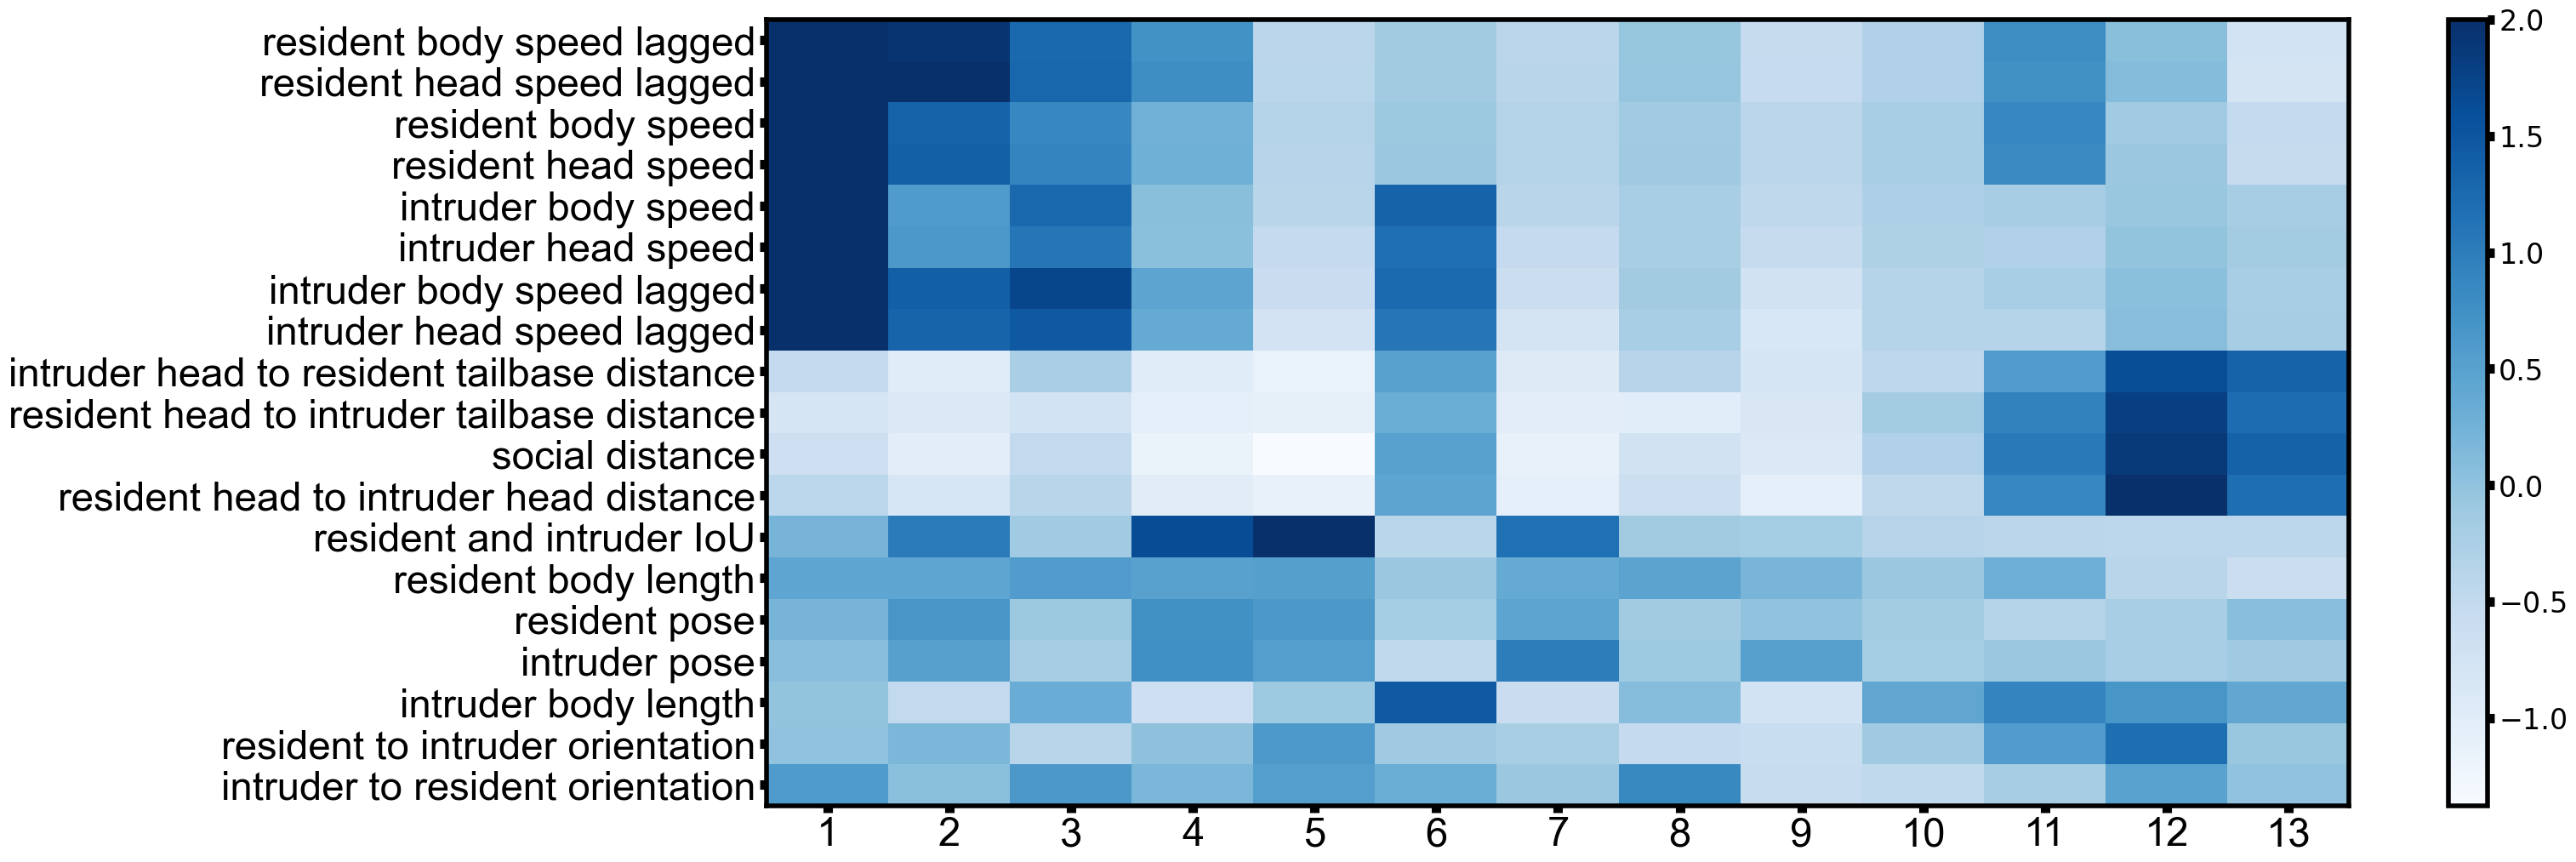

In [ ]:
# Feature color map; adapted to figure in ED2c

from scipy.cluster.hierarchy import dendrogram, linkage, leaves_list

feats3_descriptions = ['social distance', 'resident head to intruder head distance',
                       'resident head to intruder tailbase distance', 'intruder head to resident tailbase distance',
                       'resident to intruder orientation', 'intruder to resident orientation', 'resident body speed', 
                       'intruder body speed', 'resident head speed', 'intruder head speed', 'resident body speed lagged',
                       'intruder body speed lagged', 'resident head speed lagged', 'intruder head speed lagged', 'resident and intruder IoU',
                       'resident pose', 'intruder pose', 'resident body length', 'intruder body length']

# Perform hierarchical clustering
mean_features_by_cluster = np.nanmean(feats_by_cluster, axis=(2,3))
Z = linkage(mean_features_by_cluster.T, method='ward')  # Transpose to cluster columns

# Get the order of the leaves (clusters)
leaf_order = leaves_list(Z)

# Reorder the columns of the data matrix
reordered_data = mean_features_by_cluster[:, leaf_order]
reordered_feats = np.asarray(feats3_descriptions)[leaf_order]

# Plot heatmap with reordered columns
plt.figure(figsize=(30, 12))
plt.imshow(reordered_data.T, cmap='Blues', vmax=2, aspect='auto')
plt.yticks(np.arange(19), reordered_feats, fontsize=34, fontfamily='Arial');
plt.xticks(np.arange(13), np.arange(1,14), fontsize=34, fontfamily='Arial');
cbar = plt.colorbar()
cbar.ax.tick_params(labelsize=24)
plt.savefig('.\\figures\\clustered_features.svg', dpi=300)

In [ ]:
vmin_used = reordered_data.min()  # matplotlib's implicit default, made explicit
vmax_used = 2  # as specified in imshow()

sourceData_ED2c = pd.DataFrame(
    reordered_data.T,
    index=reordered_feats,
    columns=np.arange(1, 14)
)
sourceData_ED2c.index.name = 'feature'
sourceData_ED2c.columns.name = 'cluster'

sourceData_ED2c.to_csv('./sourceData/ED2c.csv')

# Colormap metadata as a separate small companion file — keeps the main
# matrix clean (no repeated constant columns across 19 feature rows) while
# still recording what's needed to reproduce the exact color scale.
pd.DataFrame({
    'cmap': ['Blues'],
    'vmin': [vmin_used],
    'vmax': [vmax_used],
}).to_csv('./sourceData/ED2c_colormap_params.csv', index=False)

### Comparing embeddings

In [1118]:
# Load UMAP data directly

from scipy.ndimage import gaussian_filter
from skimage.feature import peak_local_max
from skimage.segmentation import watershed
from matplotlib import colors
from mpl_toolkits.axes_grid1 import ImageGrid
from matplotlib.colors import ListedColormap
from matplotlib.cm import get_cmap

def open_sessions(path):
    with open(path, 'rb') as handle:
        feats = pickle.load(handle)
    return feats

def select_features(feats, feats_list):
    
    for feat_day in feats.keys():
        feats[feat_day] = feats[feat_day][feats_list]
        
    return feats

def map_density(X_embedded, bins=50, sigma=2.5, percentile=30, cm = 'nipy_spectral', watershed_line=True, wt=0):

    # Find local maxima as "seeds" for the watershed transform
    all_map_density, xe, ye = heatmap(X_embedded, bins=bins, sigma=sigma)
    density_cutoff = np.percentile(all_map_density, percentile)
    density_mask = all_map_density > density_cutoff
    local_maxes = peak_local_max(all_map_density, indices=False)
    local_maxes[np.logical_not(density_mask)] = False
    markers, n_peaks = scipy.ndimage.label(local_maxes)

    # Compute watershed transform
    
    labeled_map = watershed(-all_map_density, markers, watershed_line=False)
    labeled_map = labeled_map.astype('float64')
    
    labeled_map_viz = watershed(-all_map_density, markers, watershed_line=watershed_line)
    labeled_map_viz = labeled_map_viz.astype('float64')

    viz = all_map_density
    viz[labeled_map_viz==0]=wt
    plt.figure(figsize=(10,10))
    plt.imshow(all_map_density.T, cmap=cm,origin='lower')
    
    plt.axis('off')
    plt.show()
    
    ###
    
    plt.figure(figsize=(10,10))
    plt.imshow(labeled_map.T, cmap='rainbow',origin='lower')
    plt.axis('off')

    for i in np.unique(labeled_map.flatten()):
        x=np.mean(np.where(labeled_map==i)[0])
        y=np.mean(np.where(labeled_map==i)[1])
        plt.text(x,y,int(i),size=20)

    plt.show()
    
    return labeled_map, all_map_density, xe, ye, local_maxes

def heatmap(data, axlims=None, bins=100, normed=True, sigma=0.0):
    
    # Initial histogram
    heatmap, xedges, yedges = np.histogram2d(data[:,0], data[:, 1], bins=bins, range=axlims, normed=normed)
    
    # Convolve with Gaussian
    heatmap = gaussian_filter(heatmap, sigma=sigma)
    
    return heatmap, xedges, yedges

def embedding_labels(embeddings, labeled_map, xe, ye, bins=100):

    labels = {}

    map_shape=(bins,bins)
    xmin=min(xe)
    xmax=max(xe)
    ymin=min(ye)
    ymax=max(ye)

    for k, e in embeddings.items():
        
        def to_coords(xy):
            
            x = (xy[0] - xmin) / (xmax - xmin) * map_shape[0]
            y = (xy[1] - ymin) / (ymax - ymin) * map_shape[1]
            if x >= map_shape[0]:
                x = map_shape[0]-1
            if y >= map_shape[1]:
                y = map_shape[1]-1
            if x < 0:
                x=0
            if y < 0:
                y=0
            return int(x), int(y)

        labels[k] = np.array([labeled_map[to_coords(point)] for point in e])
        
    return labels

direct = 'C:\\Users\\FalknerLab\\Desktop\\UMAP_embeddings_behavior\\'

# Load pickle
with open(direct + 'umap_embeddings_unified.pickle', 'rb') as file:
    data = pickle.load(file)

Generating embedding figs

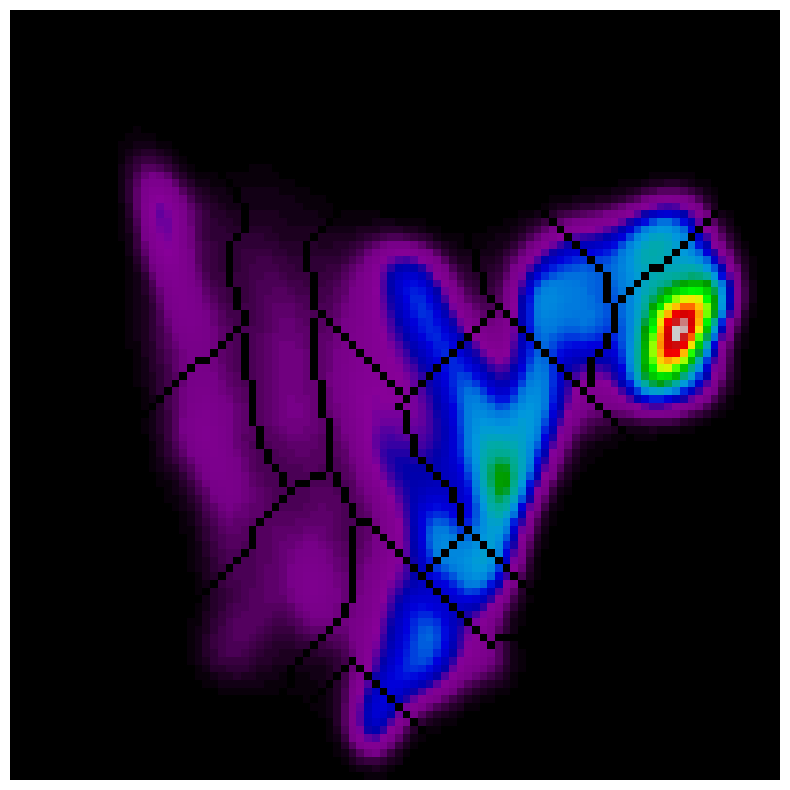

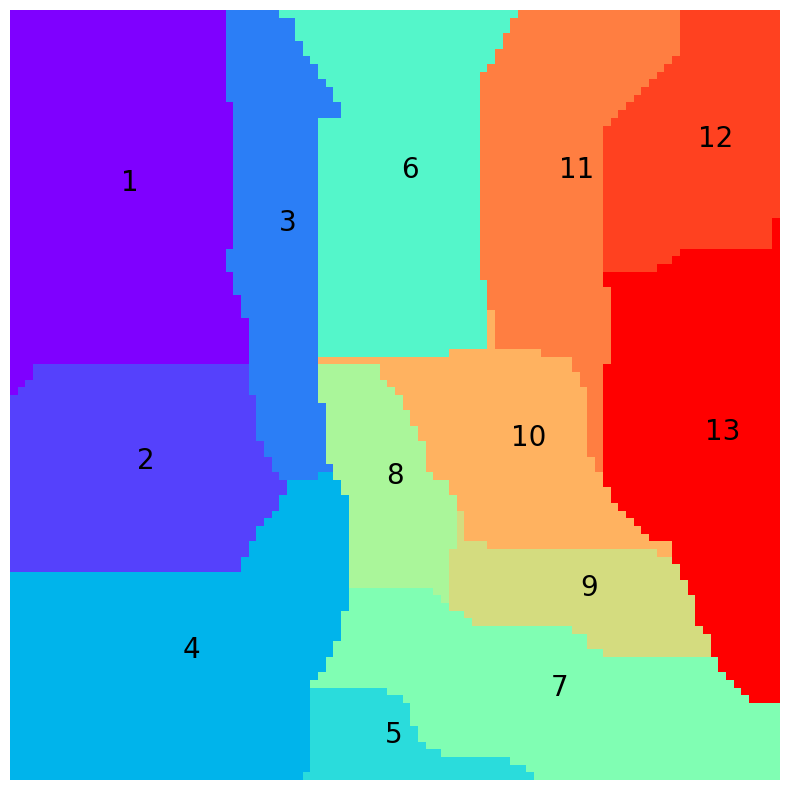

In [1119]:
# concatenate all embeddings
final_embs = []
for key in data.keys():
    final_embs.append(data[key])
final_embs = np.row_stack(final_embs)

# run watershed on concatenated embeddings
labeled_map, density, xe, ye, lmaxes = map_density(final_embs, bins=100, percentile=75, sigma=1.8)
labels = embedding_labels(data, labeled_map, xe, ye, bins=100)

# derive final label set
final_labels = []
for key in labels.keys():
    final_labels.append(labels[key])
final_labels = np.concatenate(final_labels)

Cluster   P(attack)   n_frames
  1       0.3739      416825
  2       0.3471      369512
  3       0.1139      360143
  4       0.2537      473276
  5       0.1302      304017
  6       0.0227      985233
  7       0.0430      1239980
  8       0.0338      1370678
  9       0.0288      674370
  10      0.0154      3310913
  11      0.0176      1339016
  12      0.0237      737730
  13      0.0131      4093200


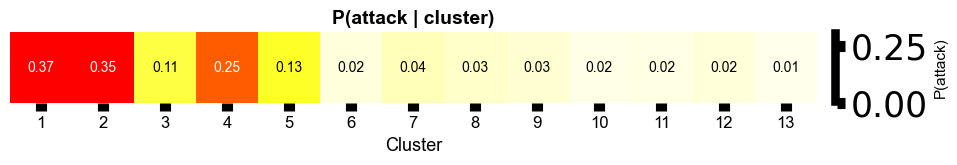

In [1127]:
import matplotlib.colors as mcolors

def compute_cluster_attack_probability(full_data, n_clusters=13):
    """
    Pool frames across all sessions. For each cluster c (1-indexed, 1..n_clusters),
    P(attack | cluster=c) = (# frames where cluster==c AND attack==1)
                            / (# frames where cluster==c)
    Frames where either series is NaN are excluded from both numerator and
    denominator for that frame.
    """
    numer = np.zeros(n_clusters)
    denom = np.zeros(n_clusters)

    for session, data in full_data.items():
        attack   = np.asarray(data['attack labels'], dtype=float)
        clusters = np.asarray(data['unsupervised labels'], dtype=float)

        valid = ~np.isnan(attack) & ~np.isnan(clusters)
        attack_v   = attack[valid]
        clusters_v = clusters[valid].astype(int)

        for c in range(1, n_clusters + 1):
            mask = clusters_v == c
            denom[c - 1] += mask.sum()
            numer[c - 1] += attack_v[mask].sum()

    with np.errstate(invalid='ignore', divide='ignore'):
        probs = np.where(denom > 0, numer / denom, np.nan)

    return probs, denom.astype(int)


probs, n_frames_per_cluster = compute_cluster_attack_probability(full_data, n_clusters=13)

print('Cluster   P(attack)   n_frames')
for c in range(13):
    p_str = f'{probs[c]:.4f}' if not np.isnan(probs[c]) else 'n/a'
    print(f'  {c+1:<7} {p_str:<10}  {n_frames_per_cluster[c]}')

# ── Heatmap: white (0) -> yellow -> red (high) ────────────────────────────────
custom_cmap = mcolors.LinearSegmentedColormap.from_list(
    'white_yellow_red', ['white', 'yellow', 'red']
)

fig, ax = plt.subplots(figsize=(10, 2.2))
im = ax.imshow(probs.reshape(1, -1), cmap=custom_cmap, vmin=0, vmax=0.31, aspect='auto')

ax.set_xticks(np.arange(13))
ax.set_xticklabels([f'{c}' for c in range(1, 14)], fontsize=12, fontfamily='Arial')
ax.set_yticks([])
ax.set_xlabel('Cluster', fontsize=13, fontfamily='Arial')
ax.set_title('P(attack | cluster)', fontsize=14, fontfamily='Arial', fontweight='bold')

# annotate each cell with its probability
for c in range(13):
    if not np.isnan(probs[c]):
        ax.text(c, 0, f'{probs[c]:.2f}', ha='center', va='center',
                fontsize=10, fontfamily='Arial',
                color='black' if probs[c] < np.nanmax(probs) * 0.6 else 'white')

cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.05, pad=0.02)
cbar.set_label('P(attack)', fontsize=11, fontfamily='Arial')

for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
# plt.savefig('.\\figures\\fig1\\ED1f_cluster_attack_probability_heatmap.svg', dpi=300, bbox_inches='tight')
plt.show()

# ── Source data export: ED1f ──────────────────────────────────────────────────
os.makedirs('./sourceData', exist_ok=True)

sourceData_ED1f = pd.DataFrame({
    'cluster': np.arange(1, 14),
    'p_attack': probs,
    'n_frames': n_frames_per_cluster,
})

sourceData_ED1f.to_csv('./sourceData/ED1f.csv', index=False)

In [ ]:
# run embedding in high-res just for viz; the actual clusters are derived from the earlier representation

# concatenate all embeddings
final_embs = []
for key in data.keys():
    final_embs.append(data[key])
final_embs = np.row_stack(final_embs)

# run watershed on concatenated embeddings
labeled_map, density, xe, ye, lmaxes = map_density(final_embs, bins=500, percentile=70, sigma=9.7) # adjust settings to match the smaller embedding
labels = embedding_labels(data, labeled_map, xe, ye, bins=500)
plt.close()

# derive final label set
final_labels = []
for key in labels.keys():
    final_labels.append(labels[key])
final_labels = np.concatenate(final_labels)

In [ ]:
# run only once; edges are precomputed and saved to pickle for faster loading
edges = pd.read_pickle('edges.pickle')
def plot_edges(edges, axis):
    for e in edges:
        x, y = zip(*e)
        grid[axis].plot(y, x, color='black')

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_38108\2005074369.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  orig_cmap = get_cmap('rainbow', 126)


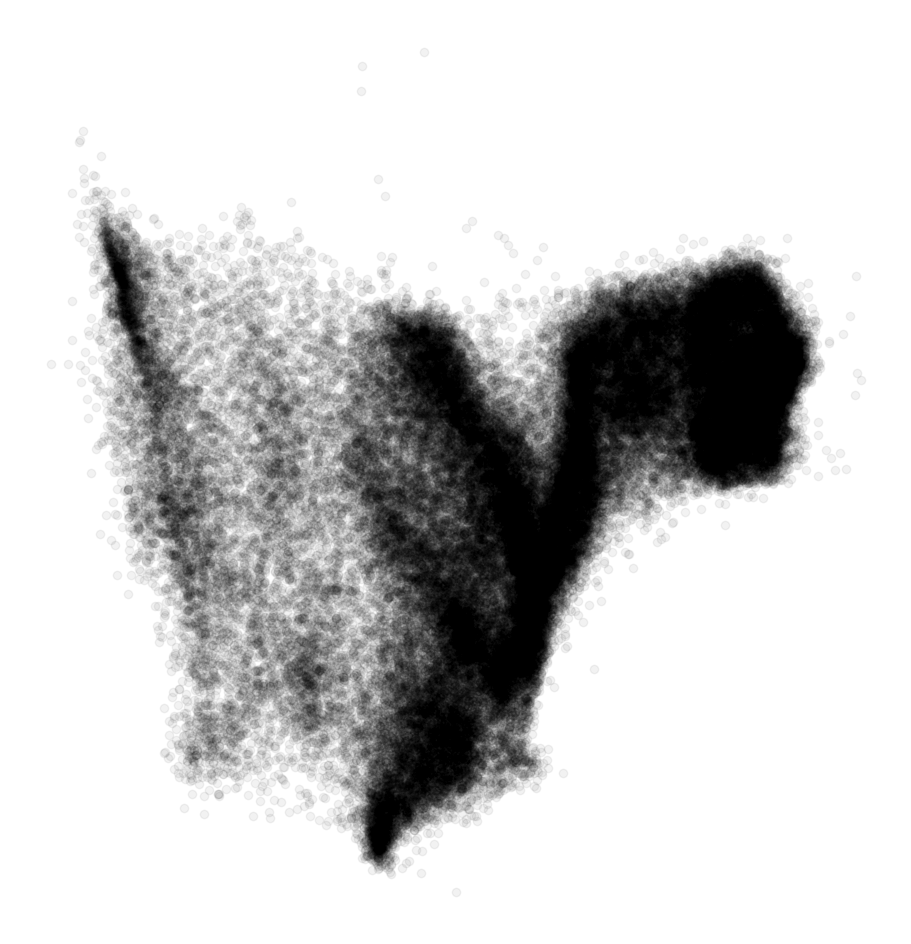

<Figure size 1000x1000 with 0 Axes>

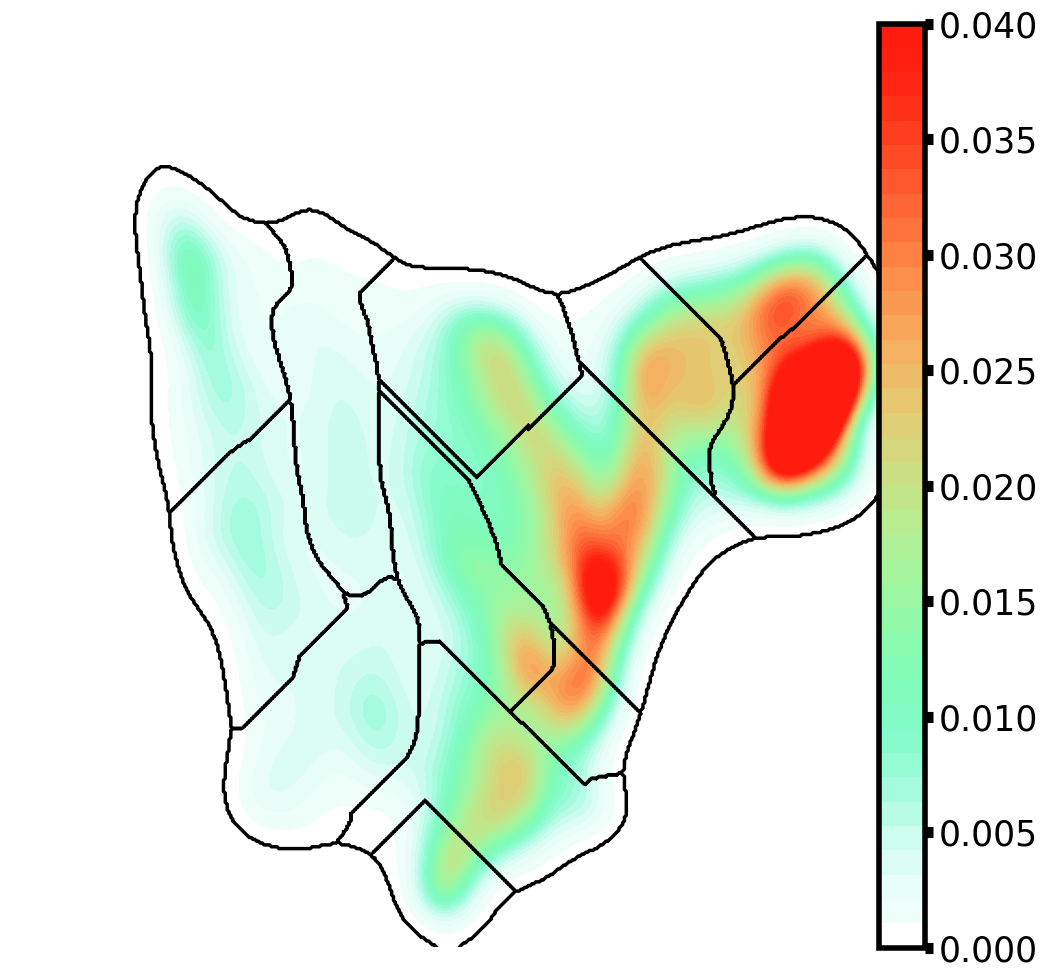

In [ ]:
# Generate embedding plots

# define colormap
orig_cmap = get_cmap('rainbow', 126)
warm_colors = orig_cmap(np.linspace(0.4, 1, 32))  # Adjust 0.2 and 0.6 based on the colormap's warm color range
white_rows = np.array([1, 1, 1, 1] * 5).reshape(5, 4)  # 5 rows of RGBA white
warm_colors = np.vstack((white_rows, np.vstack(warm_colors)))
for col in np.arange(4):
    warm_colors[:, col] = gaussian_filter(warm_colors[:, col], sigma=3)
warm_colors = np.vstack((np.array([1, 1, 1, 1]).reshape(1, 4), np.vstack(warm_colors)))
new_cmap = ListedColormap(warm_colors)

# plot raw embedding for figure-making
plt.figure(figsize=(11.5, 12))
plt.scatter(final_embs[:, 0][::150], final_embs[:, 1][::150], color='black', alpha=0.05)
plt.axis('off')
# plt.savefig('.\\retreat_figs\\embedding_blank.png', dpi=300, bbox_inches='tight')

# plot watershed embedding
plt.figure(figsize=(10,10))
final_density, _, _ = heatmap(final_embs, bins=500, sigma=10)
fig = plt.figure(figsize=(15,12))
grid = ImageGrid(fig, 111,
                nrows_ncols = (1,1),
                axes_pad = 0.05, 
                )
im = grid[0].imshow(final_density.T, cmap=new_cmap ,origin='lower', vmax=0.04)
grid[0].axis('off')
plt.colorbar(im)
plot_edges(edges, axis=0)
# plt.savefig('.\\GRC2024_figs\\watershed_embedding.svg', dpi=300, bbox_inches='tight')

In [ ]:
# Get source data for above
# Matches what's actually rendered: final_embs subsampled every 150th point,
# not the full embedding array. 
sourceData_1j_embedding = pd.DataFrame({
    'dim1': final_embs[:, 0][::150],
    'dim2': final_embs[:, 1][::150],
})
sourceData_1j_embedding.to_csv('./sourceData/1j_embedding.csv', index=False)

# ── 1j_density — filtering + clustering (watershed density map) ────────────
final_density, xedges, yedges = heatmap(final_embs, bins=500, sigma=10)

sourceData_1j_density = pd.DataFrame(
    final_density.T,
    index=pd.Index(yedges[:-1], name='dim2_bin_start'),
    columns=pd.Index(xedges[:-1], name='dim1_bin_start')
)
sourceData_1j_density.to_csv('./sourceData/1j_density.csv')

In [ ]:
# Run for percentile filtering later

from matplotlib.colors import ListedColormap
from scipy.ndimage import gaussian_filter

# ── Generate embeddings ────────────────────────────────────────────────────────
axlims = [
    [final_embs[:, 0].min(), final_embs[:, 0].max()],
    [final_embs[:, 1].min(), final_embs[:, 1].max()]
]
bins  = 500
sigma = 10

agg_embs = np.row_stack([
    data[key] for key in data.keys()
    if '_mCD1' in key and not any(a in key for a in ['29L', '30R2'])
])
obs_embs = np.row_stack([data[key] for key in data.keys() if '_OBSmCD1' in key])
non_embs = np.row_stack([data[key] for key in data.keys() if 'toyCD1'   in key])

agg_density, _, _ = heatmap(agg_embs, bins=bins, sigma=sigma, axlims=axlims)
obs_density, _, _ = heatmap(obs_embs, bins=bins, sigma=sigma, axlims=axlims)
non_density, _, _ = heatmap(non_embs, bins=bins, sigma=sigma, axlims=axlims)

# ── Compute shared percentile-based vmax ──────────────────────────────────────
percentile = 90  # adjust this to taste — try 95 or 99.5 if needed

# Stack all densities and compute shared vmax from combined distribution
all_densities  = np.concatenate([
    agg_density[agg_density > 0],
    obs_density[obs_density > 0],
    non_density[non_density > 0],
])
vmin  = 0
vmax  = np.nanpercentile(all_densities, percentile)
print(f'Shared vmax at p{percentile}: {vmax:.6f}')

Shared vmax at p90: 0.019829


C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_38108\1128865205.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  orig_cmap = get_cmap('rainbow', 126)


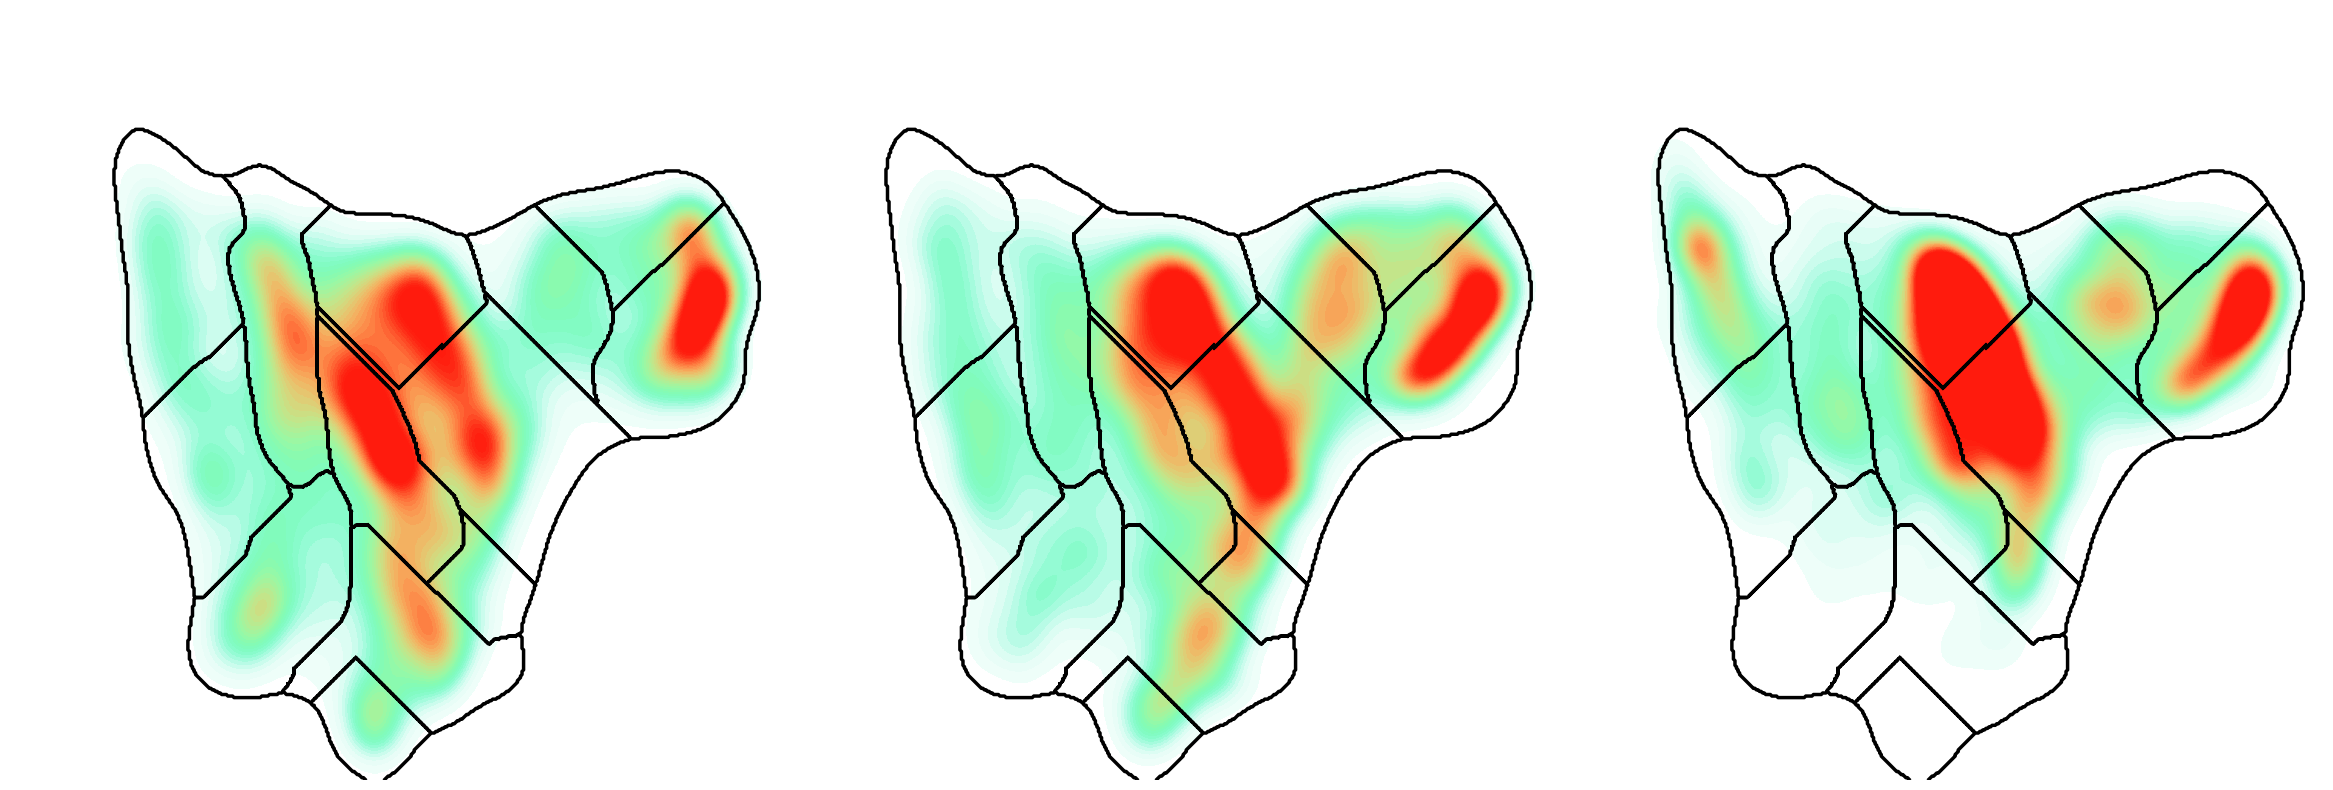

In [ ]:
# generating individual heatmaps for hard fight

# set up params for heatmaps
range = [[final_embs[:,0].min(), final_embs[:,0].max()], [final_embs[:,1].min(), final_embs[:,1].max()]]
bins = 500
sigma = 11

# define colormap
orig_cmap = get_cmap('rainbow', 126)
warm_colors = orig_cmap(np.linspace(0.4, 1, 32))  # Adjust 0.2 and 0.6 based on the colormap's warm color range
white_rows = np.array([1, 1, 1, 1] * 5).reshape(5, 4)  # 5 rows of RGBA white
warm_colors = np.vstack((white_rows, np.vstack(warm_colors)))
for col in np.arange(4):
    warm_colors[:, col] = gaussian_filter(warm_colors[:, col], sigma=3)
warm_colors = np.vstack((np.array([1, 1, 1, 1]).reshape(1, 4), np.vstack(warm_colors)))
new_cmap = ListedColormap(warm_colors)

# generate embeddings
agg_embs = []
for key in [x for x in list(data.keys()) if '_mCD1' in x if key not in ['29L', '30R2']] :
    agg_embs.append(data[key])
agg_embs = np.row_stack(agg_embs)
agg_density, _, _ = heatmap(agg_embs, bins=bins, sigma=sigma, axlims=range)

obs_embs = []
for key in [x for x in list(data.keys()) if '_OBSmCD1' in x] :
    obs_embs.append(data[key])
obs_embs = np.row_stack(obs_embs)
obs_density, _, _ = heatmap(obs_embs, bins=bins, sigma=sigma, axlims=range)

non_embs = []
for key in [x for x in list(data.keys()) if 'toyCD1' in x] :
    non_embs.append(data[key])
non_embs = np.row_stack(non_embs)
non_density, _, _ = heatmap(non_embs, bins=bins, sigma=sigma, axlims=range)

xpo_embs = []
for key in [x for x in list(data.keys()) if 'xpoCD1' in x] :
    xpo_embs.append(data[key])
xpo_embs = np.row_stack(xpo_embs)
xpo_density, _, _ = heatmap(xpo_embs, bins=bins, sigma=sigma, axlims=range)

# putting everything together
fig = plt.figure(figsize=(30,10))
grid = ImageGrid(fig, 111,
                nrows_ncols = (1,3),
                )

im = grid[0].imshow(agg_density.T, cmap=new_cmap,origin='lower', vmin=0, vmax=0.032)
grid[0].axis('off')
plot_edges(edges, axis=0)

grid[1].imshow(obs_density.T, cmap=new_cmap,origin='lower', vmin=0, vmax=0.032)
grid[1].axis('off')
plot_edges(edges, axis=1)

grid[2].imshow(xpo_density.T, cmap=new_cmap,origin='lower', vmin=0, vmax=0.032)
grid[2].axis('off')
plot_edges(edges, axis=2)

# grid[3].imshow(non_density.T, cmap=new_cmap,origin='lower', vmin=0, vmax=0.032)
# grid[3].axis('off')
# plot_edges(edges, axis=3)

# fig.colorbar(im)

cax = grid.cbar_axes[0]
axis = cax.axis[cax.orientation]
axis.label.set_rotation(270)
# plt.savefig('.\\figures\\fig1\\agg_obs_non_density.svg', dpi=300, bbox_inches='tight')

In [ ]:
# Get source data
agg_density, agg_xedges, agg_yedges = heatmap(agg_embs, bins=bins, sigma=sigma, axlims=range)
obs_density, obs_xedges, obs_yedges = heatmap(obs_embs, bins=bins, sigma=sigma, axlims=range)
non_density, non_xedges, non_yedges = heatmap(non_embs, bins=bins, sigma=sigma, axlims=range)
xpo_density, xpo_xedges, xpo_yedges = heatmap(xpo_embs, bins=bins, sigma=sigma, axlims=range)

assert np.allclose(agg_xedges, obs_xedges) and np.allclose(agg_xedges, xpo_xedges), \
    'Bin edges differ across groups — density maps not on a shared grid'

def export_density(density, xedges, yedges, group_label):
    df = pd.DataFrame(
        density.T,
        index=pd.Index(yedges[:-1], name='dim2_bin_start'),
        columns=pd.Index(xedges[:-1], name='dim1_bin_start')
    )
    df.to_csv(f'./sourceData/1k_density_{group_label}.csv')

export_density(agg_density, agg_xedges, agg_yedges, 'EXP')
export_density(obs_density, obs_xedges, obs_yedges, 'OBS')
export_density(xpo_density, xpo_xedges, xpo_yedges, 'XPO')

In [ ]:
# Rerun original embedding used for analysis

# concatenate all embeddings
final_embs = []
for key in data.keys():
    final_embs.append(data[key])
final_embs = np.row_stack(final_embs)

# run watershed on concatenated embeddings
labeled_map, density, xe, ye, lmaxes = map_density(final_embs, bins=100, percentile=75, sigma=1.8)
labels = embedding_labels(data, labeled_map, xe, ye, bins=100)

# derive final label set
final_labels = []
for key in labels.keys():
    final_labels.append(labels[key])
final_labels = np.concatenate(final_labels)

AGG cluster occupancy: [0.0371 0.0421 0.1132 0.0624 0.0173 0.1144 0.0729 0.1976 0.0118 0.1418
 0.0463 0.0352 0.1079]
OBS cluster occupancy: [0.0324 0.0441 0.052  0.0359 0.0138 0.1518 0.0557 0.1049 0.0235 0.2253
 0.087  0.0324 0.1414]
NON cluster occupancy: [0.054  0.0215 0.0388 0.01   0.0021 0.2046 0.0213 0.0575 0.0192 0.2658
 0.035  0.017  0.2531]


C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_38108\3362477834.py:109: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


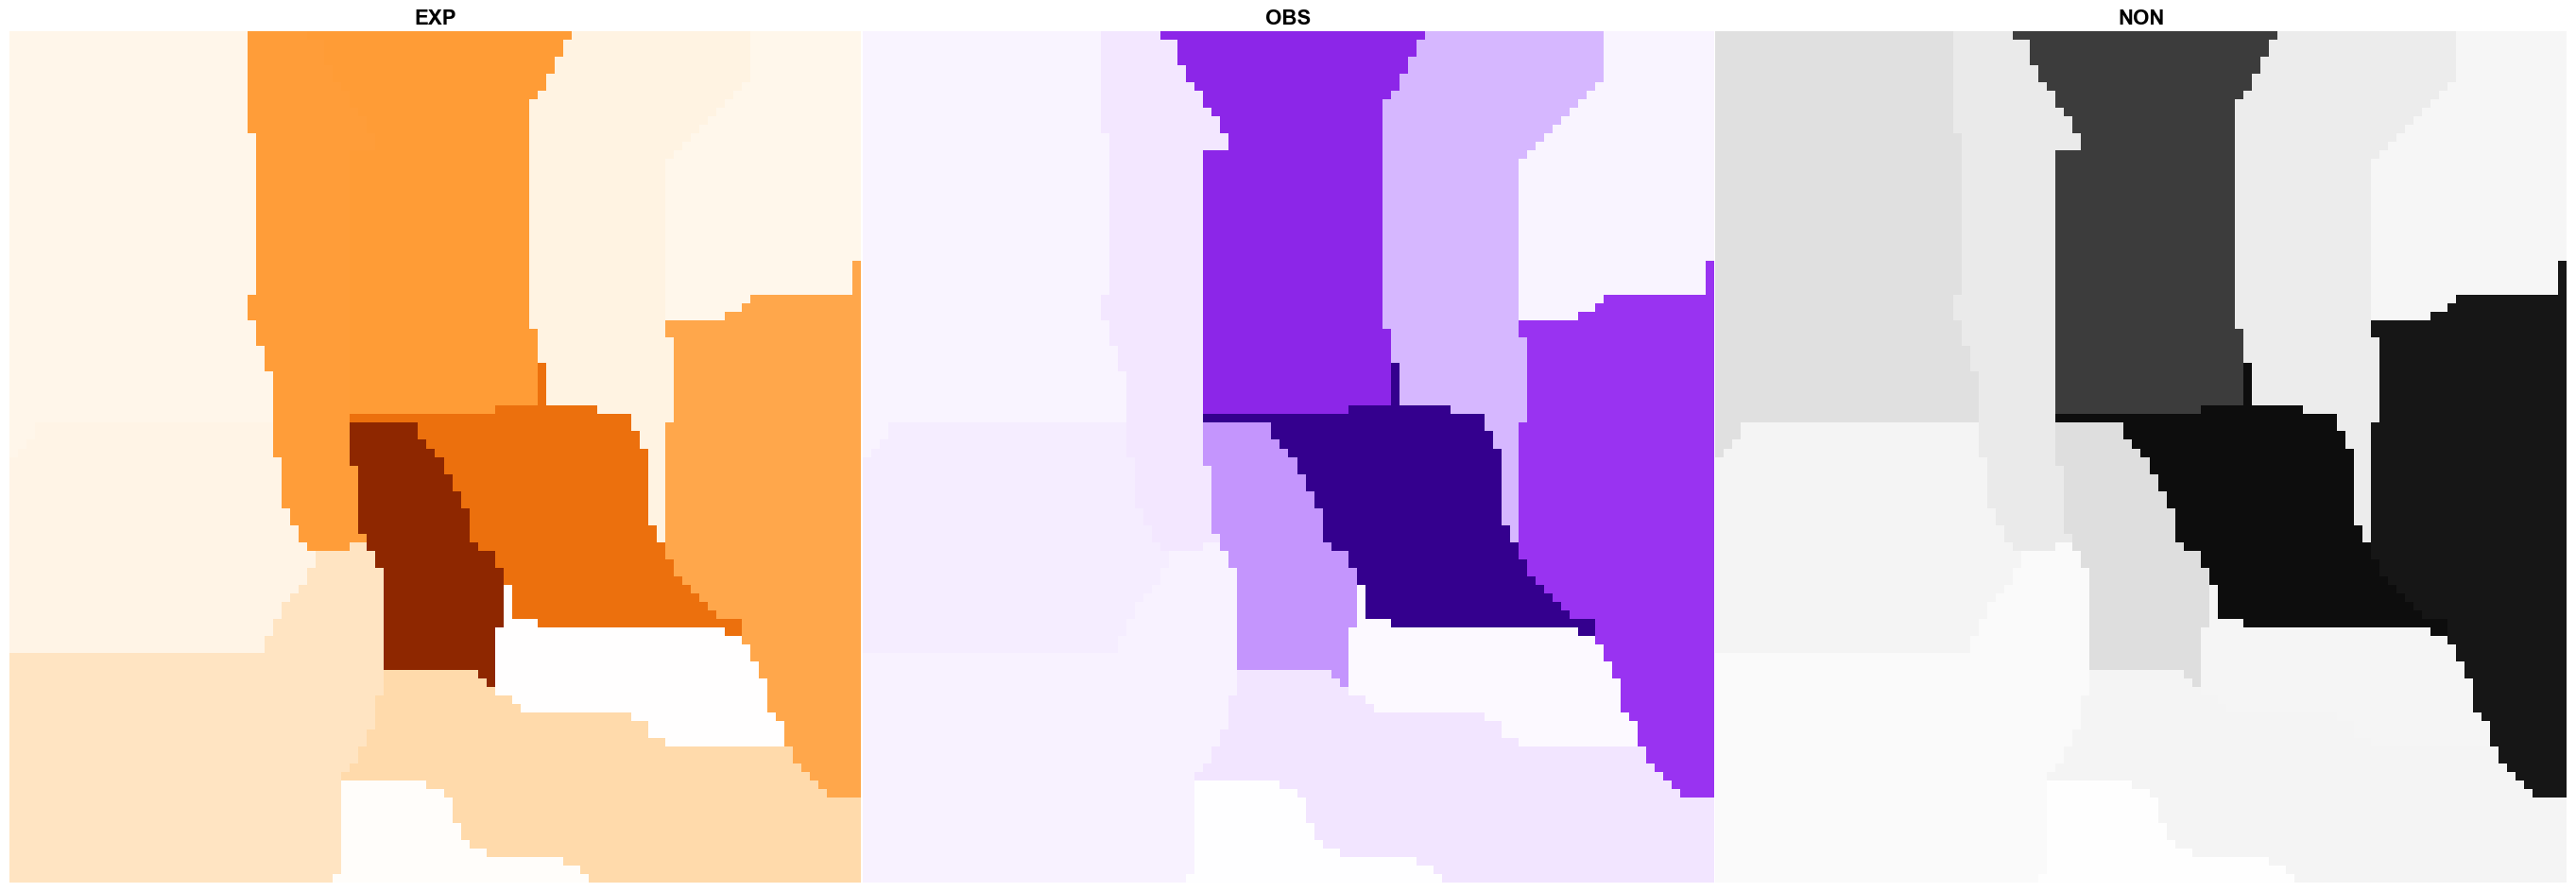

In [ ]:
def compute_cluster_occupancy(labels_dict, group_keys, n_clusters=13):
    """
    For a set of session keys belonging to one group,
    compute the fraction of frames in each cluster.
    Returns array of shape (n_clusters,) summing to ~1.
    """
    all_labels = np.concatenate([labels_dict[k] for k in group_keys])
    total      = len(all_labels)
    occupancy  = np.zeros(n_clusters + 1)  # +1 because clusters are 1-indexed
    for c in np.arange(1, n_clusters + 1):
        occupancy[c] = np.sum(all_labels == c) / total
    return occupancy  # index 0 unused, 1-13 are the clusters

def make_flat_cluster_image(labeled_map, occupancy, waypoints_rgb,
                             n_colors=256, smooth_sigma=2):
    """
    Render labeled_map as a flat colored image where each cluster's
    fill color is sampled from a palette scaled by its occupancy value.
    Returns RGBA image of same spatial dimensions as labeled_map.
    """
    # Build palette from waypoints
    pts   = np.array([[r, g, b, 1.0] for r, g, b in waypoints_rgb])
    x_in  = np.linspace(0, 1, len(pts))
    x_out = np.linspace(0, 1, n_colors)
    palette = np.stack([
        np.interp(x_out, x_in, pts[:, ch])
        for ch in np.arange(4)
    ], axis=1)
    for ch in np.arange(4):
        palette[:, ch] = gaussian_filter(palette[:, ch], sigma=smooth_sigma)
        palette[:, ch] = np.clip(palette[:, ch], 0, 1)

    # Normalize occupancy to [0, 1] across clusters for color mapping
    occ_vals  = occupancy[1:]  # clusters 1-13
    occ_norm  = (occ_vals - occ_vals.min()) / (occ_vals.max() - occ_vals.min() + 1e-10)

    # Build RGBA image
    h, w     = labeled_map.shape
    img_rgba = np.ones((h, w, 4))  # default white

    for c_idx, c in enumerate(np.arange(1, 14)):
        mask        = labeled_map == c
        color_idx   = int(occ_norm[c_idx] * (n_colors - 1))
        color       = palette[color_idx]
        img_rgba[mask] = color

    return img_rgba


# ── Define group keys ──────────────────────────────────────────────────────────
agg_keys = [k for k in labels.keys() if '_mCD1'    in k and '29L'  not in k and '30R2' not in k]
obs_keys = [k for k in labels.keys() if '_OBSmCD1' in k]
non_keys = [k for k in labels.keys() if 'toyCD1'   in k]

# ── Compute cluster occupancy per group ───────────────────────────────────────
occ_agg = compute_cluster_occupancy(labels, agg_keys)
occ_obs = compute_cluster_occupancy(labels, obs_keys)
occ_non = compute_cluster_occupancy(labels, non_keys)

print('AGG cluster occupancy:', occ_agg[1:].round(4))
print('OBS cluster occupancy:', occ_obs[1:].round(4))
print('NON cluster occupancy:', occ_non[1:].round(4))

# ── Waypoints (reuse from earlier) ────────────────────────────────────────────
waypoints_agg = [
    (1.00, 1.00, 1.00),
    (1.00, 0.95, 0.88),
    (1.00, 0.80, 0.55),
    (1.00, 0.55, 0.10),
    (0.85, 0.33, 0.00),
    (0.55, 0.15, 0.00),
]
waypoints_obs = [
    (1.00, 1.00, 1.00),
    (0.95, 0.90, 1.00),
    (0.80, 0.65, 1.00),
    (0.60, 0.20, 0.95),
    (0.40, 0.00, 0.80),
    (0.20, 0.00, 0.55),
]
waypoints_non = [
    (1.00, 1.00, 1.00),
    (0.88, 0.88, 0.88),
    (0.65, 0.65, 0.65),
    (0.40, 0.40, 0.40),
    (0.20, 0.20, 0.20),
    (0.05, 0.05, 0.05),
]

# ── Render flat cluster images ─────────────────────────────────────────────────
img_agg = make_flat_cluster_image(labeled_map, occ_agg, waypoints_agg)
img_obs = make_flat_cluster_image(labeled_map, occ_obs, waypoints_obs)
img_non = make_flat_cluster_image(labeled_map, occ_non, waypoints_non)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig  = plt.figure(figsize=(30, 10))
grid = ImageGrid(fig, 111, nrows_ncols=(1, 3))

for ax, img, title, axis_idx in [
    (grid[0], img_agg, 'EXP', 0),
    (grid[1], img_obs, 'OBS', 1),
    (grid[2], img_non, 'NON', 2),
]:
    ax.imshow(img.transpose(1, 0, 2), origin='lower')
    ax.axis('off')
    ax.set_title(title, fontsize=16, fontweight='bold', fontfamily='Arial')
    # plot_edges(edges, axis=axis_idx)

plt.tight_layout()
# plt.savefig('.\\figures\\fig1\\flat_cluster_maps.svg', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_38108\3517982153.py:149: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


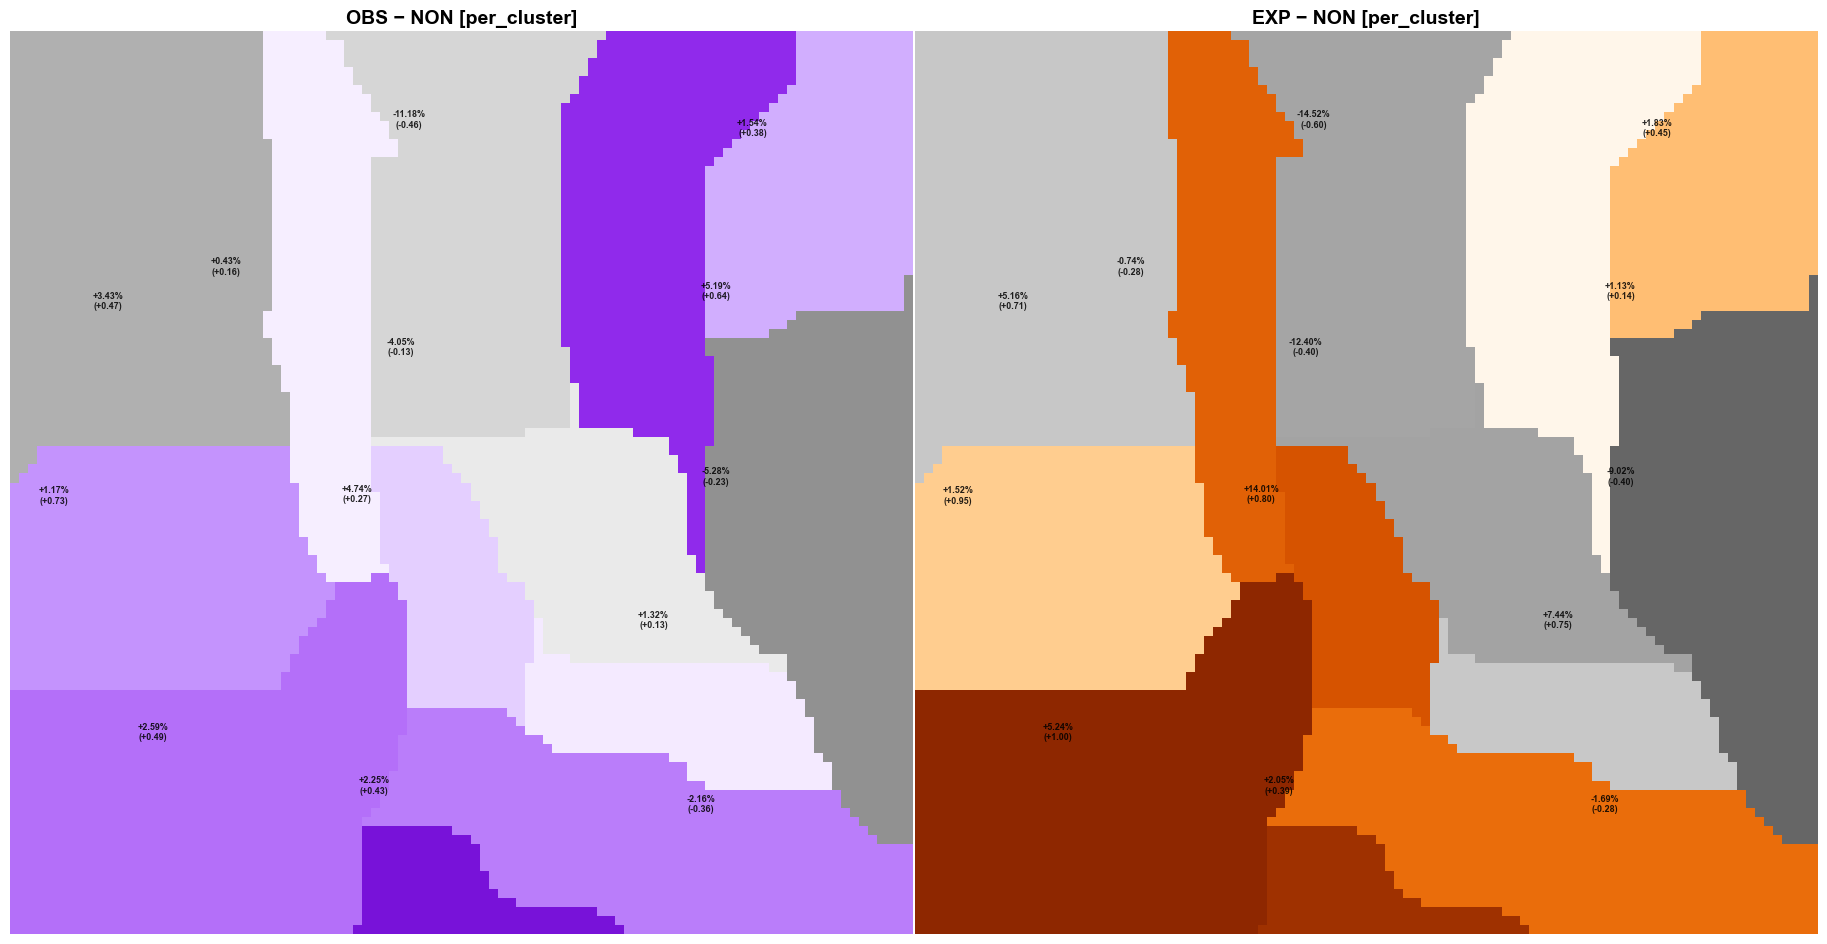

In [ ]:
# Generate difference maps

def compute_cluster_occupancy(labels_dict, group_keys, n_clusters=13):
    """
    For a set of session keys belonging to one group,
    compute the fraction of frames in each cluster.
    Returns array of shape (n_clusters,) summing to ~1.
    """
    all_labels = np.concatenate([labels_dict[k] for k in group_keys])
    total      = len(all_labels)
    occupancy  = np.zeros(n_clusters + 1)  # +1 because clusters are 1-indexed
    for c in np.arange(1, n_clusters + 1):
        occupancy[c] = np.sum(all_labels == c) / total
    return occupancy  # index 0 unused, 1-13 are the clusters

def make_flat_difference_image(labeled_map, occ_a, occ_b,
                                neg_waypoints_rgb, pos_waypoints_rgb,
                                n_colors=256, smooth_sigma=2,
                                normalization='per_cluster',
                                occ_all_groups=None,
                                shared_abs_max=None):
    def build_half_palette(waypoints, n):
        pts   = np.array([[r, g, b, 1.0] for r, g, b in waypoints])
        x_in  = np.linspace(0, 1, len(pts))
        x_out = np.linspace(0, 1, n)
        pal   = np.stack([
            np.interp(x_out, x_in, pts[:, ch])
            for ch in np.arange(4)
        ], axis=1)
        for ch in np.arange(4):
            pal[:, ch] = gaussian_filter(pal[:, ch], sigma=smooth_sigma)
            pal[:, ch] = np.clip(pal[:, ch], 0, 1)
        return pal

    neg_palette = build_half_palette(neg_waypoints_rgb, n_colors)
    pos_palette = build_half_palette(pos_waypoints_rgb, n_colors)

    diff = occ_a[1:] - occ_b[1:]

    if normalization == 'global':
        abs_max   = shared_abs_max if shared_abs_max is not None \
                    else np.abs(diff).max() + 1e-10
        diff_norm = diff / abs_max

    elif normalization == 'per_cluster':
        if occ_all_groups is not None:
            grand_mean = np.mean(
                np.stack([o[1:] for o in occ_all_groups], axis=0), axis=0)
        else:
            grand_mean = (occ_a[1:] + occ_b[1:]) / 2.0
        rel_diff  = diff / (grand_mean + 1e-10)
        abs_max   = shared_abs_max if shared_abs_max is not None \
                    else np.abs(rel_diff).max() + 1e-10
        diff_norm = rel_diff / abs_max

    elif normalization == 'per_cluster_abs':
        per_abs   = np.abs(diff) + 1e-10
        diff_norm = diff / per_abs

    else:
        raise ValueError(f'Unknown normalization: {normalization}')

    h, w     = labeled_map.shape
    img_rgba = np.ones((h, w, 4))

    for c_idx, c in enumerate(np.arange(1, 14)):
        mask = labeled_map == c
        d    = np.clip(diff_norm[c_idx], -1, 1)
        if d >= 0:
            color_idx = int(d * (n_colors - 1))
            color     = pos_palette[color_idx]
        else:
            color_idx = int((1 + d) * (n_colors - 1))
            color     = neg_palette[color_idx]
        img_rgba[mask] = color

    return img_rgba, diff, diff_norm

# ── Cluster occupancy (unchanged) ───────────────────────────────────────────
occ_agg = compute_cluster_occupancy(labels, agg_keys)
occ_obs = compute_cluster_occupancy(labels, obs_keys)
occ_non = compute_cluster_occupancy(labels, non_keys)

all_occs   = [occ_agg, occ_obs, occ_non]
grand_mean = np.mean(np.stack([o[1:] for o in all_occs], axis=0), axis=0)

diff_obs_non_raw = occ_obs[1:] - occ_non[1:]
diff_agg_non_raw = occ_agg[1:] - occ_non[1:]

obs_non_colors = dict(
    neg_waypoints_rgb=[
        (0.05, 0.05, 0.05), (0.20, 0.20, 0.20), (0.40, 0.40, 0.40),
        (0.65, 0.65, 0.65), (0.88, 0.88, 0.88), (1.00, 1.00, 1.00),
    ],
    pos_waypoints_rgb=[
        (1.00, 1.00, 1.00), (0.95, 0.90, 1.00), (0.80, 0.65, 1.00),
        (0.60, 0.20, 0.95), (0.40, 0.00, 0.80), (0.20, 0.00, 0.55),
    ],
)
agg_non_colors = dict(
    neg_waypoints_rgb=[
        (0.05, 0.05, 0.05), (0.20, 0.20, 0.20), (0.40, 0.40, 0.40),
        (0.65, 0.65, 0.65), (0.88, 0.88, 0.88), (1.00, 1.00, 1.00),
    ],
    pos_waypoints_rgb=[
        (1.00, 1.00, 1.00), (1.00, 0.95, 0.88), (1.00, 0.80, 0.55),
        (1.00, 0.55, 0.10), (0.85, 0.33, 0.00), (0.55, 0.15, 0.00),
    ],
)

norm_method = 'per_cluster'
shared_abs_max = max(
    np.abs(diff_obs_non_raw / (grand_mean + 1e-10)).max(),
    np.abs(diff_agg_non_raw / (grand_mean + 1e-10)).max(),
) + 1e-10

img_diff_obs_non, diff_obs_non, diff_norm_obs_non = make_flat_difference_image(
    labeled_map, occ_obs, occ_non, **obs_non_colors,
    normalization=norm_method, occ_all_groups=all_occs,
    shared_abs_max=shared_abs_max,
)
img_diff_agg_non, diff_agg_non, diff_norm_agg_non = make_flat_difference_image(
    labeled_map, occ_agg, occ_non, **agg_non_colors,
    normalization=norm_method, occ_all_groups=all_occs,
    shared_abs_max=shared_abs_max,
)

fig  = plt.figure(figsize=(20, 10))
grid = ImageGrid(fig, 111, nrows_ncols=(1, 2))

for ax, img, diff_vals, diff_norm_vals, title in [
    (grid[0], img_diff_obs_non, diff_obs_non, diff_norm_obs_non, 'OBS − NON'),
    (grid[1], img_diff_agg_non, diff_agg_non, diff_norm_agg_non, 'EXP − NON'),
]:
    ax.imshow(img.transpose(1, 0, 2), origin='lower')
    ax.axis('off')
    ax.set_title(f'{title} [{norm_method}]',
                 fontsize=14, fontweight='bold', fontfamily='Arial')

    for c_idx, c in enumerate(np.arange(1, 14)):
        x = np.mean(np.where(labeled_map == c)[0])
        y = np.mean(np.where(labeled_map == c)[1])
        ax.text(y, x,
                f'{diff_vals[c_idx]*100:+.2f}%\n({diff_norm_vals[c_idx]:+.2f})',
                ha='center', va='center', fontsize=6.5,
                fontweight='bold', fontfamily='Arial',
                color='black', alpha=0.85)

plt.tight_layout()
# plt.savefig('.\\figures\\fig1\\flat_diff_per_cluster.svg',
#             dpi=300, bbox_inches='tight')
plt.show()

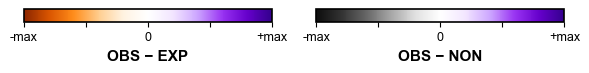

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.colorbar as mcolorbar
import matplotlib.cm as cm
from matplotlib.colors import Normalize

fig, axes = plt.subplots(1, 2, figsize=(6, 2))

for ax, neg_waypoints, pos_waypoints, title in [
    (axes[0],
     [(0.55,0.15,0.00),(0.85,0.33,0.00),(1.00,0.55,0.10),
      (1.00,0.80,0.55),(1.00,0.95,0.88),(1.00,1.00,1.00)],
     [(1.00,1.00,1.00),(0.95,0.90,1.00),(0.80,0.65,1.00),
      (0.60,0.20,0.95),(0.40,0.00,0.80),(0.20,0.00,0.55)],
     'OBS − EXP'),
    (axes[1],
     [(0.05,0.05,0.05),(0.20,0.20,0.20),(0.40,0.40,0.40),
      (0.65,0.65,0.65),(0.88,0.88,0.88),(1.00,1.00,1.00)],
     [(1.00,1.00,1.00),(0.95,0.90,1.00),(0.80,0.65,1.00),
      (0.60,0.20,0.95),(0.40,0.00,0.80),(0.20,0.00,0.55)],
     'OBS − NON'),
]:
    # Build full diverging palette (neg half + pos half)
    def build_half(waypoints, n=128):
        pts   = np.array([[r, g, b, 1.0] for r, g, b in waypoints])
        x_in  = np.linspace(0, 1, len(pts))
        x_out = np.linspace(0, 1, n)
        pal   = np.stack([np.interp(x_out, x_in, pts[:, ch])
                          for ch in np.arange(4)], axis=1)
        for ch in np.arange(4):
            pal[:, ch] = gaussian_filter(pal[:, ch], sigma=2)
            pal[:, ch] = np.clip(pal[:, ch], 0, 1)
        return pal

    neg_pal  = build_half(neg_waypoints)
    pos_pal  = build_half(pos_waypoints)
    full_pal = np.vstack([neg_pal, pos_pal])
    cmap     = ListedColormap(full_pal)

    norm = Normalize(vmin=-1, vmax=1)
    sm   = cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])

    cbar = fig.colorbar(sm, ax=ax, orientation='horizontal',
                        fraction=0.8, pad=0.05)
    cbar.set_label(title, fontsize=11, fontfamily='Arial', fontweight='bold')
    cbar.set_ticks([-1, -0.5, 0, 0.5, 1])
    cbar.set_ticklabels(['-max', '', '0', '', '+max'],
                        fontsize=9, fontfamily='Arial')
    cbar.outline.set_linewidth(1.2)
    ax.remove()  # remove the empty axes, keep only the colorbar

plt.tight_layout()
plt.savefig('.\\figures\\fig1\\difference_map_colorbars.svg',
            dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
def cluster_colors_from_image(img, labeled_map, n_clusters=13):
    colors = []
    for c in np.arange(1, n_clusters + 1):
        ys, xs = np.where(labeled_map == c)
        r, g, b, a = img[ys[0], xs[0]]
        colors.append((r, g, b, a))
    return colors

obs_non_rgba = cluster_colors_from_image(img_diff_obs_non, labeled_map)
agg_non_rgba = cluster_colors_from_image(img_diff_agg_non, labeled_map)

sourceData_1_diffmap = pd.DataFrame({
    'cluster': np.arange(1, 14),
    'obs_minus_non_diff_pct':      diff_obs_non * 100,
    'obs_minus_non_diff_norm':     diff_norm_obs_non,
    'obs_minus_non_color_r':       [c[0] for c in obs_non_rgba],
    'obs_minus_non_color_g':       [c[1] for c in obs_non_rgba],
    'obs_minus_non_color_b':       [c[2] for c in obs_non_rgba],
    'exp_minus_non_diff_pct':      diff_agg_non * 100,
    'exp_minus_non_diff_norm':     diff_norm_agg_non,
    'exp_minus_non_color_r':       [c[0] for c in agg_non_rgba],
    'exp_minus_non_color_g':       [c[1] for c in agg_non_rgba],
    'exp_minus_non_color_b':       [c[2] for c in agg_non_rgba],
})

sourceData_1_diffmap.to_csv('./sourceData/1l.csv', index=False)

# Quantifying supervised behavior

In [1088]:
def format4analysis(full_data, animal_ID, binary_labels='attack_labels', beh='agg'):

    sessions = list(full_data.keys())
    region_index, region_id = pd.factorize(region_ids)
    f = np.max([full_data[session].shape[0] for session in sessions])

    traces_lib = np.empty((f, len(region_index)+1, 27))
    traces_lib[:] = np.nan

    # package recordings into traces_lib array
    
    sessions2map = [x for x in sessions if animal_ID in x]
    if beh == 'agg':
        sessions2map = [x for x in sessions2map if '_balbc_' in x or '_mCD1_' in x]
    elif beh == 'obs':
        sessions2map = [x for x in sessions2map if '_obs_' in x or '_OBSmCD1_' in x]
    elif beh == 'non':
        sessions2map = [x for x in sessions2map if 'toy' in x or 'toyCD1' in x]
    elif beh == 'xpo':
        sessions2map = [x for x in sessions2map if 'xpo' in x or 'xpoCD1' in x]

    for i, sesh in enumerate(sessions2map):

        # format traces from each session to fit the big nan array above
        s = full_data[sesh]
        if s.shape[0] < f:
            nan_pad = np.zeros((f-s.shape[0], s.shape[1]))
            nan_pad[:] = np.nan
            nan_pad = pd.DataFrame(nan_pad, columns=s.columns)
            s = pd.concat([s, nan_pad], axis=0)

        # copy columns at specific locations
        for idx, roi in zip(region_index, region_id):
            try: 
                traces_lib[:, idx, i] = s[roi]
            except KeyError:
                traces_lib[:, idx, i] = np.nan
        try:
            traces_lib[:, -1, i] = s[binary_labels]
        except KeyError:
            traces_lib[:, -1, i] = np.nan
        
    return traces_lib, s.columns

def produce_XY(epoch):
    
    epoch_df = pd.DataFrame()
    for i in range(epoch.shape[-1]):
        epoch_df = pd.concat([epoch_df, pd.DataFrame(epoch[:, :, i])])
    concat_sessions = epoch_df.to_numpy()
    filtered_sessions = concat_sessions[np.invert(np.isnan(concat_sessions[:, -1]))]

    X = filtered_sessions[:, :-1]
    orig_X = X.copy()
    if np.isnan(X).any(axis=0).any(): # remove columns with nan
        has_nan = np.isnan(X).any(axis=0)
        X = X[:, ~has_nan]
    y_init = filtered_sessions[:, -1]
    y = y_init.astype(int).reshape(-1,1)

    return X, y
    
def get_indices(partial_list):
    present_indices = [indices[val] for val in partial_list if val in indices]
    not_present = [val for val in np.arange(len(region_ids)) if val not in present_indices]
    return present_indices, not_present
    
def add_nan_values(matrix, rois, n_features=22):
    
    if len(rois) < n_features: 
        
        # Get roi indices
        pres_idxs, miss_idxs = get_indices(rois)
        # Create a copy of the original matrix to avoid modifying it
        matrix_copy = matrix.copy()
        # Create a 1D boolean mask that indicates where to add NaN values
        nan_mask = np.zeros(matrix_copy.shape[2], dtype=bool)
        print(miss_idxs)
        nan_mask[miss_idxs] = True
        # Add NaN values to the matrix
        matrix_copy = np.insert(matrix_copy, miss_idxs, np.nan, axis=2)
                
        return matrix_copy
    
    else:
        
        return matrix

def extract_events_of_interest(labels):
    events = []
    indices = []
    start_idx = None

    for i in np.arange(len(labels)):
        if labels[i] == 1:
            if start_idx is None:
                start_idx = i
            indices.append(i)
        elif start_idx is not None:
            if len(indices) >= 2:
                events.append(indices)
            start_idx = None
            indices = []

    if start_idx is not None and len(indices) >= 1:
        events.append(np.asarray(indices))
    return events

In [1089]:
def extract_dictionary(full_data, animals, beh='agg', binary_labels='attack labels', n_features=22):
    ntrials = np.zeros((len(animals), 27))
    occupancies = ntrials.copy()
    durations = ntrials.copy()
    latencies = ntrials.copy()
    dicti = {}

    for a, animal in enumerate(animals):

        trial_comps, rois = format4analysis(full_data, animal, beh=beh, binary_labels=binary_labels)
        rois = rois[:-3]

        all_behs = []

        for i in np.arange(trial_comps.shape[2]):    

            y = trial_comps[:, -1, i]
            y = y[~np.isnan(y)]

            events = extract_events_of_interest(y)
            all_behs.append(events)
            ntrials[a, i] = len(events)
            try:
                stacked_events = np.hstack(events)
                occupancies[a, i] =len(stacked_events)/len(y) # seconds
                latencies[a, i] = stacked_events[0]/40
                durations[a, i] = np.mean([len(x)/40 for x in events])
            except ValueError:
                occupancies[a, i] = 0
                latencies[a, i] = y.shape[0]/40
                durations[a, i] = np.nan

        dicti[animal] = all_behs
    
    return ntrials, occupancies, durations, latencies, dicti

region_ids = ['PrL (E)', 'PrL (I)', 'vLS (E)', 'vLS (I)', 'POA (E)', 'POA (I)',
       'BNST (E)', 'BNST (I)', 'AH (E)', 'AH (I)', 'MeA (E)', 'MeA (I)',
       'VMH (E)', 'VMH (I)', 'PAG (E)', 'PAG (I)', 'PMv (E)', 'PMv (I)', 'LHb (E)', 'LHb (I)',
       'PA (E)', 'PA (I)', 'NAc (DA)']

agg_trials, agg_occupancies, agg_durations, agg_latencies, agg_dict = extract_dictionary(full_data, agg_animals, 'agg')
obs_trials, obs_occupancies, obs_durations, obs_latencies, obs_dict = extract_dictionary(full_data, obs_animals, 'obs')
non_trials, non_occupancies, non_durations, non_latencies, non_dict = extract_dictionary(full_data, non_animals, 'non')
xpo_trials, xpo_occupancies, xpo_durations, xpo_latencies, xpo_dict = extract_dictionary(full_data, xpo_animals, 'xpo')

C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_45872\1378063798.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  exp_colors = [plt.cm.get_cmap('Oranges')(x) for x in exp_gradient]
C:\Users\FalknerLab\AppData\Local\Temp\ipykernel_45872\1378063798.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  obs_colors = [plt.cm.get_cmap('Purples')(x) for x in obs_gradient]


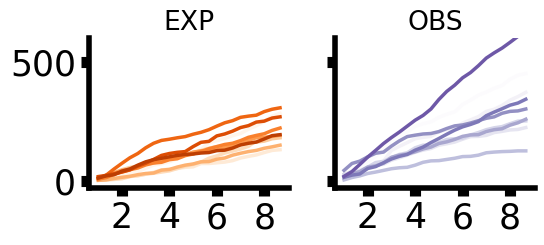

In [1090]:
# Cumulative attacks across training period

sns.set_context(rc={'lines.linewidth': 2.5,
                    'axes.labelsize': 25,
                    'axes.titlesize': 19.200000000000003,
                    'font.size': 25,
                    'xtick.major.width': 8,
                    'ytick.major.width': 8,
                    'xtick.major.size':6,
                    'ytick.major.size':6,
                    'axes.linewidth':4})

exp_gradient = np.linspace(0, 1, 12)
exp_colors = [plt.cm.get_cmap('Oranges')(x) for x in exp_gradient]

obs_gradient = np.linspace(0, 1, 12)
obs_colors = [plt.cm.get_cmap('Purples')(x) for x in obs_gradient]

fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharey=True)

for animal, trial, color in zip(agg_animals, agg_trials, exp_colors):
    cumulative_trials = np.cumsum(trial)[:-3]
    axes[0].plot(cumulative_trials, label=animal, color=color)

for animal, trial, color in zip(obs_animals, obs_trials, obs_colors):
    cumulative_trials = np.cumsum(trial)[:-3]
    axes[1].plot(cumulative_trials, label=animal, color=color)

for ax, title in zip(axes, ['EXP', 'OBS']):
    ax.set_xticks(np.arange(3, 24, 6))
    ax.set_xticklabels(np.arange(2, 9, 2))
    ax.set_ylim(top=600)
    ax.set_title(title)
    sns.despine(ax=ax)

plt.tight_layout()
# plt.savefig('.\\figures\\fig1\\exp_obs_trial_cumulative.svg', dpi=300, bbox_inches='tight')
plt.show()

rows = []
for animal, trial in zip(agg_animals, agg_trials):
    cumulative_trials = np.cumsum(trial)[:-3]
    for idx, val in enumerate(cumulative_trials):
        rows.append({'group': 'EXP', 'animal': animal, 'trial_index': idx, 'cumulative_attacks': val})

for animal, trial in zip(obs_animals, obs_trials):
    cumulative_trials = np.cumsum(trial)[:-3]
    for idx, val in enumerate(cumulative_trials):
        rows.append({'group': 'OBS', 'animal': animal, 'trial_index': idx, 'cumulative_attacks': val})

sourceData_1c = pd.DataFrame(rows)
sourceData_1c.to_csv('./sourceData/1c.csv', index=False)

Occupancy: paired t-test  stat=0.702  df=9  p=0.5003  n_paired=10
Latency: Wilcoxon signed-rank  stat=6.000  df=n/a  p=0.0273  n_paired=10
Persistence: paired t-test  stat=0.976  df=9  p=0.3547  n_paired=10


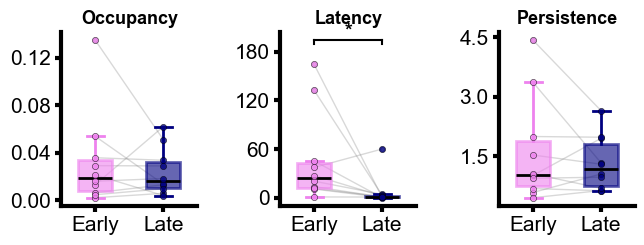

In [ ]:
from scipy.stats import shapiro, ttest_rel, wilcoxon

early_period = [0, 3]
late_period  = [-6, -3]

# ── Extract data ───────────────────────────────────────────────────────────────
early_occ_full = np.nanmean(agg_occupancies[:, early_period[0]:early_period[1]], axis=1)
late_occ_full  = np.nanmean(agg_occupancies[:, late_period[0]:late_period[1]], axis=1)

early_dur_full = np.nanmean(agg_durations[:, early_period[0]:early_period[1]], axis=1)
late_dur_full  = np.nanmean(agg_durations[:, late_period[0]:late_period[1]], axis=1)

def first_nonzero_or_last(arr):
    """
    Given a trio of latency values, return the first non-zero value.
    If no non-zero value exists, return the last value.
    """
    for val in arr:
        if not np.isnan(val) and val > 0:
            return val
    return arr[-1]

def compute_latency_per_subject(latency_matrix, period):
    n_subjects = latency_matrix.shape[0]
    result     = np.full(n_subjects, np.nan)
    for s in np.arange(n_subjects):
        vals  = latency_matrix[s, period[0]:period[1]]
        trio1 = vals[:3]
        v1 = first_nonzero_or_last(trio1)
        result[s] = v1
    return result

early_lat_full = compute_latency_per_subject(agg_latencies, early_period)
late_lat_full  = compute_latency_per_subject(agg_latencies, late_period)

# ── Pair early/late per subject BEFORE dropping any NaNs ─────────────────────
def paired_valid(early_full, late_full):
    mask = ~np.isnan(early_full) & ~np.isnan(late_full)
    return early_full[mask], late_full[mask]

early_occ, late_occ = paired_valid(early_occ_full, late_occ_full)
early_dur, late_dur = paired_valid(early_dur_full, late_dur_full)
early_lat, late_lat = paired_valid(early_lat_full, late_lat_full)

metrics = [
    ('Occupancy',   early_occ, late_occ),
    ('Latency',     early_lat, late_lat),
    ('Persistence', early_dur, late_dur),
]

early_color = 'violet'
late_color  = 'navy'
positions   = [1, 2]

def compute_df_for_paired_test(test_name, n):
    if test_name == 'paired t-test':
        return n - 1
    else:
        return np.nan  # Wilcoxon signed-rank has no conventional df

fig, axes = plt.subplots(1, 3, figsize=(7, 3))
metric_stats = {}

for ax, (title, early_data, late_data) in zip(axes, metrics):
    data_to_plot = [early_data, late_data]
    n_paired = len(early_data)

    # ── Stats: paired test, selected on normality of the DIFFERENCES ────────
    # (same animals contribute both early and late values, so the relevant
    # normality check is on early-late, not on each group's marginal
    # distribution — that's what determines paired t-test vs Wilcoxon).
    diffs = early_data - late_data
    _, p_diff = shapiro(diffs[:500] if len(diffs) > 500 else diffs) if n_paired >= 3 else (None, 0.0)
    normal_diffs = p_diff > 0.05

    if normal_diffs:
        stat, p_val = ttest_rel(early_data, late_data)
        test_label  = 'paired t-test'
    else:
        try:
            stat, p_val = wilcoxon(early_data, late_data, alternative='two-sided')
        except ValueError:
            stat, p_val = np.nan, np.nan
        test_label  = 'Wilcoxon signed-rank'

    df = compute_df_for_paired_test(test_label, n_paired)

    metric_stats[title] = {
        'test': test_label, 'stat': stat, 'df': df, 'p_value': p_val,
        'shapiro_diff_p': p_diff,
    }

    df_str = f'{df:.0f}' if not np.isnan(df) else 'n/a'
    print(f'{title}: {test_label}  stat={stat:.3f}  df={df_str}  p={p_val:.4f}  n_paired={n_paired}')

    # ── Paired lines connecting each subject's early -> late value ──────────
    for i in range(n_paired):
        ax.plot(positions, [early_data[i], late_data[i]],
                color='gray', alpha=0.3, linewidth=1, zorder=1)

    # ── Boxplots ───────────────────────────────────────────────────────────
    box = ax.boxplot(data_to_plot,
                     positions=positions,
                     patch_artist=True,
                     widths=0.5,
                     medianprops=dict(color='black', linewidth=2),
                     whiskerprops=dict(linewidth=2),
                     capprops=dict(linewidth=2),
                     flierprops=dict(marker='o', markersize=3,
                                     markeredgecolor='black', alpha=0.4),
                     zorder=3)

    for patch, color in zip(box['boxes'], [early_color, late_color]):
        patch.set_facecolor(color)
        patch.set_edgecolor(color)
        patch.set_alpha(0.6)
        patch.set_linewidth(2)
    for whisker, color in zip(box['whiskers'],
                               [c for c in [early_color, late_color] for _ in (0, 1)]):
        whisker.set_color(color)
        whisker.set_linewidth(2)
    for cap, color in zip(box['caps'],
                           [c for c in [early_color, late_color] for _ in (0, 1)]):
        cap.set_color(color)
        cap.set_linewidth(2)

    # ── Individual dots (on top of the connecting lines) ─────────────────────
    for j, (data, color) in enumerate(zip(data_to_plot, [early_color, late_color])):
        ax.scatter(np.full(len(data), positions[j]), data,
                   color=color, edgecolor='black', linewidths=0.4,
                   s=20, alpha=0.8, zorder=5)

    # ── Significance bracket ───────────────────────────────────────────────
    ax.autoscale()
    y_max = ax.get_ylim()[1]
    step  = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.12

    def get_sig(p):
        if np.isnan(p): return 'n/a'
        if p < 0.001: return '***'
        if p < 0.01:  return '**'
        if p < 0.05:  return '*'
        return 'ns'

    sig = get_sig(p_val)
    if sig not in ('ns', 'n/a'):
        y_br = y_max + step
        ax.plot([1, 2], [y_br, y_br], color='black', linewidth=1.5)
        ax.plot([1, 1], [y_br - step*0.2, y_br], color='black', linewidth=1.5)
        ax.plot([2, 2], [y_br - step*0.2, y_br], color='black', linewidth=1.5)
        ax.text(1.5, y_br, sig, ha='center', va='bottom',
                fontsize=14, fontweight='bold', fontfamily='Arial')

    # ── Formatting ────────────────────────────────────────────────────────
    ax.set_xticks(positions)
    ax.set_xticklabels(['Early', 'Late'], fontsize=13, fontfamily='Arial')
    ax.set_title(title, fontsize=13, fontweight='bold', fontfamily='Arial')
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=False, nbins=4))
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontfamily('Arial')
        tick.set_fontsize(15)
    for spine in ax.spines.values():
        spine.set_linewidth(3)
    ax.tick_params(axis='both', length=4, width=3)
    sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('.\\figures\\fig1_agg_attack_boxplots.svg', dpi=300, bbox_inches='tight')
plt.show()

# ── Source data export: ED1b ──────────────────────────────────────────────────
os.makedirs('./sourceData', exist_ok=True)

rows = []
for title, early_data, late_data in metrics:
    sr = metric_stats[title]
    n_paired = len(early_data)
    for subj_idx in range(n_paired):
        rows.append({
            'metric': title,
            'animal_idx': subj_idx,
            'early_value': early_data[subj_idx],
            'late_value': late_data[subj_idx],
            'test': sr['test'],
            'stat': sr['stat'],
            'df': sr['df'],
            'p_value': sr['p_value'],
            'shapiro_diff_p': sr['shapiro_diff_p'],
            'n_paired': n_paired,
        })

sourceData_ED1b = pd.DataFrame(rows)
sourceData_ED1b.to_csv('./sourceData/ED1b.csv', index=False)

Animals with complete Day1/Day8/HF data: 10 / 10
Omnibus (Friedman): stat=1.4000, p=0.4966
Day 1 vs Day 8: Wilcoxon signed-rank  stat=27.0000  p_raw=1.0000  p_fdr=1.0000
Day 1 vs HF: Wilcoxon signed-rank  stat=16.0000  p_raw=0.2754  p_fdr=0.4131
Day 8 vs HF: Wilcoxon signed-rank  stat=15.0000  p_raw=0.2324  p_fdr=0.4131


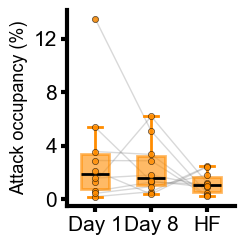

In [1133]:
from scipy.stats import shapiro
from statsmodels.stats.anova import AnovaRM
import scikit_posthocs as sp  # for Friedman post-hoc; pip install scikit-posthocs if unavailable
from scipy.stats import friedmanchisquare, wilcoxon
from statsmodels.stats.multitest import multipletests

attack_occupancies = pd.read_pickle('hand-annotated_fight_occupancies.pickle')
conflict_occupancies = pd.read_pickle('hand-annotated_conflict_occupancies.pickle')

attack_occ_df = attack_occupancies[
    (attack_occupancies['group'] == 'EXP') &
    (attack_occupancies['behavior'].isin(['resident_unilateral', 'resident_resistance']))
]
hf_by_animal = attack_occ_df.groupby('animal')['occupancy'].sum()

# ── Build a single aligned table keyed by animal ID — this is the step that
# guarantees d1/d8/HF refer to the SAME animal in every row. Requires
# agg_animals: list of animal IDs matching agg_occupancies' row order.
d1_by_pos = np.nanmean(agg_occupancies[:, :3], axis=1)
d8_by_pos = np.nanmean(agg_occupancies[:, -6:-3], axis=1)

aligned = pd.DataFrame({
    'animal': agg_animals,
    'Day 1':  d1_by_pos,
    'Day 8':  d8_by_pos,
}).set_index('animal')
aligned['HF'] = hf_by_animal  # aligns by animal ID via the index; NaN if missing

# only keep animals with all three conditions present
aligned = aligned.dropna(subset=['Day 1', 'Day 8', 'HF'])
n_paired = len(aligned)
print(f'Animals with complete Day1/Day8/HF data: {n_paired} / {len(agg_animals)}')

data_to_plot = [aligned['Day 1'].values, aligned['Day 8'].values, aligned['HF'].values]
labels    = ['Day 1', 'Day 8', 'HF']
positions = [1, 2, 3]
color     = 'darkorange'
data_pct  = [d * 100 for d in data_to_plot]

# ── Repeated-measures omnibus: RM-ANOVA (normal) or Friedman (non-normal) ────
diffs_for_normality = np.column_stack(data_pct)
normality_ps = [shapiro(diffs_for_normality[:, i])[1] for i in range(3)]
normal = all(p > 0.05 for p in normality_ps)

long_df = pd.DataFrame({
    'animal':    np.tile(aligned.index.values, 3),
    'condition': np.repeat(labels, n_paired),
    'value':     np.concatenate(data_pct),
})

if normal:
    rm = AnovaRM(long_df, depvar='value', subject='animal', within=['condition']).fit()
    omni_stat = rm.anova_table['F Value'].values[0]
    omni_p    = rm.anova_table['Pr > F'].values[0]
    omni_test = 'RM-ANOVA'
else:
    omni_stat, omni_p = friedmanchisquare(*data_pct)
    omni_test = 'Friedman'

print(f'Omnibus ({omni_test}): stat={omni_stat:.4f}, p={omni_p:.4f}')

# ── Post-hoc: paired t-test / Wilcoxon per pair, FDR-corrected ───────────────
pairs = [('Day 1', 'Day 8'), ('Day 1', 'HF'), ('Day 8', 'HF')]
posthoc_results = {}
raw_ps = []

for a_label, b_label in pairs:
    a = aligned[a_label].values * 100
    b = aligned[b_label].values * 100
    if normal:
        from scipy.stats import ttest_rel
        stat, p = ttest_rel(a, b)
        test_used = 'paired t-test'
    else:
        stat, p = wilcoxon(a, b)
        test_used = 'Wilcoxon signed-rank'
    posthoc_results[(a_label, b_label)] = {'stat': stat, 'p_raw': p, 'test': test_used}
    raw_ps.append(p)

_, p_fdr, _, _ = multipletests(raw_ps, method='fdr_bh')
for (pair, p_c) in zip(pairs, p_fdr):
    posthoc_results[pair]['p_fdr'] = p_c
    print(f'{pair[0]} vs {pair[1]}: {posthoc_results[pair]["test"]}  '
          f'stat={posthoc_results[pair]["stat"]:.4f}  p_raw={posthoc_results[pair]["p_raw"]:.4f}  '
          f'p_fdr={p_c:.4f}')

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(3, 3))

box = ax.boxplot(data_pct,
                 positions=positions,
                 patch_artist=True,
                 widths=0.5,
                 medianprops=dict(color='black', linewidth=2),
                 whiskerprops=dict(linewidth=2),
                 capprops=dict(linewidth=2),
                 flierprops=dict(marker='o', markersize=3,
                                 markeredgecolor='black', alpha=0.4),
                 zorder=3)

for patch in box['boxes']:
    patch.set_facecolor(color)
    patch.set_edgecolor(color)
    patch.set_alpha(0.6)
    patch.set_linewidth(2)
for whisker in box['whiskers']:
    whisker.set_color(color)
    whisker.set_linewidth(2)
for cap in box['caps']:
    cap.set_color(color)
    cap.set_linewidth(2)

# ── Connecting lines per animal across all three conditions ──────────────────
for i in range(n_paired):
    vals = [aligned['Day 1'].iloc[i]*100, aligned['Day 8'].iloc[i]*100, aligned['HF'].iloc[i]*100]
    ax.plot(positions, vals, color='gray', alpha=0.3, linewidth=1, zorder=1)

# ── Individual dots ────────────────────────────────────────────────────────────
for j, data in enumerate(data_pct):
    ax.scatter(np.full(len(data), positions[j]), data,
               color=color, edgecolor='black', linewidths=0.4,
               s=20, alpha=0.8, zorder=5)

# ── Significance brackets (manual, using posthoc_results) ────────────────────
ax.autoscale()
y_max = ax.get_ylim()[1]
step  = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.12

def get_sig(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return None

bracket_specs = [(1, 3, ('Day 1', 'HF')), (1, 2, ('Day 1', 'Day 8')), (2, 3, ('Day 8', 'HF'))]
level = 0
for x1, x2, pair in bracket_specs:
    sig = get_sig(posthoc_results[pair]['p_fdr'])
    if sig:
        y_br = y_max + step * (level + 1)
        ax.plot([x1, x1, x2, x2], [y_br - step*0.2, y_br, y_br, y_br - step*0.2], 'k-', linewidth=1.5)
        ax.text((x1+x2)/2, y_br, sig, ha='center', va='bottom', fontsize=14, fontweight='bold', fontfamily='Arial')
        level += 1

# ── Formatting ─────────────────────────────────────────────────────────────────
ax.set_xticks(positions)
ax.set_xticklabels(labels, fontsize=13, fontfamily='Arial')
ax.set_ylabel('Attack occupancy (%)', fontsize=13, fontfamily='Arial')
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=False, nbins=4))
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontfamily('Arial')
    tick.set_fontsize(15)
for spine in ax.spines.values():
    spine.set_linewidth(3)
ax.tick_params(axis='both', length=4, width=3)
sns.despine(ax=ax)

plt.tight_layout()
plt.savefig('.\\figures\\fig1_agg_occupancy_boxplot.svg', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
comparison_map = {
    'Day1_vs_HF':   stats_results.get('agg_vs_non', {}),
    'Day1_vs_Day8': stats_results.get('agg_vs_obs', {}),
    'Day8_vs_HF':   stats_results.get('obs_vs_non', {}),
}

rows = []
for period_label, vals in zip(labels, data_pct):
    for v in vals:
        row = {'period': period_label, 'attack_occupancy_pct': v}
        for comp_label, comp in comparison_map.items():
            row[f'{comp_label}_stat']   = comp.get('statistic', np.nan)
            row[f'{comp_label}_p_fdr']  = comp.get('p_corrected', np.nan)
        row['omnibus_test'] = stats_results.get('omnibus_test', np.nan)
        row['omnibus_stat'] = stats_results.get('omnibus_statistic', np.nan)
        row['omnibus_p']    = stats_results.get('omnibus_p', np.nan)
        rows.append(row)

sourceData_ED1d = pd.DataFrame(rows)
sourceData_ED1d.to_csv('./sourceData/ED1d.csv', index=False)

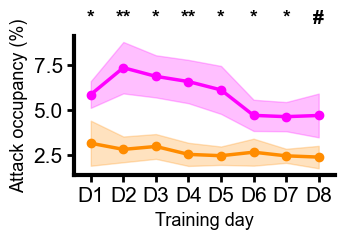


Day    Test                       Stat       df p_raw      p_corr     Sig
-------------------------------------------------------------------------------------
  D1    Brunner-Munzel            2.808      n/a 0.0191     0.0305     *
  D2    Brunner-Munzel            4.289      n/a 0.0011     0.0059     **
  D3    t-test                   -2.937     17.0 0.0092     0.0246     *
  D4    Brunner-Munzel            4.216      n/a 0.0015     0.0059     **
  D5    t-test                   -2.666     17.0 0.0163     0.0305     *
  D6    Brunner-Munzel            2.308      n/a 0.0344     0.0393     *
  D7    t-test                   -2.499     17.0 0.0230     0.0307     *
  D8    t-test                   -1.745     17.0 0.0991     0.0991     #


In [1095]:
# Comparing OBS and EXP attacks
# ── Average occupancy every 3 sessions (1 point per day) ──────────────────────
# Training period only: first 24 sessions = 8 days x 3 sessions

from scipy.stats import shapiro, levene, ttest_ind, brunnermunzel, mannwhitneyu

n_training = 24
n_days     = n_training // 3

def daily_occupancy(occ_matrix, n_training=24):
    tp   = occ_matrix[:, :n_training]
    days = tp.reshape(tp.shape[0], -1, 3)
    return np.nanmean(days, axis=2)

agg_daily = daily_occupancy(agg_occupancies) * 100
obs_daily = daily_occupancy(obs_occupancies) * 100

def compute_df_for_test(test_name, a, b):
    if test_name == 't-test':
        return len(a) + len(b) - 2
    elif test_name == 'Welch t-test':
        v1, v2 = np.var(a, ddof=1), np.var(b, ddof=1)
        n1, n2 = len(a), len(b)
        return (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
    else:
        return np.nan

# ── Stats: per-day comparison EXP vs OBS ──────────────────────────────────────
pvals       = np.full(n_days, np.nan)
stats_vals  = np.full(n_days, np.nan)
df_vals     = np.full(n_days, np.nan)
test_labels = []

for d in np.arange(n_days):
    a = agg_daily[:, d][~np.isnan(agg_daily[:, d])]
    o = obs_daily[:, d][~np.isnan(obs_daily[:, d])]

    if len(a) < 3 or len(o) < 3:
        test_labels.append('n/a')
        continue

    _, p_a = shapiro(a)
    _, p_o = shapiro(o)
    normal = p_a > 0.05 and p_o > 0.05

    levene_stat, levene_p = levene(a, o)
    equal_var = levene_p > 0.05

    if normal:
        stat, p = ttest_ind(a, o, equal_var=equal_var)
        test_label = 't-test' if equal_var else 'Welch t-test'
    else:
        stat, p = brunnermunzel(a, o, alternative='two-sided')
        test_label = 'Brunner-Munzel'
        if not np.isfinite(stat) or not np.isfinite(p):
            stat, p = mannwhitneyu(a, o, alternative='two-sided')
            test_label = 'Mann-Whitney U (BM degenerate — fallback)'

    df = compute_df_for_test(test_label, a, o)

    pvals[d]      = p
    stats_vals[d] = stat
    df_vals[d]    = df
    test_labels.append(test_label)

# FDR correction
valid     = ~np.isnan(pvals)
corrected = np.full(n_days, np.nan)
if valid.sum() > 0:
    _, corr, _, _ = multipletests(pvals[valid], method='fdr_bh')
    corrected[valid] = corr

def get_sig(p):
    if np.isnan(p):   return ''
    if p < 0.001:     return '***'
    if p < 0.01:      return '**'
    if p < 0.05:      return '*'
    if p < 0.1:       return '#'
    return ''

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4, 3))

days     = np.arange(1, n_days + 1)
agg_mean = np.nanmean(agg_daily, axis=0)
agg_sem  = np.array([sem(agg_daily[:, d][~np.isnan(agg_daily[:, d])])
                     for d in np.arange(n_days)])
obs_mean = np.nanmean(obs_daily, axis=0)
obs_sem  = np.array([sem(obs_daily[:, d][~np.isnan(obs_daily[:, d])])
                     for d in np.arange(n_days)])

ax.plot(days, agg_mean, color='darkorange', linewidth=2.5,
        marker='o', markersize=6, label='EXP')
ax.fill_between(days, agg_mean - agg_sem, agg_mean + agg_sem,
                color='darkorange', alpha=0.25)

ax.plot(days, obs_mean, color='magenta', linewidth=2.5,
        marker='o', markersize=6, label='OBS')
ax.fill_between(days, obs_mean - obs_sem, obs_mean + obs_sem,
                color='magenta', alpha=0.25)

ax.autoscale()
y_top = ax.get_ylim()[1]
y_sig = y_top * 1.05

for d_idx, d in enumerate(days):
    sig = get_sig(corrected[d_idx])
    if sig:
        ax.text(d, y_sig, sig, ha='center', va='bottom',
                fontsize=14, fontweight='bold', fontfamily='Arial',
                color='black')

ax.set_xlim(0.5, n_days + 0.5)
ax.set_xticks(days)
ax.set_xticklabels([f'D{d}' for d in days], fontsize=13, fontfamily='Arial')
ax.set_ylabel('Attack occupancy (%)', fontsize=13, fontfamily='Arial')
ax.set_xlabel('Training day', fontsize=13, fontfamily='Arial')
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontfamily('Arial')
    tick.set_fontsize(15)
for spine in ax.spines.values():
    spine.set_linewidth(3)
ax.tick_params(axis='both', length=5, width=2)
sns.despine(ax=ax)
plt.tight_layout()
# plt.savefig('.\\figures\\fig1\\agg_obs_daily_occupancy.svg', dpi=300, bbox_inches='tight')
plt.show()

# ── Print summary — now includes df ────────────────────────────────────────────
print(f'\n{"="*85}')
print(f'{"Day":<6} {"Test":<20} {"Stat":>10} {"df":>8} {"p_raw":<10} {"p_corr":<10} {"Sig"}')
print('-'*85)
for d_idx in np.arange(n_days):
    sig      = get_sig(corrected[d_idx])
    stat_str = f'{stats_vals[d_idx]:>10.3f}' if not np.isnan(stats_vals[d_idx]) else '       n/a'
    df_str   = f'{df_vals[d_idx]:>8.1f}'     if not np.isnan(df_vals[d_idx])    else '     n/a'
    p_str    = f'{pvals[d_idx]:<10.4f}'       if not np.isnan(pvals[d_idx])      else 'n/a       '
    c_str    = f'{corrected[d_idx]:<10.4f}'   if not np.isnan(corrected[d_idx])  else 'n/a       '
    print(f'  D{d_idx+1:<4} {test_labels[d_idx]:<20} {stat_str} {df_str} {p_str} {c_str} {sig}')
print(f'{"="*85}')

# ── Source data export: ED1c ──────────────────────────────────────────────────
os.makedirs('./sourceData', exist_ok=True)

rows = []
for group_label, daily_arr in [('EXP', agg_daily), ('OBS', obs_daily)]:
    n_subjects = daily_arr.shape[0]
    for subj_idx in np.arange(n_subjects):
        for d_idx in np.arange(n_days):
            rows.append({
                'group': group_label,
                'animal_idx': subj_idx,
                'day': d_idx + 1,
                'attack_occupancy_pct': daily_arr[subj_idx, d_idx],
                'test': test_labels[d_idx],
                'stat': stats_vals[d_idx],
                'df': df_vals[d_idx],
                'p_raw': pvals[d_idx],
                'p_fdr': corrected[d_idx],
            })

sourceData_ED1c = pd.DataFrame(rows)
sourceData_ED1c.to_csv('./sourceData/ED1c.csv', index=False)

### Correlating observer behavior to hard fight outcomes

In [1096]:
with open('sniffing_labels_dict.pkl', 'rb') as f:
    sniffing_labels_dict = pickle.load(f)

print(f"Loaded {len(sniffing_labels_dict)} entries: {list(sniffing_labels_dict.keys())[:5]} ...")

Loaded 336 entries: ['1185_d1_obs_t1', '1185_d1_obs_t2', '1185_d1_obs_t3', '1185_d2_obs_t1', '1185_d2_obs_t2'] ...


In [1099]:
# ── Animal lists ───────────────────────────────────────────────────────────────
obs_animals = ['30R2', '29L', '86L', '87L2', '927R', '927L', '933R', '1162B', '1185']
xpo_animals = ['4321L', '4321R2', '4321L2', '7452R', '7452L2']
all_observer_animals = obs_animals + xpo_animals
n_obs = len(obs_animals)
n_xpo = len(xpo_animals)
n_all = len(all_observer_animals)

n_behaviors    = 7
behavior_names = ['grooming', 'investigate', 'rearing', 'scratching',
                  'sniffing', 'still', 'turning']

cluster_groups = {
    'aggressive':    [0, 1, 2, 3],
    'investigative': [4, 6, 7, 8],
    'passive':       [5, 9, 10, 11, 12],
}

# ── 1. Behavior occupancy — both groups ───────────────────────────────────────
behavior_occupancy_all = np.zeros((n_all, n_behaviors))

for a_idx, animal in enumerate(all_observer_animals):
    session_occupancies = []
    for key, labels in sniffing_labels_dict.items():
        if key.startswith(animal + '_'):
            counts = np.array([(labels == b).sum() for b in np.arange(n_behaviors)])
            occ    = counts / len(labels)
            session_occupancies.append(occ)
    if session_occupancies:
        behavior_occupancy_all[a_idx] = np.nanmedian(session_occupancies, axis=0)
    else:
        print(f"  Warning: no sessions found for {animal}")

# Split back out for convenience
behavior_occupancy_obs = behavior_occupancy_all[:n_obs]   # (9, 7)
behavior_occupancy_xpo = behavior_occupancy_all[n_obs:]   # (5, 7)

print(f"OBS behavior occupancy: {behavior_occupancy_obs.shape}")
print(f"XPO behavior occupancy: {behavior_occupancy_xpo.shape}")
print(f"OBS per-animal sums: {behavior_occupancy_obs.sum(axis=1).round(3)}")
print(f"XPO per-animal sums: {behavior_occupancy_xpo.sum(axis=1).round(3)}")

# ── 2. Cluster occupancy per animal ───────────────────────────────────────────
# OBS: (13, 27) → (13, 9, 3) → mean → (13, 9)
cluster_occ_obs = cd1_obs_occupancies.copy()
# XPO: (13, 15) → (13, 5, 3) → mean → (13, 5)

# ── 3. Group clusters ─────────────────────────────────────────────────────────
group_occ_obs = {
    name: cluster_occ_obs[idxs, :].mean(axis=0)
    for name, idxs in cluster_groups.items()
}  # each: (9,)


OBS behavior occupancy: (9, 7)
XPO behavior occupancy: (5, 7)
OBS per-animal sums: [0.986 0.96  0.923 0.919 1.027 0.891 0.962 0.985 0.964]
XPO per-animal sums: [0.865 0.978 0.927 0.904 0.94 ]


In [1100]:
behavior_groups = {
    'grooming':   [0, 3],
    'locomotor':  [6, 1, 2],
    'sniffing':   [4],
    'still':      [5],
}
behavior_names_grouped = list(behavior_groups.keys())
n_groups = len(behavior_groups)

# ── Grouped occupancy for both OBS and XPO ────────────────────────────────────
def compute_grouped_occupancy(animals, n_behaviors=7):
    out = np.zeros((len(animals), n_groups))
    for a_idx, animal in enumerate(animals):
        session_occupancies = []
        for key, labels in sniffing_labels_dict.items():
            if key.startswith(animal + '_'):
                counts = np.array([(labels == b).sum() for b in np.arange(n_behaviors)])
                occ    = counts / len(labels)
                session_occupancies.append(occ)
        if session_occupancies:
            mean_occ = np.mean(session_occupancies, axis=0)
            for g_idx, (gname, bidxs) in enumerate(behavior_groups.items()):
                out[a_idx, g_idx] = mean_occ[bidxs].sum()
        else:
            print(f"  Warning: no sessions found for {animal}")
    return out

behavior_occupancy_grouped_obs = compute_grouped_occupancy(obs_animals)  # (9, 4)
behavior_occupancy_grouped_xpo = compute_grouped_occupancy(xpo_animals)  # (5, 4)

print(f"OBS grouped occupancy: {behavior_occupancy_grouped_obs.shape}")
print(f"XPO grouped occupancy: {behavior_occupancy_grouped_xpo.shape}")
print(f"OBS per-animal sums:   {behavior_occupancy_grouped_obs.sum(axis=1).round(3)}")
print(f"XPO per-animal sums:   {behavior_occupancy_grouped_xpo.sum(axis=1).round(3)}")

OBS grouped occupancy: (9, 4)
XPO grouped occupancy: (5, 4)
OBS per-animal sums:   [1. 1. 1. 1. 1. 1. 1. 1. 1.]
XPO per-animal sums:   [1. 1. 1. 1. 1.]


grooming       t-test                        stat=0.1655  df=12.0  p=0.8713  ns  OBS=0.214±0.078  XPO=0.206±0.067
locomotor      t-test                        stat=-2.4723  df=12.0  p=0.0294  *  OBS=0.161±0.079  XPO=0.260±0.034
sniffing       t-test                        stat=2.2560  df=12.0  p=0.0435  *  OBS=0.537±0.132  XPO=0.386±0.057
still          Brunner-Munzel                stat=1.8842  df=n/a  p=0.0852  #  OBS=0.088±0.083  XPO=0.147±0.062


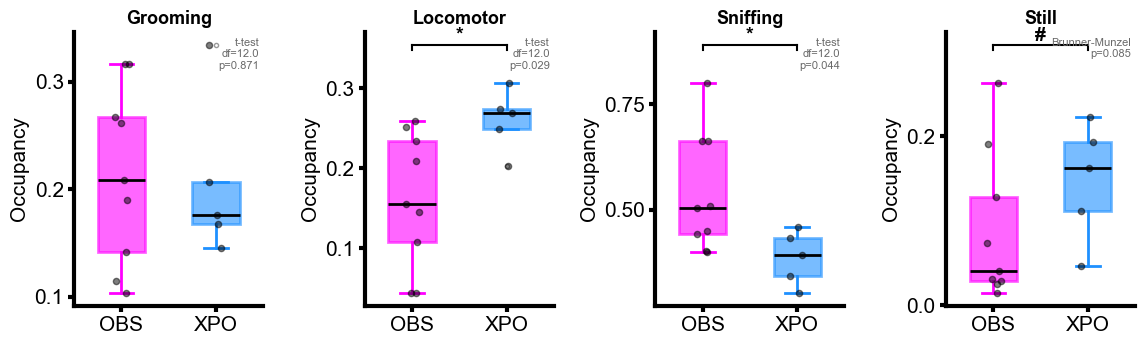

In [1137]:
from scipy.stats import ttest_ind, levene, shapiro, brunnermunzel, mannwhitneyu

def compute_df_for_test(test_name, a, b):
    if test_name == 't-test':
        return len(a) + len(b) - 2
    elif test_name == 'Welch t-test':
        v1, v2 = np.var(a, ddof=1), np.var(b, ddof=1)
        n1, n2 = len(a), len(b)
        return (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
    else:
        return np.nan

fig, axes = plt.subplots(1, n_groups, figsize=(n_groups * 3, 4))
behavior_stats = {}

for g_idx, bname in enumerate(behavior_names_grouped):
    ax = axes[g_idx]

    obs_data = behavior_occupancy_grouped_obs[:, g_idx]
    xpo_data = behavior_occupancy_grouped_xpo[:, g_idx]

    # ── Stats: normality -> variance -> t-test/Welch/Brunner-Munzel ─────────
    _, p_obs = shapiro(obs_data)
    _, p_xpo = shapiro(xpo_data)
    normal = p_obs > 0.05 and p_xpo > 0.05

    levene_stat, levene_p = levene(obs_data, xpo_data)
    equal_var = levene_p > 0.05

    if normal:
        statistic, p_val = ttest_ind(obs_data, xpo_data, equal_var=equal_var)
        test_label = 't-test' if equal_var else 'Welch t-test'
    else:
        statistic, p_val = brunnermunzel(obs_data, xpo_data, alternative='two-sided')
        test_label = 'Brunner-Munzel'
        if not np.isfinite(statistic) or not np.isfinite(p_val):
            statistic, p_val = mannwhitneyu(obs_data, xpo_data, alternative='two-sided')
            test_label = 'Mann-Whitney U (BM degenerate — fallback)'

    df = compute_df_for_test(test_label, obs_data, xpo_data)

    behavior_stats[bname] = {
        'test': test_label, 'stat': statistic, 'df': df, 'p_value': p_val,
    }

    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 \
          else '*' if p_val < 0.05 else '#' if p_val < 0.1 else 'ns'

    data_to_plot = [obs_data, xpo_data]
    positions    = [1, 2]
    colors       = ['magenta', 'dodgerblue']
    labels_plot  = ['OBS', 'XPO']

    # ── Boxplots ───────────────────────────────────────────────────────────
    box = ax.boxplot(data_to_plot,
                     positions=positions,
                     patch_artist=True,
                     widths=0.5,
                     medianprops=dict(color='black', linewidth=2),
                     whiskerprops=dict(linewidth=2),
                     capprops=dict(linewidth=2),
                     flierprops=dict(marker='o', markersize=3,
                                     markeredgecolor='black', alpha=0.4))

    for patch, color in zip(box['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_edgecolor(color)
        patch.set_alpha(0.6)
        patch.set_linewidth(2)
    for whisker, color in zip(box['whiskers'],
                               [c for c in colors for _ in (0, 1)]):
        whisker.set_color(color)
        whisker.set_linewidth(2)
    for cap, color in zip(box['caps'],
                           [c for c in colors for _ in (0, 1)]):
        cap.set_color(color)
        cap.set_linewidth(2)

    # ── Individual dots ────────────────────────────────────────────────────
    for j, (data, color) in enumerate(zip(data_to_plot, colors)):
        jitter = np.random.default_rng(42 + j).uniform(-0.08, 0.08, size=len(data))
        ax.scatter(np.full(len(data), positions[j]) + jitter,
                   data, color='black', s=20, alpha=0.5, zorder=5)

    # ── Significance bracket ───────────────────────────────────────────────
    ax.autoscale()
    y_max = ax.get_ylim()[1]
    step  = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.12

    if sig != 'ns':
        y_br = y_max + step
        ax.plot([1, 2], [y_br, y_br], color='black', linewidth=1.5)
        ax.plot([1, 1], [y_br - step * 0.2, y_br], color='black', linewidth=1.5)
        ax.plot([2, 2], [y_br - step * 0.2, y_br], color='black', linewidth=1.5)
        ax.text(1.5, y_br, sig, ha='center', va='bottom',
                fontsize=14, fontweight='bold', fontfamily='Arial')

    # ── Formatting ────────────────────────────────────────────────────────
    ax.set_xticks(positions)
    ax.set_xticklabels(labels_plot, fontsize=13, fontfamily='Arial')
    ax.set_title(bname.capitalize(), fontsize=13,
                 fontweight='bold', fontfamily='Arial')
    ax.set_ylabel('Occupancy', fontsize=15, fontfamily='Arial')
    for tick in ax.get_xticklabels() + ax.get_yticklabels():
        tick.set_fontfamily('Arial')
        tick.set_fontsize(15)
    for spine in ax.spines.values():
        spine.set_linewidth(3)
    ax.tick_params(axis='both', length=4, width=3)

    df_str = f'df={df:.1f}\n' if not np.isnan(df) else ''
    ax.text(0.98, 0.98, f'{test_label}\n{df_str}p={p_val:.3f}',
            transform=ax.transAxes, fontsize=8, fontfamily='Arial',
            ha='right', va='top', color='dimgray')

    sns.despine(ax=ax)

    df_print = f'{df:.1f}' if not np.isnan(df) else 'n/a'
    print(f"{bname:<14} {test_label:<28}  stat={statistic:.4f}  df={df_print}  p={p_val:.4f}  {sig}  "
          f"OBS={np.mean(obs_data):.3f}±{np.std(obs_data):.3f}  "
          f"XPO={np.mean(xpo_data):.3f}±{np.std(xpo_data):.3f}")

plt.tight_layout()
# plt.savefig('./figures/fig1/obs_vs_xpo_behavior_occupancy.svg', dpi=300, bbox_inches='tight')
plt.show()

# ── Source data export: ED5g ─────────────────────────────────────────────────
os.makedirs('./sourceData', exist_ok=True)

rows = []
for g_idx, bname in enumerate(behavior_names_grouped):
    sr = behavior_stats[bname]
    for group_label, vals in [('OBS', behavior_occupancy_grouped_obs[:, g_idx]),
                               ('XPO', behavior_occupancy_grouped_xpo[:, g_idx])]:
        for v in vals:
            rows.append({
                'behavior': bname,
                'group': group_label,
                'occupancy': v,
                'test': sr['test'],
                'stat': sr['stat'],
                'df': sr['df'],
                'p_value': sr['p_value'],
            })

sourceData_ED5g = pd.DataFrame(rows)
sourceData_ED5g.to_csv('./sourceData/ED5g.csv', index=False)

Behavioral entropy (bits)
  Test: t-test, statistic=-2.0565, df=12.0, p=0.0622 #
  OBS: 1.565 ± 0.300
  XPO: 1.866 ± 0.061


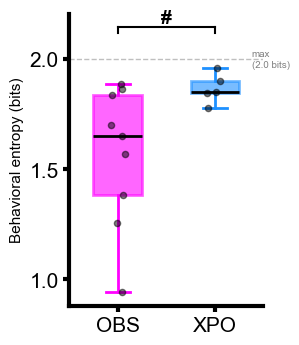

In [1103]:
from scipy.stats import entropy, ttest_ind, levene, shapiro, brunnermunzel, mannwhitneyu

def behavioral_entropy(occupancy_matrix):
    entropies = np.zeros(occupancy_matrix.shape[0])
    for i, occ in enumerate(occupancy_matrix):
        occ_clean    = np.clip(occ, 1e-10, None)
        occ_clean    = occ_clean / occ_clean.sum()
        entropies[i] = entropy(occ_clean, base=2)
    return entropies

obs_entropy = behavioral_entropy(behavior_occupancy_grouped_obs)
xpo_entropy = behavioral_entropy(behavior_occupancy_grouped_xpo)

def compute_df_for_test(test_name, a, b):
    if test_name == 't-test':
        return len(a) + len(b) - 2
    elif test_name == 'Welch t-test':
        v1, v2 = np.var(a, ddof=1), np.var(b, ddof=1)
        n1, n2 = len(a), len(b)
        return (v1/n1 + v2/n2)**2 / ((v1/n1)**2/(n1-1) + (v2/n2)**2/(n2-1))
    else:
        return np.nan

def run_test(a, b):
    _, p_a = shapiro(a)
    _, p_b = shapiro(b)
    normal = p_a > 0.05 and p_b > 0.05

    levene_stat, levene_p = levene(a, b)
    equal_var = levene_p > 0.05

    if normal:
        statistic, p = ttest_ind(a, b, equal_var=equal_var)
        test_label = 't-test' if equal_var else 'Welch t-test'
    else:
        statistic, p = brunnermunzel(a, b, alternative='two-sided')
        test_label = 'Brunner-Munzel'
        if not np.isfinite(statistic) or not np.isfinite(p):
            statistic, p = mannwhitneyu(a, b, alternative='two-sided')
            test_label = 'Mann-Whitney U (BM degenerate — fallback)'

    df = compute_df_for_test(test_label, a, b)
    return p, test_label, statistic, df

def get_sig(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.1:   return '#'
    return 'ns'

ylabel   = 'Behavioral entropy (bits)'
ref_label = f'max\n({np.log2(n_groups):.1f} bits)'
ref_val   = np.log2(n_groups)

colors      = ['magenta', 'dodgerblue']
labels_plot = ['OBS', 'XPO']
positions   = [1, 2]

fig, ax = plt.subplots(figsize=(3.5, 4))

p_val, test_label, statistic, df = run_test(obs_entropy, xpo_entropy)
sig = get_sig(p_val)

data_to_plot = [obs_entropy, xpo_entropy]

box = ax.boxplot(data_to_plot,
                 positions=positions,
                 patch_artist=True,
                 widths=0.5,
                 medianprops=dict(color='black', linewidth=2),
                 whiskerprops=dict(linewidth=2),
                 capprops=dict(linewidth=2),
                 flierprops=dict(marker='o', markersize=3,
                                 markeredgecolor='black', alpha=0.4))

for patch, color in zip(box['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_edgecolor(color)
    patch.set_alpha(0.6)
    patch.set_linewidth(2)
for whisker, color in zip(box['whiskers'], [c for c in colors for _ in (0, 1)]):
    whisker.set_color(color)
    whisker.set_linewidth(2)
for cap, color in zip(box['caps'], [c for c in colors for _ in (0, 1)]):
    cap.set_color(color)
    cap.set_linewidth(2)

for j, (data, color) in enumerate(zip(data_to_plot, colors)):
    jitter = np.random.default_rng(42 + j).uniform(-0.08, 0.08, size=len(data))
    ax.scatter(np.full(len(data), positions[j]) + jitter,
               data, color='black', s=20, alpha=0.5, zorder=5)

ax.autoscale()
y_max = ax.get_ylim()[1]
step  = (ax.get_ylim()[1] - ax.get_ylim()[0]) * 0.12

if sig != 'ns':
    y_br = y_max + step
    ax.plot([1, 2], [y_br, y_br], color='black', linewidth=1.5)
    ax.plot([1, 1], [y_br - step * 0.2, y_br], color='black', linewidth=1.5)
    ax.plot([2, 2], [y_br - step * 0.2, y_br], color='black', linewidth=1.5)
    ax.text(1.5, y_br, sig, ha='center', va='bottom',
            fontsize=14, fontweight='bold', fontfamily='Arial')

ax.axhline(ref_val, color='gray', linewidth=1, linestyle='--', alpha=0.5)
ax.text(2.38, ref_val, ref_label, fontsize=7, fontfamily='Arial', color='gray', va='center')

ax.set_xticks(positions)
ax.set_xticklabels(labels_plot, fontsize=13, fontfamily='Arial')
ax.set_ylabel(ylabel, fontsize=11, fontfamily='Arial')
for tick in ax.get_xticklabels() + ax.get_yticklabels():
    tick.set_fontfamily('Arial')
    tick.set_fontsize(15)
for spine in ax.spines.values():
    spine.set_linewidth(3)
ax.tick_params(axis='both', length=4, width=3)
sns.despine(ax=ax)

df_print = f'{df:.1f}' if not np.isnan(df) else 'n/a'
print(f"{ylabel}")
print(f"  Test: {test_label}, statistic={statistic:.4f}, df={df_print}, p={p_val:.4f} {sig}")
print(f"  OBS: {np.mean(obs_entropy):.3f} ± {np.std(obs_entropy):.3f}")
print(f"  XPO: {np.mean(xpo_entropy):.3f} ± {np.std(xpo_entropy):.3f}")

plt.tight_layout()
# plt.savefig('./figures/fig1/obs_vs_xpo_entropy.svg', dpi=300, bbox_inches='tight')
plt.show()

# ── Source data export: ED5h ─────────────────────────────────────────────────
os.makedirs('./sourceData', exist_ok=True)

rows = []
for group_label, vals in [('OBS', obs_entropy), ('XPO', xpo_entropy)]:
    for v in vals:
        rows.append({
            'metric': ylabel,
            'group': group_label,
            'value': v,
            'test': test_label,
            'stat': statistic,
            'df': df,
            'p_value': p_val,
            'reference_max_entropy_bits': ref_val,
        })

sourceData_ED5h = pd.DataFrame(rows)
sourceData_ED5h.to_csv('./sourceData/ED5h.csv', index=False)